## Вводные по кейсу

# Описание данных

## Таблица `Users`

| Поле              | Описание                                       |
|-------------------|------------------------------------------------|
| `user_id`         | Уникальный идентификатор пользователя.         |
| `registration_date` | Дата регистрации пользователя.                |
| `age`             | Возраст пользователя.                          |
| `gender`          | Пол.                                |
| `region`          | Регион.                                        |
| `acq_channel`     | Канал привлечения.                             |
| `buyer_segment`   | Сегмент покупателя.                            |
| `cohort_week`     | Неделя привлечения.|
| `cohort_month`    | Месяц привлечения. |

---

## Таблица `Events`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `event_id`    | Уникальный идентификатор события.                                        |
| `user_id`     | Идентификатор пользователя.                                              |
| `event_date`  | Дата события.                                                            |
| `event_type`  | Тип события.   |
| `os`          | Операционная система.               |
| `device`      | Тип устройства.                                |
| `product_name`| Наименование товара, к которому относится событие (если применимо).      |
| `event_week`  | Неделя события.                                          |
| `event_month` | Месяц события .                                           |

---

## Таблица `Orders`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `order_id`    | Уникальный идентификатор заказа.                                         |
| `user_id`     | Идентификатор пользователя, который сделал заказ |
| `order_date`  | Дата и время оформления заказа.                                          |
| `product_name`| Наименование товара.                                                     |
| `quantity`    | Количество единиц товара в заказе.                                       |
| `unit_price`  | Цена за одну единицу товара.                                             |
| `total_price` | Итоговая сумма заказа.                                                   |
| `category_name` | Наименование категории товара.                                         |
| `order_week`  | Неделя заказа.                                           |
| `order_month` | Месяц заказа.                                            |


## Таблица `Campaign_costs`

| Поле         | Описание                                                                 |
|--------------|--------------------------------------------------------------------------|
| `acq_channel`| Канал привлечения.  |
| `spend_month`| Месяц, в который был потрачен бюджет (отражает период, в котором были привлечены пользователи)                      |
| `budget`     | Маркетинговый бюджет (в денежном выражении), потраченный на данный канал в указанном месяце.                           |



## Описание событий

| Событие             | Описание                                                                                  |
|---------------------|-------------------------------------------------------------------------------------------|
| `page_view`         | Открытие любой страницы сайта или приложения пользователем.                                |
| `product_view`      | Просмотр страницы конкретного товара.                                                     |
| `product_click`     | Клик по товару (например, из списка товаров или на баннере).                              |
| `add_to_cart`       | Добавление товара в корзину.                                                              |
| `remove_from_cart`  | Удаление товара из корзины.                                                               |
| `search`            | Выполнение поиска по сайту или приложению.                                                |
| `filter_apply`      | Применение фильтра (например, по цене, бренду, категории).                                |
| `checkout_start`    | Начало оформления заказа (переход к оформлению корзины).                                  |
| `checkout_complete` | Завершение оформления заказа (не гарантирует покупку, покупка зависит от факта оплаты).                                          |
| `user_login`        | Вход пользователя в личный кабинет или аккаунт.                                           |
| `user_logout`       | Выход пользователя из аккаунта.                                                           |
| `wishlist_add`      | Добавление товара в список желаемого (wishlist).                                          |
| `category_view`     | Просмотр страницы категории товаров.                                                      |
| `banner_click`      | Клик по рекламному баннеру на сайте или в приложении.                                     |
| `promo_view`        | Просмотр промо-акции или специального предложения.                                        |


## Выручка маркетплейса = 5% от total_price

# Блок кода и расчета метрик

# 7.1 Загрузка и предобработка данных

Начнем с загрузки всех необходимых для дальнейшей работы библиотек

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

Загрузим данные. Используем конструкцию try-except для безопасной загрузки данных: это поможет избежать падения кода, если файл не найден или имеет проблемы с форматом. При загрузке сразу преобразуем столбцы с датами в формат datetime с помощью параметра parse_dates.

Исходные датасеты являются конфиденциальной информацией и не включены в публичный репозиторий. 

In [2]:
# Загрузка данных с преобразованием всех колонок с датами
try:
    # Загружаем данные о заказах (преобразуем order_date, order_week, order_month)
    pa_marketplace_orders = pd.read_csv(
        'https://...pa_marketplace_orders.csv',
        parse_dates=['order_date', 'order_week', 'order_month']
    )
    print("Данные заказов загружены")
    
    # Загружаем данные о затратах на рекламные кампании (преобразуем spend_month)
    pa_marketplace_campaign_costs = pd.read_csv(
        'https://...pa_marketplace_campaign_costs.csv',
        parse_dates=['spend_month']
    )
    print("Данные кампаний загружены")
    
    # Загружаем данные о пользователях (преобразуем registration_date, cohort_week, cohort_month)
    pa_marketplace_users = pd.read_csv(
        'https://...pa_marketplace_users.csv',
        parse_dates=['registration_date', 'cohort_week', 'cohort_month']
    )
    print("Данные пользователей загружены")
    
    # Загружаем данные о событиях (преобразуем event_date, event_week, event_month)
    pa_marketplace_events = pd.read_csv(
        'https://...pa_marketplace_events.csv',
        parse_dates=['event_date', 'event_week', 'event_month']
    )
    print("Данные событий загружены")
    
except FileNotFoundError as e:
    print(f"Ошибка: файл не найден - {e}")
except Exception as e:
    print(f"Ошибка при загрузке данных: {e}")

Данные заказов загружены
Данные кампаний загружены
Данные пользователей загружены
Данные событий загружены


In [3]:
# Проверим целостность данных 
print("Проверка целостности данных")

# Проверка: все ли user_id из orders есть в users?
users_set = set(pa_marketplace_users['user_id'].unique())
orders_users_set = set(pa_marketplace_orders['user_id'].unique())
events_users_set = set(pa_marketplace_events['user_id'].unique())

orphans_in_orders = orders_users_set - users_set
orphans_in_events = events_users_set - users_set

print(f"\n1. Проверка пользователей из заказов (orders):")
print(f"   - Уникальных user_id в orders: {len(orders_users_set)}")
print(f"   - Уникальных user_id в users: {len(users_set)}")
print(f"   - Потерянных пользователей (есть в orders, нет в users): {len(orphans_in_orders)}")

if len(orphans_in_orders) > 0:
    print(f"   - Количество заказов от потерянных пользователей: {pa_marketplace_orders[pa_marketplace_orders['user_id'].isin(orphans_in_orders)].shape[0]}")

print(f"\n2. Проверка пользователей из событий (events):")
print(f"   - Уникальных user_id в events: {len(events_users_set)}")
print(f"   - Потерянных пользователей (есть в events, нет в users): {len(orphans_in_events)}")

if len(orphans_in_events) > 0:
    print(f"   - Количество событий от потерянных пользователей: {pa_marketplace_events[pa_marketplace_events['user_id'].isin(orphans_in_events)].shape[0]}")

# Проверка: есть ли пользователи, у которых есть заказы, но нет событий?
users_with_orders = set(pa_marketplace_orders['user_id'].unique())
users_with_events = set(pa_marketplace_events['user_id'].unique())
users_without_events_but_with_orders = users_with_orders - users_with_events

print(f"\n3. Проверка пользователей с заказами, но без событий:")
print(f"   - Пользователей, у которых есть заказы, но нет событий: {len(users_without_events_but_with_orders)}")

if len(users_without_events_but_with_orders) > 0:
    print(f"\nЭто нарушает логику воронки (покупка без событий)")

# 3. Принимаем решение о фильтрации данных
print("\nРешение по обработке данных")

# Фильтруем данные, оставляя только пользователей, которые есть в таблице users
if len(orphans_in_orders) > 0 or len(orphans_in_events) > 0:
    print("\nОбнаружены потерянные пользователи. Будет выполнена фильтрация:")
    
    # Запоминаем исходные размеры
    orders_before = len(pa_marketplace_orders)
    events_before = len(pa_marketplace_events)
    
    # Фильтруем заказы
    pa_marketplace_orders = pa_marketplace_orders[pa_marketplace_orders['user_id'].isin(users_set)]
    orders_after = len(pa_marketplace_orders)
    
    # Фильтруем события
    pa_marketplace_events = pa_marketplace_events[pa_marketplace_events['user_id'].isin(users_set)]
    events_after = len(pa_marketplace_events)
    
    print(f"   - Заказы: было {orders_before:,} - стало {orders_after:,} (удалено {orders_before - orders_after:,})")
    print(f"   - События: было {events_before:,} - стало {events_after:,} (удалено {events_before - events_after:,})")
    print("\n   Для дальнейшего анализа используются только пользователи из таблицы users.")
else:
    print("\n Нарушений целостности данных не обнаружено.")
    print("   Все user_id из orders и events присутствуют в таблице users.")

Проверка целостности данных

1. Проверка пользователей из заказов (orders):
   - Уникальных user_id в orders: 8922
   - Уникальных user_id в users: 44151
   - Потерянных пользователей (есть в orders, нет в users): 268
   - Количество заказов от потерянных пользователей: 911

2. Проверка пользователей из событий (events):
   - Уникальных user_id в events: 22138
   - Потерянных пользователей (есть в events, нет в users): 536
   - Количество событий от потерянных пользователей: 34933

3. Проверка пользователей с заказами, но без событий:
   - Пользователей, у которых есть заказы, но нет событий: 1624

Это нарушает логику воронки (покупка без событий)

Решение по обработке данных

Обнаружены потерянные пользователи. Будет выполнена фильтрация:
   - Заказы: было 31,357 - стало 30,446 (удалено 911)
   - События: было 785,859 - стало 750,926 (удалено 34,933)

   Для дальнейшего анализа используются только пользователи из таблицы users.


Все пользователи из таблиц orders и events присутствуют в таблице users, что подтверждает согласованность данных. Однако обнаружено 1584 пользователя (17,8% от всех платящих), у которых есть заказы, но отсутствуют какие-либо события в логах, что указывает на техническую аномалию (возможно, сбой трекинга или заказы через API). Дальнейший анализ будет проведен на имеющихся данных с учетом этого ограничения.

Поработаем с датасетом с заказами **pa_marketplace_orders**. Сначала посмотрим информацию и первые строки.

In [4]:
pa_marketplace_orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 30446 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       30446 non-null  int64         
 1   user_id        30446 non-null  int64         
 2   order_date     30446 non-null  datetime64[ns]
 3   product_name   30446 non-null  object        
 4   quantity       30446 non-null  int64         
 5   unit_price     30446 non-null  float64       
 6   total_price    30446 non-null  float64       
 7   category_name  30446 non-null  object        
 8   order_week     30446 non-null  datetime64[ns]
 9   order_month    30446 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.6+ MB


In [5]:
pa_marketplace_orders.head(10)

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01
5,6,3,2024-01-25 13:59:38,Молоток слесарный,2,11340.38,22680.76,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
6,7,3,2024-01-25 13:59:38,Грабли веерные,3,2376.60,7129.80,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
7,8,5,2024-01-04 22:41:27,Джинсы скинни,1,3940.07,3940.07,Женская одежда,2024-01-01,2024-01-01
8,9,5,2024-01-08 11:14:16,Xiaomi Mi Band,2,9255.82,18511.64,Аксессуары для гаджетов,2024-01-08,2024-01-01
9,10,5,2024-01-08 11:14:16,Толстовка с капюшоном,1,5150.47,5150.47,Одежда для спорта,2024-01-08,2024-01-01


Что видим по первым строкам: 
- Категории товаров разнообразны: инструменты, продукты питания, одежда, аксессуары
- Суммы заказов варьируются, есть как небольшие покупки, так и крупные

Идем дальше. Проверим наличие дублирующихся строк в данных заказов. Дубликаты могут исказить расчеты метрик (например, завысить количество заказов или выручку). Проверим общее количество дубликатов.

In [6]:
# Проверка дубликатов в заказах

# Общее количество дубликатов
duplicates_count = pa_marketplace_orders.duplicated().sum()
print(f"Количество полных дубликатов строк: {duplicates_count}")

# Если есть полные дубликаты, удаляем их
if duplicates_count > 0:
    pa_marketplace_orders = pa_marketplace_orders.drop_duplicates()
    print(f"Удалено полных дубликатов: {duplicates_count}")
else:
    print("Полных дубликатов не обнаружено")

# Проверим дубликаты по ключевым полям (order_id должен быть уникальным)
print(f"\nВсего записей: {len(pa_marketplace_orders)}")
print(f"Уникальных order_id: {pa_marketplace_orders['order_id'].nunique()}")


# Проверяем дубликаты по order_id
if pa_marketplace_orders['order_id'].duplicated().sum() > 0:
    duplicated_orders = pa_marketplace_orders[pa_marketplace_orders['order_id'].duplicated(keep=False)]
    print(f"\nНайдены дубликаты по order_id: {duplicated_orders.shape[0]} строк")
else:
    print("\nДубликатов по order_id не обнаружено")

Количество полных дубликатов строк: 0
Полных дубликатов не обнаружено

Всего записей: 30446
Уникальных order_id: 30446

Дубликатов по order_id не обнаружено


Пропусков нет, типы данных соответствуют, поэтому переходим к уникальным значениям в категориальных колонках (product_name, category_name). 

In [7]:
# Анализ уникальных значений в категориальных колонках

# Список категориальных колонок
categorical_cols = ['product_name', 'category_name']

print("Уникальные значения в категориальных столбцах:")
for col in categorical_cols:
    unique_count = pa_marketplace_orders[col].nunique()
    print(f"\n{col}:")
    print(f"  Уникальных значений: {unique_count}")
    
    # Все уникальные значения
    print(f"  Все уникальные значения:")
    unique_values = pa_marketplace_orders[col].unique()
    print(unique_values.tolist())

Уникальные значения в категориальных столбцах:

product_name:
  Уникальных значений: 200
  Все уникальные значения:
['Шуруповерт', 'Молоток слесарный', 'Секатор садовый', 'Чай черный', 'Грабли веерные', 'Джинсы скинни', 'Xiaomi Mi Band', 'Толстовка с капюшоном', 'Часы настенные', 'Baseus зарядка', 'Пальто зимнее', 'Брюки палаццо', 'Майка борцовка', 'Светильник настольный', 'Отвертки набор', 'Футболка принт', 'Костюм спортивный', 'Ваза керамическая', 'Настольная игра', 'Самокат трехколесный', 'Зеркало в раме', 'Тетрадь общая', 'Люстра хрустальная', 'Глюкометр', 'Помада матовая', 'Масло подсолнечное', 'Гречка ядрица', 'Колготки детские', 'Свитер с капюшоном', 'Рюкзак городской', 'Перчатки кожаные', 'Чехлы на сиденья', 'Свечи ароматические', 'Машинка радиоуправляемая', 'Туфли оксфорд', 'Кроссовки белые', 'Мокасины кожаные', 'Маска для волос', 'Сандалии летние', 'Роман бестселлер', 'Духи Chanel', 'Свитер шерстяной', 'Лак для ногтей', 'Ремень кожаный', 'Ботинки классические', 'Мука пшенична

Приведем значения текстовых колонок к нижнему регистру и удалим лишние пробелы, чтобы:
- избежать дублирования из-за различий в регистре или случайных пробелов;
- унифицировать значения для корректной группировки и сравнения при объединении с другими источниками данных.

In [8]:
# Приведение текстовых колонок к нижнему регистру и удаление лишних пробелов
for col in ['product_name', 'category_name']:
    # Удаляем пробелы в начале и конце, приводим к нижнему регистру
    pa_marketplace_orders[col] = pa_marketplace_orders[col].str.strip().str.lower()
    print(f"{col}: значения приведены к единому формату")

product_name: значения приведены к единому формату
category_name: значения приведены к единому формату


Теперь проверим логику данных: нет ли отрицательных количеств или цен

In [9]:
# Проверка на отрицательные значения
print("Проверка на отрицательные значения:")
negative_quantity = pa_marketplace_orders[pa_marketplace_orders['quantity'] < 0]
negative_unit_price = pa_marketplace_orders[pa_marketplace_orders['unit_price'] < 0]

print(f"  Отрицательных quantity: {len(negative_quantity)}")
print(f"  Отрицательных unit_price: {len(negative_unit_price)}")

Проверка на отрицательные значения:
  Отрицательных quantity: 0
  Отрицательных unit_price: 0


Посмотрим временной диапазон данных

In [10]:
# Минимальная и максимальная дата
print(f"Диапазон дат заказов:")
print(f"  Минимальная дата: {pa_marketplace_orders['order_date'].min()}")
print(f"  Максимальная дата: {pa_marketplace_orders['order_date'].max()}")
print(f"  Период: {(pa_marketplace_orders['order_date'].max() - pa_marketplace_orders['order_date'].min()).days} дней")

# Проверка уникальных недель и месяцев
print(f"\nУникальных недель: {pa_marketplace_orders['order_week'].nunique()}")
print(f"Уникальных месяцев: {pa_marketplace_orders['order_month'].nunique()}")

Диапазон дат заказов:
  Минимальная дата: 2024-01-01 08:03:45
  Максимальная дата: 2024-12-31 23:00:53
  Период: 365 дней

Уникальных недель: 53
Уникальных месяцев: 12


**Предварительный вывод по датасету заказов pa_marketplace_orders**

- Датасет содержит 30446 записей о заказах за период с 1 января по 31 декабря 2024 года (полный календарный год)
- 10 колонок, пропусков в данных нет
- Уникальных идентификаторов заказов: 31357. Совпадает с количеством записей, значит каждый заказ уникален
- Качество данных:
    - Типы данных корректны, столбцы с датами переведены в datetime
    - Полные дубликаты строк отсутствуют
    - Дубликаты по ключевому полю order_id отсутствуют
    - Отрицательные значения в quantity и unit_price отсутствуют
- Структура данных:
    - Категории товаров: 25 уникальных категорий (от инструментов до украшений)
    - Наименования товаров: 200 уникальных позиций
    - Временная структура: 53 недели, 12 месяцев (полный год)
- Проведенная обработка: текстовые поля product_name и category_name приведены к нижнему регистру с удалением лишних пробелов для унификации

Датасет готов к дальнейшему анализу. Данные о заказах чистые, полные, структурированные и не требуют дополнительной очистки перед расчетом метрик.

Теперь перехдим к датасету с данными о затратах на рекламные кампании **pa_marketplace_campaign_costs**. Посмотрим информацию о датасете и первые строки.

In [11]:
pa_marketplace_campaign_costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Unnamed: 0   88 non-null     int64         
 1   acq_channel  88 non-null     object        
 2   spend_month  88 non-null     datetime64[ns]
 3   budget       88 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 2.9+ KB


In [12]:
pa_marketplace_campaign_costs.head(10)

,Unnamed: 0,acq_channel,spend_month,budget
0,0,Affiliate,2024-01-01,179343.3875
1,1,Affiliate,2024-02-01,175488.4875
2,2,Affiliate,2024-03-01,164543.4750
3,3,Affiliate,2024-04-01,186869.9750
4,4,Affiliate,2024-05-01,166443.7750
5,5,Affiliate,2024-06-01,138644.7625
6,6,Affiliate,2024-07-01,184554.1125
7,7,Affiliate,2024-08-01,155895.5625
8,8,Affiliate,2024-09-01,138939.4000
9,9,Affiliate,2024-10-01,134928.4375


Удаляем столбец Unnamed: 0, который является техническим индексом, сохраненным при выгрузке данных. Этот столбец не несет смысловой нагрузки и может мешать при анализе и объединении данных.

In [13]:
# Удаление столбца-индекса Unnamed: 0

# Проверяем наличие столбца перед удалением
if 'Unnamed: 0' in pa_marketplace_campaign_costs.columns:
    pa_marketplace_campaign_costs = pa_marketplace_campaign_costs.drop(columns=['Unnamed: 0'])
    print("Столбец 'Unnamed: 0' успешно удален")
else:
    print("Столбец 'Unnamed: 0' не найден")

Столбец 'Unnamed: 0' успешно удален


In [14]:
# Проверяем результат
pa_marketplace_campaign_costs.head(90)

,acq_channel,spend_month,budget
0,Affiliate,2024-01-01,1.793434e+05
1,Affiliate,2024-02-01,1.754885e+05
2,Affiliate,2024-03-01,1.645435e+05
3,Affiliate,2024-04-01,1.868700e+05
4,Affiliate,2024-05-01,1.664438e+05
...,...,...,...
83,Direct,2025-01-01,6.882217e+03
84,Email Marketing,2025-01-01,2.661749e+04
85,Social Media,2025-01-01,8.416721e+04
86,SEO,2025-01-01,4.025770e+04


Проверяем наличие дублирующихся строк. Учитывая, что данные агрегированы по каналам и месяцам, каждая комбинация (acq_channel, spend_month) должна быть уникальной

In [15]:
# Общее количество полных дубликатов
duplicates_count = pa_marketplace_campaign_costs.duplicated().sum()
print(f"Количество полных дубликатов строк: {duplicates_count}")

# Если есть полные дубликаты, удаляем их
if duplicates_count > 0:
    pa_marketplace_campaign_costs = pa_marketplace_campaign_costs.drop_duplicates()
    print(f"Удалено полных дубликатов: {duplicates_count}")
else:
    print("Полных дубликатов не обнаружено")

# Проверка дубликатов по комбинации канал + месяц
duplicates_by_pair = pa_marketplace_campaign_costs.duplicated(subset=['acq_channel', 'spend_month'], keep=False).sum()

# Если есть дубликаты по комбинации, выводим их количество
if duplicates_by_pair > 0:
    print(f"\nНайдено дубликатов по паре (acq_channel, spend_month): {duplicates_by_pair}")
else:
    print("\nДубликатов по паре (acq_channel, spend_month) не обнаружено")

Количество полных дубликатов строк: 0
Полных дубликатов не обнаружено

Дубликатов по паре (acq_channel, spend_month) не обнаружено


Пропусков нет, типы данных соответствуют. Посмотрим категориальный столбец acq_channel

In [16]:
# Уникальные значения каналов
print(f"Уникальные каналы: {pa_marketplace_campaign_costs['acq_channel'].unique().tolist()}")
print(f"Количество уникальных каналов: {pa_marketplace_campaign_costs['acq_channel'].nunique()}")

Уникальные каналы: ['Affiliate', 'Direct', 'Email Marketing', 'Social Media', 'Google Ads', 'SEO', 'TikTok']
Количество уникальных каналов: 7


Приведем к нижнему регистру

In [17]:
# Приведение к нижнему регистру и удаление лишних пробелов
pa_marketplace_campaign_costs['acq_channel'] = pa_marketplace_campaign_costs['acq_channel'].str.strip().str.lower()

print(f"Уникальные каналы: {pa_marketplace_campaign_costs['acq_channel'].unique().tolist()}")

Уникальные каналы: ['affiliate', 'direct', 'email marketing', 'social media', 'google ads', 'seo', 'tiktok']


Посмотрим еще распеределение по каналам

In [18]:
# Распределение по каналам
print("Количество записей по каналам")
channel_counts = pa_marketplace_campaign_costs['acq_channel'].value_counts()
print(channel_counts)

Количество записей по каналам
affiliate          13
email marketing    13
social media       13
seo                13
direct             13
tiktok             13
google ads         10
Name: acq_channel, dtype: int64


Еще посмотрим столбец budget нет ли нулевых и отрицательных значений, статистику

In [19]:
# Проверка на отрицательные значения
negative_budget = pa_marketplace_campaign_costs[pa_marketplace_campaign_costs['budget'] < 0]
print(f"Количество записей с отрицательным бюджетом: {len(negative_budget)}")
if len(negative_budget) > 0:
    print(negative_budget)

# Проверка на нулевые значения
zero_budget = pa_marketplace_campaign_costs[pa_marketplace_campaign_costs['budget'] == 0]
print(f"\nКоличество записей с нулевым бюджетом: {len(zero_budget)}")
if len(zero_budget) > 0:
    print(zero_budget)

# Минимальное и максимальное значение бюджета
print(f"\nМинимальный бюджет: {pa_marketplace_campaign_costs['budget'].min():,.2f}")
print(f"Максимальный бюджет: {pa_marketplace_campaign_costs['budget'].max():,.2f}")
print(f"Средний бюджет: {pa_marketplace_campaign_costs['budget'].mean():,.2f}")
print(f"Медианный бюджет: {pa_marketplace_campaign_costs['budget'].median():,.2f}")

Количество записей с отрицательным бюджетом: 0

Количество записей с нулевым бюджетом: 0

Минимальный бюджет: 6,674.10
Максимальный бюджет: 1,533,683.38
Средний бюджет: 219,626.91
Медианный бюджет: 111,437.61


Для корректного расчета маркетинговых метрик и сопоставления с данными о пользователях и заказах важно знать, за какие месяцы у нас есть информация о бюджетах.

In [20]:
# Анализ временного диапазона данных кампаний
print(f"Минимальная дата: {pa_marketplace_campaign_costs['spend_month'].min()}")
print(f"Максимальная дата: {pa_marketplace_campaign_costs['spend_month'].max()}")

Минимальная дата: 2024-01-01 00:00:00
Максимальная дата: 2025-01-01 00:00:00


Отлично, данные за весь 2024 год.

**Предварительный вывод по датасету с данными о рекламных кампаниях pa_marketplace_campaign_costs**
- Датасет содержит 88 записей о маркетинговых бюджетах по каналам привлечения
- Период данных: охватывает полный 2024 год
- Все колонки полностью заполнены, не имеют пропусков
- Качество данных:
    - Типы данных корректны: acq_channel текстовый, spend_month в формате datetime, budget в формате float64 (позволяет хранить суммы с копейками)
    - Технический столбец Unnamed: 0 (индекс) удален
    - Полные дубликаты строк отсутствуют
    - Дубликаты по комбинации (acq_channel, spend_month) отсутствуют, каждая пара канал+месяц уникальна
    - Отрицательных и нулевых значений бюджета нет
- Структура данных: 7 уникальных каналов привлечения
- Временная структура: данные по месяцам с января 2024 по январь 2025
- Статистика бюджета:
    - Минимальный бюджет: 6 674,10 руб.
    - Максимальный бюджет: 1 533 683,38 руб.
    - Средний бюджет: 219 626,91 руб.
    - Медианный бюджет: 111 437,61 руб.
- Проведенная обработка: 
     - Удален технический столбец Unnamed: 0
     - Названия каналов приведены к нижнему регистру с удалением лишних пробелов

Датасет полностью готов к дальнейшему анализу.

Теперь поработаем с датасетом с данными о пользователях **pa_marketplace_users**

In [21]:
pa_marketplace_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[ns]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  object        
 4   region             44151 non-null  object        
 5   acq_channel        44151 non-null  object        
 6   buyer_segment      44151 non-null  object        
 7   cohort_week        44151 non-null  datetime64[ns]
 8   cohort_month       44151 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 3.0+ MB


In [22]:
pa_marketplace_users.head(10)

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01
3,4,2024-01-01 17:18:00,58,M,Краснодар,Affiliate,one_time,2024-01-01,2024-01-01
4,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01
5,6,2024-01-01 20:44:00,53,M,Москва,SEO,medium,2024-01-01,2024-01-01
6,7,2024-01-01 06:58:00,54,F,Другие регионы,Affiliate,medium,2024-01-01,2024-01-01
7,8,2024-01-01 12:23:00,32,M,Другие регионы,Social Media,regular,2024-01-01,2024-01-01
8,10,2024-01-01 14:00:00,64,M,Другие регионы,Email Marketing,medium,2024-01-01,2024-01-01
9,11,2024-01-01 05:34:00,67,F,Другие регионы,Affiliate,one_time,2024-01-01,2024-01-01


Проверяем наличие дублирующихся строк и дубликатов по ключевому полю user_id.

In [23]:
# Проверка дубликатов в данных пользователей

# Общее количество полных дубликатов
duplicates_count = pa_marketplace_users.duplicated().sum()
print(f"Количество полных дубликатов строк: {duplicates_count}")

# Если есть полные дубликаты, удаляем их
if duplicates_count > 0:
    pa_marketplace_users = pa_marketplace_users.drop_duplicates()
    print(f"Удалено полных дубликатов: {duplicates_count}")
else:
    print("Полных дубликатов не обнаружено")

# Проверим дубликаты по ключевому полю user_id
print(f"\nВсего записей: {len(pa_marketplace_users)}")
print(f"Уникальных user_id: {pa_marketplace_users['user_id'].nunique()}")

# Проверяем дубликаты по user_id
if pa_marketplace_users['user_id'].duplicated().sum() > 0:
    duplicated_users = pa_marketplace_users[pa_marketplace_users['user_id'].duplicated(keep=False)]
    print(f"\nНайдены дубликаты по user_id: {duplicated_users.shape[0]} строк")
else:
    print("\nДубликатов по user_id не обнаружено")

Количество полных дубликатов строк: 0
Полных дубликатов не обнаружено

Всего записей: 44151
Уникальных user_id: 44151

Дубликатов по user_id не обнаружено


Пропусков в данных нет, типы данных соответствуют содержимому. Посмотрим категориальные столбцы:

In [24]:
text_columns = ['gender', 'region', 'acq_channel', 'buyer_segment']

print("Уникальные значения в текстовых столбцах:")
for col in text_columns:
    unique_count = pa_marketplace_users[col].nunique()
    print(f"  {col}:")
    print(f"    Количество уникальных значений: {unique_count}")
    print(f"    Все уникальные значения {pa_marketplace_users[col].unique()}")

Уникальные значения в текстовых столбцах:
  gender:
    Количество уникальных значений: 2
    Все уникальные значения ['M' 'F']
  region:
    Количество уникальных значений: 9
    Все уникальные значения ['Москва' 'Санкт-Петербург' 'Краснодар' 'Другие регионы' 'Нижний Новгород'
 'Екатеринбург' 'Московская область' 'Новосибирск' 'Ростов-на-Дону']
  acq_channel:
    Количество уникальных значений: 6
    Все уникальные значения ['Google Ads' 'Email Marketing' 'Affiliate' 'SEO' 'Social Media' 'TikTok']
  buyer_segment:
    Количество уникальных значений: 4
    Все уникальные значения ['regular' 'rare' 'one_time' 'medium']


Приводим текстовые поля к нижнему регистру и удаляем лишние пробелы. Кроме городов, оставим их названия с большой буквы

In [25]:
# Приводим текстовые поля к единому формату
# Для большинства полей — нижний регистр
for col in ['gender', 'acq_channel', 'buyer_segment']:
    pa_marketplace_users[col] = pa_marketplace_users[col].str.strip().str.lower()
    print(f"{col}: значения приведены к нижнему регистру, пробелы удалены")

# Для региона — с заглавной буквы
pa_marketplace_users['region'] = pa_marketplace_users['region'].str.strip().str.title()
print("region: значения приведены к формату 'С заглавной буквы', пробелы удалены")

gender: значения приведены к нижнему регистру, пробелы удалены
acq_channel: значения приведены к нижнему регистру, пробелы удалены
buyer_segment: значения приведены к нижнему регистру, пробелы удалены
region: значения приведены к формату 'С заглавной буквы', пробелы удалены


In [26]:
print("Уникальные значения в текстовых столбцах:")
for col in text_columns:
    unique_count = pa_marketplace_users[col].nunique()
    print(f"  {col}:")
    print(f"    Количество уникальных значений: {unique_count}")
    print(f"    Уникальные значения {pa_marketplace_users[col].unique()}")

Уникальные значения в текстовых столбцах:
  gender:
    Количество уникальных значений: 2
    Уникальные значения ['m' 'f']
  region:
    Количество уникальных значений: 9
    Уникальные значения ['Москва' 'Санкт-Петербург' 'Краснодар' 'Другие Регионы' 'Нижний Новгород'
 'Екатеринбург' 'Московская Область' 'Новосибирск' 'Ростов-На-Дону']
  acq_channel:
    Количество уникальных значений: 6
    Уникальные значения ['google ads' 'email marketing' 'affiliate' 'seo' 'social media' 'tiktok']
  buyer_segment:
    Количество уникальных значений: 4
    Уникальные значения ['regular' 'rare' 'one_time' 'medium']


Проверяем возраст на наличие некорректных значений (отрицательный, нулевой, аномально высокий).

In [27]:
# Ссмотрим возраст пользователей

print(f"Минимальный возраст: {pa_marketplace_users['age'].min()}")
print(f"Максимальный возраст: {pa_marketplace_users['age'].max()}")
print(f"Средний возраст: {pa_marketplace_users['age'].mean():.1f}")
print(f"Медианный возраст: {pa_marketplace_users['age'].median():.1f}")

# Проверка на отрицательные и нулевые значения
negative_age = pa_marketplace_users[pa_marketplace_users['age'] < 0]
zero_age = pa_marketplace_users[pa_marketplace_users['age'] == 0]
print(f"\nКоличество с отрицательным возрастом: {len(negative_age)}")
print(f"Количество с нулевым возрастом: {len(zero_age)}")

# Проверка на аномально высокий возраст (>100 лет)
old_age = pa_marketplace_users[pa_marketplace_users['age'] > 100]
print(f"Количество с возрастом > 100: {len(old_age)}")

Минимальный возраст: 18
Максимальный возраст: 70
Средний возраст: 44.0
Медианный возраст: 44.0

Количество с отрицательным возрастом: 0
Количество с нулевым возрастом: 0
Количество с возрастом > 100: 0


Проверяем временной диапазон регистрации пользователей.

In [28]:
# Анализ временного диапазона регистрации

print("Диапазон дат регистрации")
print(f"Минимальная дата: {pa_marketplace_users['registration_date'].min()}")
print(f"Максимальная дата: {pa_marketplace_users['registration_date'].max()}")
print(f"Период: {(pa_marketplace_users['registration_date'].max() - pa_marketplace_users['registration_date'].min()).days} дней")

# Проверка уникальных недель и месяцев
print(f"\nУникальных недель (cohort_week): {pa_marketplace_users['cohort_week'].nunique()}")
print(f"Уникальных месяцев (cohort_month): {pa_marketplace_users['cohort_month'].nunique()}")

Диапазон дат регистрации
Минимальная дата: 2024-01-01 00:07:00
Максимальная дата: 2024-12-31 23:44:00
Период: 365 дней

Уникальных недель (cohort_week): 53
Уникальных месяцев (cohort_month): 12


**Предварительный вывод по датасету пользователей pa_marketplace_users**
- Датасет содержит 44151 запись о пользователях, зарегистрировавшихся в 2024 году
- Период регистрации: с 1 января по 31 декабря 2024 года, полный календарный год
- Все 9 колонок не имеют пропусков
- Качество данных:
    - Типы данных корректны: даты в формате datetime, возраст int, категориальные object
    - Полные дубликаты строк отсутствуют
    - Дубликаты по ключевому полю user_id отсутствуют (44151 уникальный пользователь)
    - Возраст: все значения в корректном диапазоне 18–70 лет, отрицательных, нулевых и аномально высоких значений нет
- Структура данных:
     - Пол: 2 категории (m мужской, f женский)
     - Регионы: 9 регионов (Москва, Санкт-Петербург, Краснодар, Екатеринбург, Новосибирск, Ростов-на-Дону, Нижний Новгород, Московская область, Другие регионы)
     - Каналы привлечения: 6 каналов (google ads, email marketing, affiliate, seo, social media, tiktok)
     - Сегменты покупателей: 4 сегмента (regular, rare, one_time, medium)
- Временная структура: 53 уникальные недели (cohort_week), 12 уникальных месяцев (cohort_month), полный 2024 год
- Проведенная обработка:
    - Категориальные поля gender, acq_channel, buyer_segment приведены к нижнему регистру
    - Поле region приведено к формату "С заглавной буквы" (Title Case)
    - Удалены лишние пробелы во всех текстовых полях

Данные о пользователях чистые, полные, структурированные и готовы к дальнейшему анализу.

И наконец работаем с датасетом **pa_marketplace_events**

In [29]:
pa_marketplace_events.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 750926 entries, 0 to 785858
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      750926 non-null  int64         
 1   user_id       750926 non-null  int64         
 2   event_date    750926 non-null  datetime64[ns]
 3   event_type    750926 non-null  object        
 4   os            750926 non-null  object        
 5   device        750926 non-null  object        
 6   product_name  368684 non-null  object        
 7   event_week    750926 non-null  datetime64[ns]
 8   event_month   750926 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 57.3+ MB


In [30]:
pa_marketplace_events.head(10)

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01
5,1239,33,2024-01-01,page_view,iOS,desktop,NaN,2024-01-01,2024-01-01
6,1240,33,2024-01-01,product_view,iOS,desktop,Маска для лица,2024-01-01,2024-01-01
7,1241,33,2024-01-01,product_click,iOS,desktop,Одеяло детское,2024-01-01,2024-01-01
8,1242,33,2024-01-01,add_to_cart,iOS,desktop,Поло Ralph Lauren,2024-01-01,2024-01-01
9,1243,33,2024-01-01,checkout_start,iOS,desktop,NaN,2024-01-01,2024-01-01


Проверяем наличие полных дубликатов и дубликатов по ключевому полю event_id

In [31]:
# Общее количество полных дубликатов
duplicates_count = pa_marketplace_events.duplicated().sum()
print(f"Количество полных дубликатов строк: {duplicates_count}")

# Если есть полные дубликаты, удаляем их
if duplicates_count > 0:
    pa_marketplace_events = pa_marketplace_events.drop_duplicates()
    print(f"Удалено полных дубликатов: {duplicates_count}")
else:
    print("Полных дубликатов не обнаружено")

# Проверим дубликаты по ключевому полю event_id
print(f"\nВсего записей: {len(pa_marketplace_events)}")
print(f"Уникальных event_id: {pa_marketplace_events['event_id'].nunique()}")

# Проверяем дубликаты по event_id
if pa_marketplace_events['event_id'].duplicated().sum() > 0:
    duplicated_events = pa_marketplace_events[pa_marketplace_events['event_id'].duplicated(keep=False)]
    print(f"\nНайдены дубликаты по event_id: {duplicated_events.shape[0]} строк")
else:
    print("\nДубликатов по event_id не обнаружено")

Количество полных дубликатов строк: 0
Полных дубликатов не обнаружено

Всего записей: 750926
Уникальных event_id: 750926

Дубликатов по event_id не обнаружено


В столбце product_name множество пропусков. Это нормально для событий, не связанных с товарами (например page_view, user_login).

In [32]:
# Проверка пропусков в данных событий

# Количество пропусков по каждой колонке
missing_counts = pa_marketplace_events.isnull().sum()
print("Количество пропусков по колонкам:")
print(missing_counts[missing_counts > 0])

# Процент пропусков
missing_percent = (pa_marketplace_events.isnull().sum() / len(pa_marketplace_events)) * 100
print("\nПроцент пропусков по колонкам:")
print(missing_percent[missing_percent > 0].round(2))

Количество пропусков по колонкам:
product_name    382242
dtype: int64

Процент пропусков по колонкам:
product_name    50.9
dtype: float64


Типы данных соответствуют содержимому. Посмотрим категориальные столбцы:

In [33]:
text_columns = ['event_type', 'os', 'device', 'product_name']

print("Уникальные значения в текстовых столбцах:")
for col in text_columns:
    unique_count = pa_marketplace_events[col].nunique()
    print(f"  {col}:")
    print(f"    Количество уникальных значений: {unique_count}")
    print(f"    Все уникальные значения: {pa_marketplace_events[col].unique()}")

Уникальные значения в текстовых столбцах:
  event_type:
    Количество уникальных значений: 15
    Все уникальные значения: ['page_view' 'product_view' 'product_click' 'add_to_cart' 'checkout_start'
 'checkout_complete' 'user_logout' 'search' 'category_view' 'filter_apply'
 'promo_view' 'wishlist_add' 'user_login' 'banner_click'
 'remove_from_cart']
  os:
    Количество уникальных значений: 4
    Все уникальные значения: ['iOS' 'Windows' 'macOS' 'Android']
  device:
    Количество уникальных значений: 3
    Все уникальные значения: ['mobile' 'desktop' 'tablet']
  product_name:
    Количество уникальных значений: 200
    Все уникальные значения: [nan 'Шорты для тренировок' 'Куртка детская' 'Балетки классические'
 'Маска для лица' 'Одеяло детское' 'Поло Ralph Lauren' 'Брюки палаццо'
 'Зубная паста' 'Коврик для йоги' 'Фен для волос' 'Гречка ядрица'
 'Пальто зимнее' 'Тушь для ресниц' 'Горелка газовая' 'Сумка кожаная'
 'Доска разделочная' 'Свитер с капюшоном' 'Шуруповерт' 'Часы Casio'
 'Кол

In [34]:
# Приводим к нижнему регистру и удаляем лишние пробелы, если есть
for col in text_columns:
    if col != 'product_name':
        pa_marketplace_events[col] = pa_marketplace_events[col].str.strip().str.lower()
        print(f"\n{col}: значения приведены к единому формату")
    else:
        # Для product_name работаем только с непустыми значениями
        pa_marketplace_events[col] = pa_marketplace_events[col].str.strip().str.lower()
        print(f"\n{col}: значения приведены к единому формату (где не NaN)")


event_type: значения приведены к единому формату

os: значения приведены к единому формату

device: значения приведены к единому формату

product_name: значения приведены к единому формату (где не NaN)


In [35]:
print("Уникальные значения в текстовых столбцах:")
for col in text_columns:
    unique_count = pa_marketplace_events[col].nunique()
    print(f"  {col}:")
    print(f"    Количество уникальных значений: {unique_count}")
    print(f"    Уникальные значения {pa_marketplace_events[col].unique()}")

Уникальные значения в текстовых столбцах:
  event_type:
    Количество уникальных значений: 15
    Уникальные значения ['page_view' 'product_view' 'product_click' 'add_to_cart' 'checkout_start'
 'checkout_complete' 'user_logout' 'search' 'category_view' 'filter_apply'
 'promo_view' 'wishlist_add' 'user_login' 'banner_click'
 'remove_from_cart']
  os:
    Количество уникальных значений: 4
    Уникальные значения ['ios' 'windows' 'macos' 'android']
  device:
    Количество уникальных значений: 3
    Уникальные значения ['mobile' 'desktop' 'tablet']
  product_name:
    Количество уникальных значений: 200
    Уникальные значения [nan 'шорты для тренировок' 'куртка детская' 'балетки классические'
 'маска для лица' 'одеяло детское' 'поло ralph lauren' 'брюки палаццо'
 'зубная паста' 'коврик для йоги' 'фен для волос' 'гречка ядрица'
 'пальто зимнее' 'тушь для ресниц' 'горелка газовая' 'сумка кожаная'
 'доска разделочная' 'свитер с капюшоном' 'шуруповерт' 'часы casio'
 'коляска трансформер' 'а

Проверяем временной диапазон событий:

In [36]:
# Анализ временного диапазона событий

print("Диапазон дат событий:")
print(f"Минимальная дата: {pa_marketplace_events['event_date'].min()}")
print(f"Максимальная дата: {pa_marketplace_events['event_date'].max()}")
print(f"Период: {(pa_marketplace_events['event_date'].max() - pa_marketplace_events['event_date'].min()).days} дней")

# Проверка уникальных недель и месяцев
print(f"\nУникальных недель (event_week): {pa_marketplace_events['event_week'].nunique()}")
print(f"Уникальных месяцев (event_month): {pa_marketplace_events['event_month'].nunique()}")

Диапазон дат событий:
Минимальная дата: 2024-01-01 00:00:00
Максимальная дата: 2024-12-31 00:00:00
Период: 365 дней

Уникальных недель (event_week): 53
Уникальных месяцев (event_month): 12


**Предварительный вывод по датасету событий pa_marketplace_events**
- Датасет содержит 750926 записей о событиях пользователей
- Период событий: с 1 января по 31 декабря 2024 года, полный календарный год
- Пропуски только в столбце product_name (382242 из 750926 строк, **50,9%** пропусков). Это ожидаемо, так как многие события (page_view, user_login, checkout_start и др.) не связаны с конкретным товаром
- Размер данных: 54 MB, это самый большой датасет из всех
- Качество данных:
    - Типы данных корректны: даты в формате datetime, числовые поля int, категориальные object
    - Полные дубликаты строк отсутствуют
    - Дубликаты по ключевому полю event_id отсутствуют (785859 уникальных событий)
- Структура данных:
    - Типы событий: 15 уникальных типов ( page_view, product_view, product_click, add_to_cart, remove_from_cart, checkout_start, checkout_complete, search, filter_apply, category_view, promo_view, wishlist_add, user_login, user_logout, banner_click)
    - Операционные системы: 4 типа (ios, android, windows, macos)
    - Типы устройств: 3 типа (mobile, desktop, tablet)
    - Наименования товаров: 200 уникальных товаров, ассортимент совпадает с ассортиментом из заказов
- Временная структура: 53 уникальные недели (event_week), 12 уникальных месяцев (event_month), полный 2024 год
- Проведенная обработка:
    - Категориальные поля event_type, os, device приведены к нижнему регистру
    - Поле product_name приведено к нижнему регистру (для непустых значений)
    - Удалены лишние пробелы во всех текстовых полях



Датасет полностью готов к дальнейшему анализу. Данные о событиях чистые, структурированные и готовы к построению воронок, анализу поведения пользователей и расчету конверсионных метрик. Пропуски в product_name являются нормой и не требуют обработки, так как связаны с событиями, не привязанными к конкретным товарам.

**Предварительный вывод по знакомству с данными и их предобработке**

В рамках подготовки к анализу выполнена полная предобработка всех четырех датасетов: заказы, маркетинговые кампании, пользователи и события.

**Общая характеристика данных:**
- Все датасеты охватывают полный 2024 год (январь–декабрь)
- Общий объем данных после очистки: 44151 пользователь, 30446 заказов, 750926 событий, 88 записей о бюджетах кампаний
- Пропуски отсутствуют во всех ключевых полях; в событиях пропуски в product_name (50,9%) - это норма для событий, не связанных с товарами, обработка не требуется

**Проведенная обработка:**
- Удалены технические столбцы-индексы
- Проверены дубликаты, их нет
- Все текстовые поля приведены к единому формату (нижний регистр, удалены лишние пробелы) для корректной группировки и объединения
- Проверены числовые поля на наличие отрицательных и аномальных значений, всё в норме
- Даты преобразованы в формат datetime, временные диапазоны совпадают

**Проверка целостности данных:**
- Все пользователи из `orders` и `events` присутствуют в таблице `users` (нарушений ссылочной целостности нет)
- Выявлена аномалия: 1584 пользователя (17,8% от всех платящих) имеют заказы, но не имеют ни одного события в логах. Это указывает на возможные проблемы с трекингом или заказы через API. Данные по этим пользователям сохранены для анализа, но при интерпретации метрик, зависящих от событий, это ограничение учитывается.

**Готовность к анализу:**
Все датасеты чистые, структурированные и полностью готовы к расчету ключевых метрик, построению воронок, когортному анализу, оценке юнит-экономики и формированию гипотез.

### 2. Построить обзор ключевых метрик

На этом этапе вам нужно выполнить верхнеуровневую оценку состояния продукта с помощью собранных витрин. Бизнес просит просто оценить текущее состояние — без глубокой сегментации и оценки сложных метрик.

Выручка бизнеса — 5% комиссии от стоимости любой продажи.

Посмотрите на общую динамику ключевых метрик: например, Revenue, ARPU или ARPPU, MAU, WAU, DAU, AOV, Retention, CTR, CR в заказ. Следовать этому списку необязательно, исходите из данных.

Ваша цель — быстро получить целостную картину, не применяя сегментацию и не рассматривая глубокие срезы. Определите, соответствует ли продукт базовым ожиданиям, виден ли рост, есть ли тревожные сигналы.

Результатом задания будет ваш вывод о динамике основных продуктовых метрик.

Переходим к первому этапу аналитики, верхнеуровневой оценке состояния маркетплейса. После того как данные загружены и предобработаны, нам необходимо сформировать целостную картину того, как чувствует себя продукт.

Бизнесу важно понимать текущее состояние без глубоких погружений в детали. Это база, от которой мы будем отталкиваться при поиске точек роста и формулировании гипотез. На этом этапе мы отвечаем на вопросы: растет ли продукт, есть ли сезонность, какова активность аудитории и монетизация.

Какие метрики будем считать:
- DAU/WAU/MAU - активность пользователей. Для маркетплейса это основа: понимаем, сколько людей ежедневно, еженедельно и ежемесячно взаимодействуют с продуктом. Отношение DAU/MAU покажет "липкость" продукта.
- Revenue (выручка) - доход маркетплейса (5% комиссия от суммы заказов). Главная бизнес-метрика, ради которой все существует.
- Динамика заказов и выручки по месяцам, чтобы увидеть рост и возможную сезонность.
- ARPU и ARPPU - средний доход на пользователя и на платящего пользователя. Показывают, сколько денег приносит один пользователь в среднем и насколько ценны те, кто платит.
- AOV (средний чек) - средняя сумма одного заказа. Важный показатель для понимания покупательской способности аудитории.
- Retention Rate (удержание) - ключевая метрика лояльности. Показывает, сколько пользователей возвращаются в продукт спустя время.
- Конверсия в заказ - процент пользователей, совершивших покупку от общего числа активных. Отражает эффективность воронки продаж.

**DAU, WAU, MAU (активные пользователи)**

Для маркетплейса важно понимать, сколько людей ежедневно взаимодействуют с платформой, как меняется активность в течение недели и месяца, и есть ли рост аудитории.

Считаем количество уникальных пользователей, совершивших хотя бы одно событие, в разрезе дня (DAU), недели (WAU) и месяца (MAU). Это базовые метрики активности, которые показывают размер аудитории и ее вовлеченность.

In [37]:
# Расчет DAU, WAU, MAU

# DAU.Группируем по дате события, считаем уникальных пользователей
dau = pa_marketplace_events.groupby(pa_marketplace_events['event_date'].dt.date)['user_id'].nunique().reset_index()
dau.columns = ['date', 'dau']

# WAU. Группируем по неделе, считаем уникальных пользователей
wau = pa_marketplace_events.groupby('event_week')['user_id'].nunique().reset_index()
wau.columns = ['week', 'wau']

# MAU. Группируем по месяцу, считаем уникальных пользователей
mau = pa_marketplace_events.groupby('event_month')['user_id'].nunique().reset_index()
mau.columns = ['month', 'mau']

print("DAU (первые 10 дней):")
print(dau.head(10))
print("\nWAU (все недели):")
print(wau)
print("\nMAU (все месяцы):")
print(mau)

DAU (первые 10 дней):
         date  dau
0  2024-01-01    5
1  2024-01-02   11
2  2024-01-03   26
3  2024-01-04   34
4  2024-01-05   48
5  2024-01-06   45
6  2024-01-07   55
7  2024-01-08   52
8  2024-01-09   65
9  2024-01-10   90

WAU (все недели):
         week   wau
0  2024-01-01   126
1  2024-01-08   328
2  2024-01-15   441
3  2024-01-22   582
4  2024-01-29   720
5  2024-02-05   794
6  2024-02-12   862
7  2024-02-19   835
8  2024-02-26   978
9  2024-03-04  1021
10 2024-03-11  1072
11 2024-03-18  1101
12 2024-03-25  1170
13 2024-04-01  1216
14 2024-04-08  1203
15 2024-04-15  1230
16 2024-04-22  1252
17 2024-04-29  1265
18 2024-05-06  1288
19 2024-05-13  1282
20 2024-05-20  1309
21 2024-05-27  1268
22 2024-06-03  1302
23 2024-06-10  1261
24 2024-06-17  1214
25 2024-06-24  1219
26 2024-07-01  1221
27 2024-07-08  1311
28 2024-07-15  1335
29 2024-07-22  1413
30 2024-07-29  1425
31 2024-08-05  1422
32 2024-08-12  1391
33 2024-08-19  1446
34 2024-08-26  1383
35 2024-09-02  1420
36 2024-09

Визуализируем линейными графиками: это оптимально для визуализации DAU, WAU и MAU, так как линейный график наглядно отображает изменение активности пользователей во времени, позволяя отслеживать общие тренды роста или спада. Для DAU линейный график особенно полезен для выявления дневных колебаний, сезонных паттернов (например, снижение активности в выходные или праздничные дни) и резких аномалий. Для WAU и MAU линейный график сглаживает дневные шумы и акцентирует внимание на более устойчивых тенденциях, демонстрируя динамику на недельных и месячных интервалах, что помогает оценить долгосрочное удержание аудитории и эффект от маркетинговых активностей.

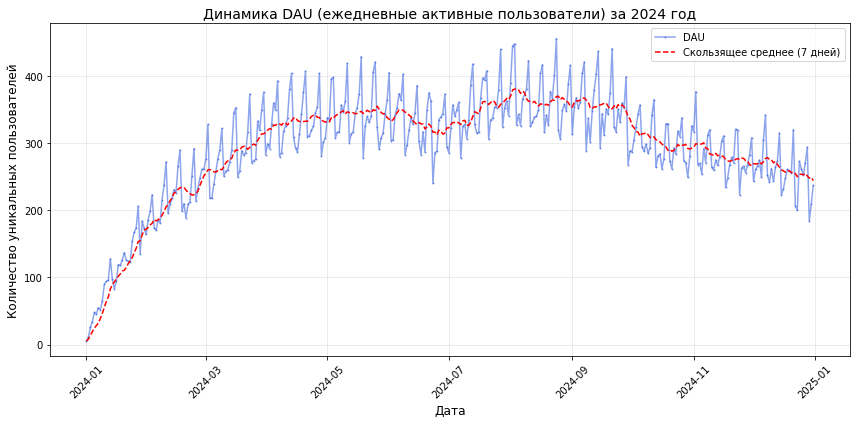

In [38]:
# Визуализация DAU со скользящим средним

plt.figure(figsize=(12, 6))
plt.plot(dau['date'], dau['dau'], marker='.', linestyle='-', linewidth=1.5, markersize=2, 
         color='royalblue', alpha=0.6, label='DAU')

# 7-дневное скользящее среднее
dau['rolling_7'] = dau['dau'].rolling(window=7, min_periods=1).mean()
plt.plot(dau['date'], dau['rolling_7'], linestyle='--', linewidth=1.5, color='red', 
         label='Скользящее среднее (7 дней)')

plt.title('Динамика DAU (ежедневные активные пользователи) за 2024 год', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество уникальных пользователей', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# Посмотрим статистику DAU
print(f"DAU:")
print(f"  Средний DAU за год: {dau['dau'].mean():.0f}")
print(f"  Медианный DAU за год: {dau['dau'].median():.0f}")
print(f"  Минимальный DAU: {dau['dau'].min():.0f}")
print(f"  Максимальный DAU: {dau['dau'].max():.0f}")

DAU:
  Средний DAU за год: 294
  Медианный DAU за год: 308
  Минимальный DAU: 5
  Максимальный DAU: 456


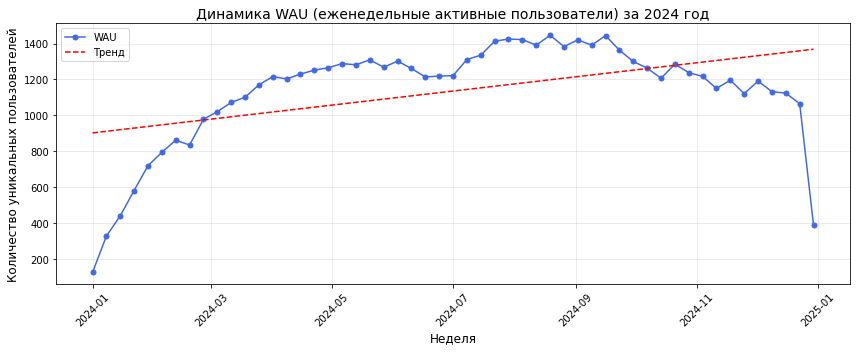

In [40]:
# График WAU c линейным трендом
plt.figure(figsize=(12, 5))
plt.plot(wau['week'], wau['wau'], marker='o', linestyle='-', linewidth=1.5, markersize=5, color='royalblue', label='WAU')

# Линия тренда для WAU
z = np.polyfit(range(len(wau)), wau['wau'], 1)
p = np.poly1d(z)
plt.plot(wau['week'], p(range(len(wau))), linestyle='--', color='red', linewidth=1.5, label='Тренд')

plt.title('Динамика WAU (еженедельные активные пользователи) за 2024 год', fontsize=14)
plt.xlabel('Неделя', fontsize=12)
plt.ylabel('Количество уникальных пользователей', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
# Посмотрим статистику WAU
print(f"WAU:")
print(f"  Средний: {wau['wau'].mean():.0f}")
print(f"  Медианный: {wau['wau'].median():.0f}")
print(f"  Минимальный: {wau['wau'].min():.0f}")
print(f"  Максимальный: {wau['wau'].max():.0f}")

WAU:
  Средний: 1135
  Медианный: 1219
  Минимальный: 126
  Максимальный: 1446


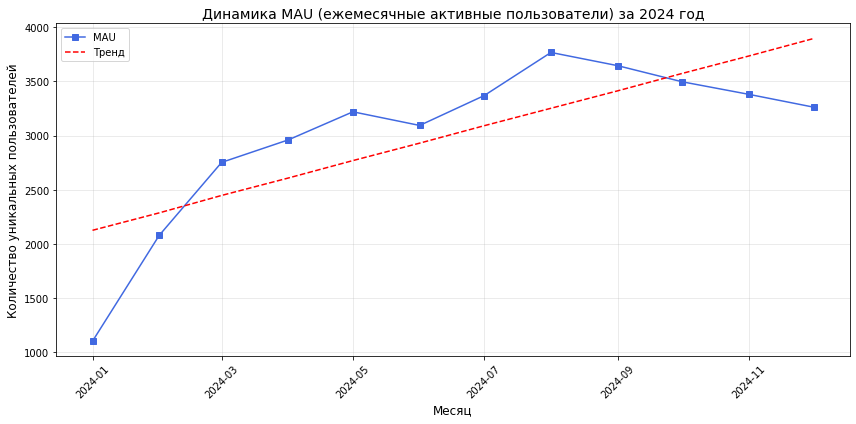

In [42]:
# График MAU с линией тренда
plt.figure(figsize=(12, 6))
plt.plot(mau['month'], mau['mau'], marker='s', linestyle='-', linewidth=1.5, markersize=6, color='royalblue', label='MAU')

# Линия тренда для MAU
z = np.polyfit(range(len(mau)), mau['mau'], 1)
p = np.poly1d(z)
plt.plot(mau['month'], p(range(len(mau))), linestyle='--', color='red', linewidth=1.5, label='Тренд')

plt.title('Динамика MAU (ежемесячные активные пользователи) за 2024 год', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество уникальных пользователей', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# Посмотрим статистику MAU
print(f"MAU (ежемесячно):")
print(f"  Средний MAU за период: {mau['mau'].mean():.0f}")
print(f"  Медианный MAU: {mau['mau'].median():.0f}")
print(f"  Минимальный MAU: {mau['mau'].min():.0f}")
print(f"  Максимальный MAU: {mau['mau'].max():.0f}")

MAU (ежемесячно):
  Средний MAU за период: 3011
  Медианный MAU: 3242
  Минимальный MAU: 1102
  Максимальный MAU: 3768


Для маркетплейса важно понимать, насколько продукт стал частью повседневной жизни пользователей. Высокий коэффициент липкости (обычно 10-20% для e-commerce) говорит о том, что пользователи заходят часто и продукт им нужен. Коэффициент липкости помогает оценить качество удержания. Если он растет - пользователи становятся более лояльными, если падает - возможно, продукт привлекает много "одноразовых" пользователей.

Рассчитаем коэффициент "липкости" как отношение DAU к MAU за каждый месяц. Это показатель того, как часто пользователи возвращаются в продукт. Чем выше коэффициент, тем более вовлечена аудитория.

In [44]:
# Расчет коэффициента липкости (Stickiness = DAU/MAU)

# Подготавливаем данные для расчета по месяцам
# Для каждого месяца считаем средний DAU и MAU
dau['month'] = pd.to_datetime(dau['date']).dt.to_period('M')
monthly_avg_dau = dau.groupby('month')['dau'].mean().reset_index()
monthly_avg_dau.columns = ['month', 'avg_dau']

# MAU у нас уже есть в таблице mau
mau['month_period'] = mau['month'].dt.to_period('M')

# Объединяем данные
stickiness = pd.merge(monthly_avg_dau, mau[['month_period', 'mau']], 
                      left_on='month', right_on='month_period', how='inner')
stickiness['stickiness'] = (stickiness['avg_dau'] / stickiness['mau'] * 100).round(1)

# Преобразуем месяц в datetime для визуализации
stickiness['month_dt'] = stickiness['month'].dt.to_timestamp()

print("Коэффициент липкости (DAU/MAU) по месяцам:")
print(stickiness[['month_dt', 'avg_dau', 'mau', 'stickiness']].to_string(index=False))

Коэффициент липкости (DAU/MAU) по месяцам:
  month_dt    avg_dau  mau  stickiness
2024-01-01 104.967742 1102         9.5
2024-02-01 222.758621 2079        10.7
2024-03-01 290.129032 2753        10.5
2024-04-01 331.366667 2961        11.2
2024-05-01 345.612903 3220        10.7
2024-06-01 330.766667 3094        10.7
2024-07-01 348.580645 3370        10.3
2024-08-01 367.645161 3768         9.8
2024-09-01 350.633333 3646         9.6
2024-10-01 299.612903 3497         8.6
2024-11-01 281.533333 3381         8.3
2024-12-01 257.419355 3263         7.9


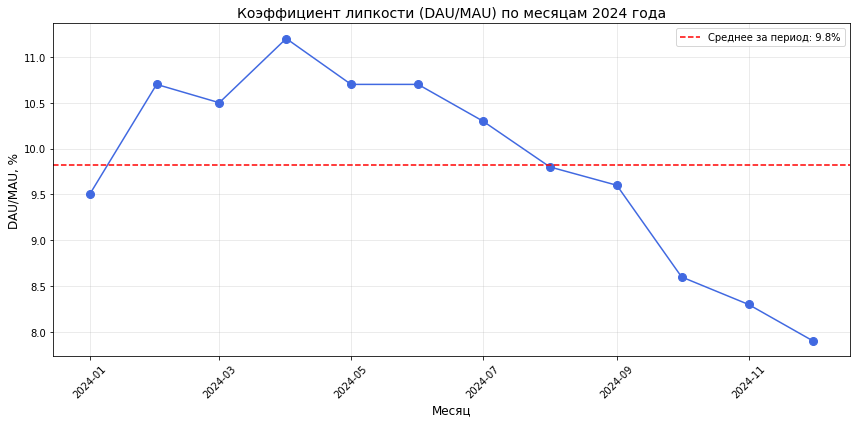

In [45]:
# Визуализация коэффициента липкости

plt.figure(figsize=(12, 6))
plt.plot(stickiness['month_dt'], stickiness['stickiness'], 
         marker='o', linestyle='-', linewidth=1.5, markersize=8, color='royalblue')

# Добавляем горизонтальную линию среднего значения
avg_stickiness = stickiness['stickiness'].mean()
plt.axhline(y=avg_stickiness, color='red', linewidth=1.5, linestyle='--', 
            label=f'Среднее за период: {avg_stickiness:.1f}%')

plt.title('Коэффициент липкости (DAU/MAU) по месяцам 2024 года', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('DAU/MAU, %', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# Посмотрим статистику коэффициента липкости
print(f"\nСредний коэффициент липкости за год: {avg_stickiness:.1f}%")
print(f"Минимальный: {stickiness['stickiness'].min():.1f}%")
print(f"Максимальный: {stickiness['stickiness'].max():.1f}%")


Средний коэффициент липкости за год: 9.8%
Минимальный: 7.9%
Максимальный: 11.2%


**Предварительный вывод по DAU, WAU, MAU и липкости**

Анализ активности пользователей за 2024 год показывает уверенный рост аудитории:

- MAU увеличился с 1102 в январе до пиковых 3768 в августе
- DAU вырос с 5 до 456 пользователей к концу года

Однако коэффициент липкости (DAU/MAU), который отражает частоту возврата пользователей, демонстрирует тревожную динамику: после достижения пика 11,2% в апреле показатель последовательно снизился до 7,9% в декабре, при среднем значении 9,8% за год.

Это снижение свидетельствует о том, что растущая аудитория становится менее вовлеченной. Пользователи приходят реже, а продукт пока не стал для них привычкой. Возможные причины: приток "одноразовых" пользователей через рекламные каналы, недостаточная эффективность механик удержания или сезонное снижение активности в конце года.

Инсайт: Аудитория растет количественно, но при этом качественно вовлеченность падает. Это сигнал о том, что маркетинговые усилия могут быть направлены на привлечение нелояльных пользователей, а продуктовые механики недостаточно удерживают.

Что стоит проверить:
- Удержание у новых пользователей из каналов с высокой стоимостью привлечения (возможно, низкий retention)
- Эффективность персонализированных коммуникаций (push, email) для повышения возвратов

**Revenue (выручка маркетплейса)**

Выручка - главная бизнес-метрика, отражающая финансовый результат деятельности маркетплейса. Заказчику важно понимать, как растет доход, есть ли сезонность, и какие периоды были наиболее успешными.

Рассчитываем выручку маркетплейса как 5% комиссию от общей суммы всех заказов (total_price). Анализируем динамику выручки по месяцам, а также считаем общую выручку за год, среднемесячную и темпы роста.

In [47]:
# Расчет выручки маркетплейса (5% комиссия от суммы заказов)

# Создаем колонку с выручкой маркетплейса
pa_marketplace_orders['revenue'] = pa_marketplace_orders['total_price'] * 0.05

# Общая выручка за год
total_revenue = pa_marketplace_orders['revenue'].sum()
print(f"Общая выручка маркетплейса за 2024 год: {total_revenue:,.2f} руб.")

Общая выручка маркетплейса за 2024 год: 21,348,911.45 руб.


In [48]:
# Выручка по месяцам (используем существующий столбец order_month)
monthly_revenue = pa_marketplace_orders.groupby('order_month')['revenue'].sum().reset_index()
monthly_revenue.columns = ['month', 'revenue']

print("Выручка по месяцам:")
print(monthly_revenue.to_string(index=False))

Выручка по месяцам:
     month      revenue
2024-01-01  623485.5890
2024-02-01 1243809.2825
2024-03-01 1883490.4080
2024-04-01 2093035.3070
2024-05-01 2415453.1770
2024-06-01 2048813.4145
2024-07-01 2367890.5200
2024-08-01 2414997.4655
2024-09-01 1892676.3400
2024-10-01 1666191.6580
2024-11-01 1413289.4925
2024-12-01 1285778.7925


In [49]:
# Дополнительная статистика
print(f"Среднемесячная выручка: {monthly_revenue['revenue'].mean():,.2f} руб.")
print(f"Минимальная месячная выручка: {monthly_revenue['revenue'].min():,.2f} руб.")
print(f"Максимальная месячная выручка: {monthly_revenue['revenue'].max():,.2f} руб.")

Среднемесячная выручка: 1,779,075.95 руб.
Минимальная месячная выручка: 623,485.59 руб.
Максимальная месячная выручка: 2,415,453.18 руб.


Для динамики выручки по месяцам выберем столбчатую диаграмму, она лучше всего показывает сравнение между месяцами и позволяет наглядно увидеть пиковые и провальные периоды. Дополнительно добавим линейную диаграмму для отслеживания динамики.

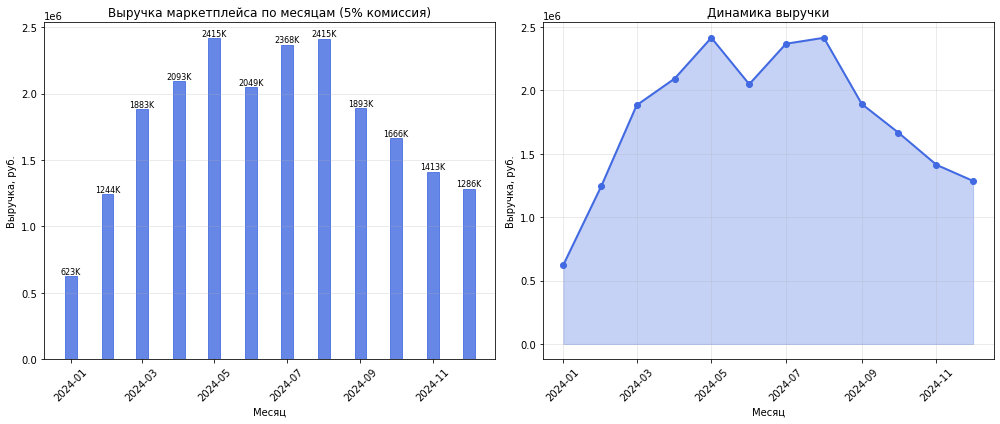

In [50]:
# Визуализация выручки по месяцам

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Столбчатая диаграмма по месяцам с подписями
bars = axes[0].bar(monthly_revenue['month'], monthly_revenue['revenue'], 
                   color='royalblue', edgecolor='royalblue', alpha=0.8, width=10)
axes[0].set_title('Выручка маркетплейса по месяцам (5% комиссия)', fontsize=12)
axes[0].set_xlabel('Месяц', fontsize=10)
axes[0].set_ylabel('Выручка, руб.', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Добавляем подписи значений на столбцы
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 1000,
                 f'{height/1000:.0f}K', ha='center', va='bottom', fontsize=8)

# Линейная диаграмма
axes[1].plot(monthly_revenue['month'], monthly_revenue['revenue'], 
             marker='o', linestyle='-', linewidth=2, markersize=6, color='royalblue')
axes[1].fill_between(monthly_revenue['month'], monthly_revenue['revenue'], 
                     alpha=0.3, color='royalblue')
axes[1].set_title('Динамика выручки', fontsize=12)
axes[1].set_xlabel('Месяц', fontsize=10)
axes[1].set_ylabel('Выручка, руб.', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
# Расчет темпа роста (месяц к месяцу)
monthly_revenue['growth_pct'] = monthly_revenue['revenue'].pct_change() * 100
print("Темп роста выручки (месяц к месяцу):")
for i, row in monthly_revenue.iterrows():
    if i > 0:
        print(f"  {row['month'].strftime('%Y-%m')}: {row['growth_pct']:.1f}%")

Темп роста выручки (месяц к месяцу):
  2024-02: 99.5%
  2024-03: 51.4%
  2024-04: 11.1%
  2024-05: 15.4%
  2024-06: -15.2%
  2024-07: 15.6%
  2024-08: 2.0%
  2024-09: -21.6%
  2024-10: -12.0%
  2024-11: -15.2%
  2024-12: -9.0%


**Предварительный вывод по выручке маркетплейса**

Общая выручка маркетплейса за 2024 год составила 21,35 млн рублей. Динамика выручки показывает уверенный рост в первом полугодии: с января (623 тыс. руб.) по май (2,42 млн руб.) показатель вырос почти в 4 раза, с максимальными темпами в феврале (+99,5%) и марте (+51,4%). Это свидетельствует об успешном старте и эффективном привлечении аудитории в начале года.

Начиная с июня наблюдается устойчивое снижение выручки: падение на 15,2% в июне, затем на 21,6% в сентябре, и продолжение нисходящего тренда до декабря (-9,0%). К концу года выручка составила 1,29 млн рублей - на 47% ниже майского пика. Среднемесячная выручка за год - 1,78 млн рублей.

Снижение во втором полугодии может быть связано с: изменением маркетинговой стратегии, насыщением рынка, снижением эффективности каналов привлечения или проблемами с удержанием аудитории.

Инсайты:
- Первое полугодие стало периодом активного роста. Требуется анализ успешных факторов (каналы, акции, продуктовые изменения)
- Во втором полугодии выручка показала устойчивое снижение, которое требует детального разбора причин

Что проверить:
- Маркетинговый бюджет во втором полугодии — был ли сокращен или перераспределен в менее эффективные каналы
- Снижение коэффициента липкости (с 11,2% до 7,9%) напрямую повлияло на падение выручки
- Проблемы с удержанием пользователей привели к оттоку наиболее ценных клиентов
- Конкурентная среда усилилась, и продукт потерял долю рынка во втором полугодии

**ARPU и ARPPU**

ARPU показывает, сколько денег в среднем приносит каждый активный пользователь - это метрика монетизации всей аудитории. ARPPU показывает, сколько тратит платящий пользователь - это индикатор ценности платежеспособной аудитории. Сравнение этих метрик помогает оценить долю платящих пользователей и потенциал для роста.

In [52]:
# Определяем платящих пользователей (те, у кого есть заказы)
paying_users = pa_marketplace_orders['user_id'].unique()
n_paying = len(paying_users)
print(f"Количество платящих пользователей: {n_paying}")

Количество платящих пользователей: 8654


In [53]:
# Определяем всех активных пользователей (те, у кого есть события)
active_users = pa_marketplace_events['user_id'].unique()
n_active = len(active_users)
print(f"Количество активных пользователей: {n_active}")

Количество активных пользователей: 21602


In [54]:
# Доля платящих среди активных
paying_share = n_paying / n_active * 100
print(f"Доля платящих пользователей: {paying_share:.1f}%")

Доля платящих пользователей: 40.1%


In [55]:
# Общая выручка (уже посчитана в revenue)
total_revenue = pa_marketplace_orders['revenue'].sum()
print(f"Общая выручка: {total_revenue}")

Общая выручка: 21348911.446500003


In [56]:
# ARPU = выручка / все активные пользователи
arpu = total_revenue / n_active
print(f"\nARPU (средний доход на активного пользователя): {arpu:.2f} руб.")

# ARPPU = выручка / платящие пользователи
arppu = total_revenue / n_paying
print(f"ARPPU (средний доход на платящего пользователя): {arppu:.2f} руб.")


ARPU (средний доход на активного пользователя): 988.28 руб.
ARPPU (средний доход на платящего пользователя): 2466.94 руб.


Посмотрим еще ARPPU по месяцам

In [57]:
# Активные пользователи по месяцам
active_by_month = pa_marketplace_events.groupby('event_month')['user_id'].nunique().reset_index()
active_by_month.columns = ['month', 'active_users']

# Платящие пользователи и выручка по месяцам (из заказов)
# После groupby колонка будет называться 'order_month'
paying_by_month = pa_marketplace_orders.groupby('order_month').agg(
    paying_users=('user_id', 'nunique'),
    revenue=('revenue', 'sum')
).reset_index()

# Переименовываем колонку для корректного merge
paying_by_month = paying_by_month.rename(columns={'order_month': 'month'})

# Объединяем
arpu_arppu_monthly = pd.merge(active_by_month, paying_by_month, on='month', how='left')

# Заполняем NaN для месяцев без заказов
arpu_arppu_monthly['paying_users'] = arpu_arppu_monthly['paying_users'].fillna(0)
arpu_arppu_monthly['revenue'] = arpu_arppu_monthly['revenue'].fillna(0)

arpu_arppu_monthly.head(10)

,month,active_users,paying_users,revenue
0,2024-01-01,1102,439,6.234856e+05
1,2024-02-01,2079,804,1.243809e+06
2,2024-03-01,2753,1128,1.883490e+06
3,2024-04-01,2961,1287,2.093035e+06
4,2024-05-01,3220,1362,2.415453e+06
5,2024-06-01,3094,1201,2.048813e+06
6,2024-07-01,3370,1349,2.367891e+06
7,2024-08-01,3768,1348,2.414997e+06
8,2024-09-01,3646,1138,1.892676e+06
9,2024-10-01,3497,972,1.666192e+06


In [58]:
# Расчет метрик
arpu_arppu_monthly['arpu'] = arpu_arppu_monthly['revenue'] / arpu_arppu_monthly['active_users']
# ARPPU считаем только для месяцев с платящими, иначе NaN
arpu_arppu_monthly['arppu'] = arpu_arppu_monthly.apply(
    lambda row: row['revenue'] / row['paying_users'] if row['paying_users'] > 0 else np.nan, axis=1
)
arpu_arppu_monthly['paying_share'] = (arpu_arppu_monthly['paying_users'] / arpu_arppu_monthly['active_users'] * 100).round(1)

print("Динамика ARPU и ARPPU по месяцам:")
print(arpu_arppu_monthly[['month', 'active_users', 'paying_users', 'paying_share', 'revenue', 'arpu', 'arppu']].round(2).to_string(index=False))

Динамика ARPU и ARPPU по месяцам:
     month  active_users  paying_users  paying_share    revenue   arpu   arppu
2024-01-01          1102           439          39.8  623485.59 565.78 1420.24
2024-02-01          2079           804          38.7 1243809.28 598.27 1547.03
2024-03-01          2753          1128          41.0 1883490.41 684.16 1669.76
2024-04-01          2961          1287          43.5 2093035.31 706.87 1626.29
2024-05-01          3220          1362          42.3 2415453.18 750.14 1773.46
2024-06-01          3094          1201          38.8 2048813.41 662.19 1705.92
2024-07-01          3370          1349          40.0 2367890.52 702.64 1755.29
2024-08-01          3768          1348          35.8 2414997.47 640.92 1791.54
2024-09-01          3646          1138          31.2 1892676.34 519.11 1663.16
2024-10-01          3497           972          27.8 1666191.66 476.46 1714.19
2024-11-01          3381           817          24.2 1413289.49 418.01 1729.85
2024-12-01        

Для визуализации потроим два графика:
- Линейные диаграммы для динамики ARPU и ARPPU по месяцам (показывают тренды монетизации)
- Столбчатую диаграмму для доли платящих пользователей (показывает, какая часть активной аудитории совершает покупки)

Совместный анализ этих графиков позволяет увидеть взаимосвязь: если ARPU растет, но доля платящих падает - значит, оставшиеся платящие пользователи стали тратить больше. Если падают оба показателя - это очень тревожный сигнал.

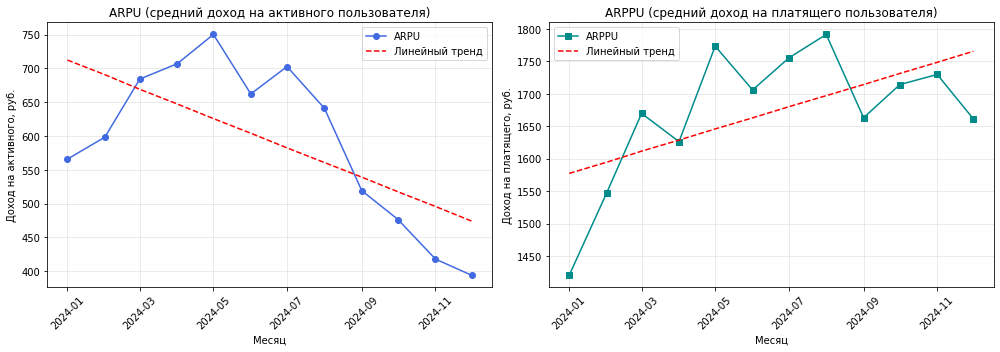

In [59]:
# Линейные диаграммы для динамики ARPU и ARPPU по месяцам

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График ARPU
axes[0].plot(arpu_arppu_monthly['month'], arpu_arppu_monthly['arpu'], 
             marker='o', linestyle='-', linewidth=1.5, markersize=6, 
             color='royalblue', label='ARPU')

# Линия тренда для ARPU
z = np.polyfit(range(len(arpu_arppu_monthly)), arpu_arppu_monthly['arpu'], 1)
p = np.poly1d(z)
axes[0].plot(arpu_arppu_monthly['month'], p(range(len(arpu_arppu_monthly))), 
             linestyle='--', color='red', linewidth=1.5, label='Линейный тренд')

axes[0].set_title('ARPU (средний доход на активного пользователя)', fontsize=12)
axes[0].set_xlabel('Месяц', fontsize=10)
axes[0].set_ylabel('Доход на активного, руб.', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# График ARPPU с линией тренда
axes[1].plot(arpu_arppu_monthly['month'], arpu_arppu_monthly['arppu'], 
             marker='s', linestyle='-', linewidth=1.5, markersize=6, 
             color='darkcyan', label='ARPPU')

# Линия тренда для ARPPU
z = np.polyfit(range(len(arpu_arppu_monthly)), arpu_arppu_monthly['arppu'], 1)
p = np.poly1d(z)
axes[1].plot(arpu_arppu_monthly['month'], p(range(len(arpu_arppu_monthly))), 
             linestyle='--', color='red', linewidth=1.5, label='Линейный тренд')

axes[1].set_title('ARPPU (средний доход на платящего пользователя)', fontsize=12)
axes[1].set_xlabel('Месяц', fontsize=10)
axes[1].set_ylabel('Доход на платящего, руб.', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

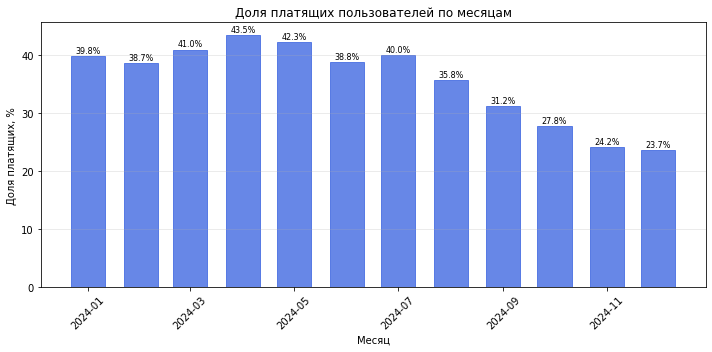

In [60]:
# График Доля платящих пользователей
plt.figure(figsize=(10, 5))
plt.bar(arpu_arppu_monthly['month'], arpu_arppu_monthly['paying_share'], 
        color='royalblue', edgecolor='royalblue', alpha=0.8, width=20)
plt.title('Доля платящих пользователей по месяцам', fontsize=12)
plt.xlabel('Месяц', fontsize=10)
plt.ylabel('Доля платящих, %', fontsize=10)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Добавляем подписи значений на столбцы
for i, (x, y) in enumerate(zip(arpu_arppu_monthly['month'], arpu_arppu_monthly['paying_share'])):
    plt.text(x, y + 0.5, f'{y:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

**Предварительный вывод по ARPU и ARPPU**

**Предварительный вывод по ARPU и ARPPU**

Средний доход на активного пользователя (ARPU) за год составил 988,28 руб., а на платящего (ARPPU) - 2 466,94 руб. Доля платящих среди активных пользователей - 40,1%, что является хорошим показателем для маркетплейса: более трети активной аудитории совершает покупки.

Динамика ARPU демонстрирует тревожный тренд: показатель вырос с 565,78 руб. в январе до пиковых 750,14 руб. в мае, после чего начал устойчивое снижение до 394,05 руб. в декабре. ARPPU при этом остается стабильным на протяжении всего года (колеблется в диапазоне 1 420–1 792 руб.). Это говорит о том, что платящие пользователи не изменили свое покупательское поведение, то есть проблема не в них.

Инсайт:

Падение ARPU вызвано снижением доли платящих пользователей (с 43,5% в апреле до 23,7% в декабре). Это означает, что продукт привлекает все больше активных пользователей, которые не конвертируются в покупки. Основная точка роста: увеличение конверсии активных пользователей в платящих, а не повышение чека существующих покупателей.

Что проверить:
- Каналы привлечения во втором полугодии — возможно, привели нецелевую аудиторию с низкой покупательской способностью. Необходимо проанализировать конверсию в покупку в разрезе каналов
- Продуктовые изменения или баги на этапе оформления заказа — возможно, отпугивают новых пользователей. Нужен анализ воронки покупки по месяцам
- Отсутствие триггерных коммуникаций (push-уведомления, email) для новых активных пользователей — возможно, снижает их конверсию в первую покупку

**AOV (средний чек)**

 AOV показывает покупательскую способность аудитории и эффективность стратегий по увеличению чека (кросс-продажи, апсейлы, акции и т.п.). Для маркетплейса важно понимать, меняется ли средний чек со временем, есть ли сезонные колебания и какие категории товаров формируют высокий чек.
 
Рассчитаем среднюю сумму одного заказа как отношение общей выручки (total_price) к количеству заказов. Пронализируем динамику среднего чека по месяцам, общий AOV за год, а также распределение чеков.

In [61]:
# Общее количество заказов
total_orders = pa_marketplace_orders['order_id'].nunique()
print(f"Общее количество заказов: {total_orders}")

# Общая сумма заказов (total_price, не комиссия)
total_gmv = pa_marketplace_orders['total_price'].sum()
print(f"Общая сумма заказов (GMV): {total_gmv:,.2f} руб.")

Общее количество заказов: 30446
Общая сумма заказов (GMV): 426,978,228.93 руб.


In [62]:
# AOV за год
aov_total = total_gmv / total_orders
print(f"AOV (средний чек) за год: {aov_total:.2f} руб.")

AOV (средний чек) за год: 14024.12 руб.


In [63]:
# AOV по месяцам (используем order_month)
monthly_aov = pa_marketplace_orders.groupby('order_month').agg(
    orders=('order_id', 'count'),
    gmv=('total_price', 'sum')
).reset_index()
monthly_aov['aov'] = monthly_aov['gmv'] / monthly_aov['orders']
monthly_aov.columns = ['month', 'orders', 'gmv', 'aov']

print("\nДинамика AOV по месяцам:")
print(monthly_aov[['month', 'orders', 'gmv', 'aov']].round(2).to_string(index=False))


Динамика AOV по месяцам:
     month  orders         gmv      aov
2024-01-01     930 12469711.78 13408.29
2024-02-01    1841 24876185.65 13512.32
2024-03-01    2699 37669808.16 13956.95
2024-04-01    3046 41860706.14 13742.85
2024-05-01    3414 48309063.54 14150.28
2024-06-01    2992 40976268.29 13695.28
2024-07-01    3318 47357810.40 14273.00
2024-08-01    3300 48299949.31 14636.35
2024-09-01    2700 37853526.80 14019.82
2024-10-01    2408 33323833.16 13838.80
2024-11-01    1918 28265789.85 14737.12
2024-12-01    1880 25715575.85 13678.50


In [64]:
# Посмотрим еще min и max
print(f"Минимальный средний чек по месяцам: {monthly_aov['aov'].min():.2f} руб.")
print(f"Максимальный средний чек по месяцам: {monthly_aov['aov'].max():.2f} руб.")

Минимальный средний чек по месяцам: 13408.29 руб.
Максимальный средний чек по месяцам: 14737.12 руб.


Теперь визуализируем результаты. Построим линейную диаграмму  динамики среднего чека по месяцам (показывает тренды и сезонность) и гистограмму распределения заказов (для понимания, какие чеки встречаются чаще всего, есть ли много мелких или крупных заказов).

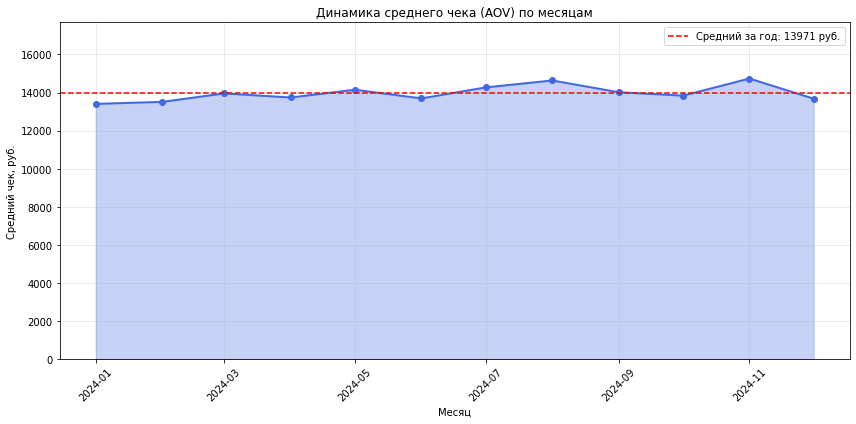

In [65]:
# Динамика среднего чека по месяцам
plt.figure(figsize=(12, 6))
plt.plot(monthly_aov['month'], monthly_aov['aov'], 
         marker='o', linestyle='-', linewidth=2, markersize=6, 
         color='royalblue')
plt.fill_between(monthly_aov['month'], monthly_aov['aov'], 
                 alpha=0.3, color='royalblue')
plt.title('Динамика среднего чека (AOV) по месяцам', fontsize=12)
plt.xlabel('Месяц', fontsize=10)
plt.ylabel('Средний чек, руб.', fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
# Для читаемости: ось Y от 0 с запасом сверху
y_max = monthly_aov['aov'].max()
plt.ylim(0, y_max * 1.2)

# Добавляем линию среднего значения
avg_aov_line = monthly_aov['aov'].mean()
plt.axhline(y=avg_aov_line, color='red', linestyle='--', 
            label=f'Средний за год: {avg_aov_line:.0f} руб.')
plt.legend()
plt.tight_layout()
plt.show()

In [66]:
# Разница между средним и медианным чеком
print(f"Средний чек (AOV): {aov_total:.2f} руб.")
print(f"Медианный чек: {pa_marketplace_orders['total_price'].median():.2f} руб.")
if aov_total > pa_marketplace_orders['total_price'].median():
    print("Средний чек выше медианного. Есть крупные заказы, которые тянут среднее вверх.")
else:
    print("Средний чек близок к медианному. Распределение относительно равномерное.")

Средний чек (AOV): 14024.12 руб.
Медианный чек: 7552.44 руб.
Средний чек выше медианного. Есть крупные заказы, которые тянут среднее вверх.


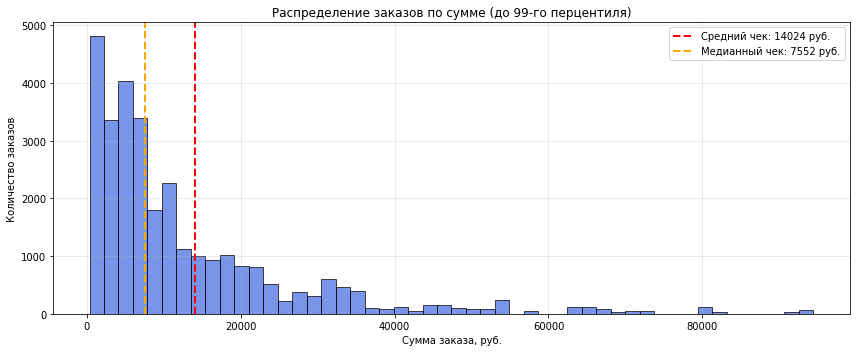

In [67]:
# Гистограмма распределения заказов по сумме
percentile_99 = pa_marketplace_orders['total_price'].quantile(0.99)
filtered_orders = pa_marketplace_orders[pa_marketplace_orders['total_price'] <= percentile_99]

plt.figure(figsize=(12, 5))
plt.hist(filtered_orders['total_price'], bins=50, color='royalblue', edgecolor='black', alpha=0.7)
plt.axvline(x=aov_total, color='red', linestyle='--', linewidth=2, label=f'Средний чек: {aov_total:.0f} руб.')
plt.axvline(x=pa_marketplace_orders['total_price'].median(), color='orange', linestyle='--', linewidth=2, label=f'Медианный чек: {pa_marketplace_orders["total_price"].median():.0f} руб.')
plt.title('Распределение заказов по сумме (до 99-го перцентиля)', fontsize=12)
plt.xlabel('Сумма заказа, руб.', fontsize=10)
plt.ylabel('Количество заказов', fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Предварительный вывод по AOV**

Средний чек за год составил 14024 руб., при этом медианный чек - 7552 руб. Такое расхождение объясняется наличием крупных заказов (например, диваны по 191797 руб.), которые смещают среднее значение вверх. Более репрезентативным показателем является медиана: половина заказов дешевле 7552 руб., половина - дороже.

Динамика AOV по месяцам стабильна: минимальное значение в январе (13 408 руб.), максимальное в ноябре (14 737 руб.). Колебания незначительны (около 5% от среднегодового значения), что говорит об отсутствии резких изменений покупательской способности аудитории.

Инсайт:

Проблема снижения выручки во втором полугодии связана не с тем, что пользователи стали покупать дешевле (AOV стабилен), а с уменьшением количества заказов (с пиковых 3 414 в мае до 1 880 в декабре). Это прямо коррелирует со снижением доли платящих пользователей (с 43,5% до 23,7%) и падением ARPU.

Что проверить:
- Снижение количества заказов связано с падением конверсии в покупку? Необходимо проанализировать воронку продаж
- Маркетинговые кампании во втором полугодии — возможно, привлекли меньше трафика или менее целевых пользователей
- Пользователи стали реже возвращаться за повторными покупками — необходимо проверить динамику retention

**Retention Rate (коэффициент удержания)**

Retention Rate - это ключевая метрика лояльности, которая показывает, какой процент пользователей возвращается в продукт спустя заданное время после регистрации. Низкое удержание - главный индикатор того, что продукт не решает проблемы пользователей, и бизнес вынужден постоянно тратить бюджет на привлечение новых, вместо того чтобы зарабатывать на существующих.

Для маркетплейса, где покупки не являются ежедневной историей (в отличие от соцсетей или мессенджеров), мы будем использовать недельные окна. Жесткая привязка к конкретному дню (7, 14, 21, 30) приводит к потере значительной части данных о возвратах, так как пользователи заходят в продукт не ежедневно, а по мере возникновения потребности в покупке. Недельные окна позволяют учесть естественные колебания в поведении пользователей, которые могут зайти на день раньше или позже, и дают более реалистичную картину лояльности аудитории. Далее также посмотрим долгосрочное удержание по месячным окнам.


- Определяем горизонт анализа

Данные у нас за полный 2024 год. Пользователи, зарегистрировавшиеся в декабре, не смогут показать удержание на 5-й неделе до конца года. Поэтому для чистоты расчетов мы ограничим когорты теми, кто зарегистрировался достаточно давно. Для анализа удержания на 5 недель нам подойдут когорты с января по ноябрь 2024 года.

- Формируем когорты пользователей

Берем всех пользователей, зарегистрировавшихся в 2024 году. Для каждого определяем его когорту (месяц регистрации). Первая неделя (week_1, дни 0-6) по определению равна 100% для всех пользователей, так как сам факт регистрации уже является действием.

- Определяем даты «возвратов»

Для каждого пользователя нужно понять, был ли он активен (совершил любое событие из таблицы events) в определенные периоды после регистрации. Для этого для каждого события считаем, сколько дней прошло с даты регистрации, и оставляем только события, попавшие в нужные нам недельные окна: 7-13 дни (неделя 2), 14-20 дни (неделя 3), 21-27 дни (неделя 4), 28-34 дни (неделя 5).

- Рассчитываем Retention Rate (недельные окна)

Для каждой когорты (месяца регистрации) и для каждого дня после регистрации считаем:

retention= (Количество уникальных пользователей когорты, которые были активны в этот день/ Общее количество пользователей в когорте) × 100%

In [68]:
# Расчет когортного Retention Rate (недельные окна)
# week_1 (дни 0-6) = 100% по определению (факт регистрации)

# Формируем таблицу с когортами пользователей
cohorts = pa_marketplace_users[['user_id', 'registration_date']].copy()
cohorts['cohort_month'] = cohorts['registration_date'].dt.to_period('M')

# Считаем размер каждой когорты
cohort_sizes = cohorts.groupby('cohort_month')['user_id'].nunique().reset_index()
cohort_sizes.columns = ['cohort_month', 'cohort_size']

print(f"Всего пользователей для анализа удержания: {cohorts['user_id'].nunique()}")
print("\nРазмер когорт по месяцам:")
print(cohort_sizes.to_string(index=False))

Всего пользователей для анализа удержания: 44151

Размер когорт по месяцам:
cohort_month  cohort_size
     2024-01         2985
     2024-02         2711
     2024-03         2965
     2024-04         2905
     2024-05         3066
     2024-06         2810
     2024-07         4388
     2024-08         4431
     2024-09         4466
     2024-10         4440
     2024-11         4383
     2024-12         4601


In [69]:
# Получаем активности пользователей из events
user_activity = pa_marketplace_events[['user_id', 'event_date']].drop_duplicates()

# Объединяем активности с информацией о регистрации
cohort_activity = user_activity.merge(cohorts, on='user_id', how='inner')

# Вычисляем день после регистрации
cohort_activity['days_since_reg'] = (cohort_activity['event_date'] - cohort_activity['registration_date']).dt.days

# Определяем недельные окна
def get_week_window(days):
    if days <= 6:
        return 'week_1'
    elif 7 <= days <= 13:
        return 'week_2'
    elif 14 <= days <= 20:
        return 'week_3'
    elif 21 <= days <= 27:
        return 'week_4'
    elif 28 <= days <= 34:
        return 'week_5'
    else:
        return 'later'

cohort_activity['week_window'] = cohort_activity['days_since_reg'].apply(get_week_window)

# Фильтруем недели 2-5
weekly_retention = cohort_activity[cohort_activity['week_window'].isin(['week_2', 'week_3', 'week_4', 'week_5'])]

# Считаем количество уникальных пользователей по когортам и неделям
weekly_counts = weekly_retention.groupby(['cohort_month', 'week_window'])['user_id'].nunique().reset_index()
weekly_counts.columns = ['cohort_month', 'week_window', 'returning_users']

# Создаем сводную таблицу и заполняем NaN нулями
weekly_pivot = weekly_counts.pivot(index='cohort_month', 
                                    columns='week_window', 
                                    values='returning_users').reset_index().fillna(0)

# Добавляем размер когорт
weekly_pivot = weekly_pivot.merge(cohort_sizes, on='cohort_month', how='left')

# Рассчитываем retention для недель 2-5
for week in ['week_2', 'week_3', 'week_4', 'week_5']:
    if week in weekly_pivot.columns:
        weekly_pivot[f'{week}_rate'] = (weekly_pivot[week] / weekly_pivot['cohort_size'] * 100).round(1)
    else:
        weekly_pivot[f'{week}_rate'] = 0

# Добавляем week_1 = 100%
weekly_pivot.insert(1, 'week_1_rate', 100)

# Переименовываем колонки
weekly_pivot = weekly_pivot.rename(columns={
    'week_2_rate': 'Неделя 2 (дни 7-13)',
    'week_3_rate': 'Неделя 3 (дни 14-20)',
    'week_4_rate': 'Неделя 4 (дни 21-27)',
    'week_5_rate': 'Неделя 5 (дни 28-34)'
})

print("\nКогортный Retention Rate по месяцам (недельные окна, %):")
print(weekly_pivot[['cohort_month', 'week_1_rate', 'Неделя 2 (дни 7-13)', 
                    'Неделя 3 (дни 14-20)', 'Неделя 4 (дни 21-27)', 
                    'Неделя 5 (дни 28-34)']].to_string(index=False))


Когортный Retention Rate по месяцам (недельные окна, %):
cohort_month  week_1_rate  Неделя 2 (дни 7-13)  Неделя 3 (дни 14-20)  Неделя 4 (дни 21-27)  Неделя 5 (дни 28-34)
     2024-01          100                 22.6                  20.1                  17.1                  13.9
     2024-02          100                 23.7                  20.7                  17.7                  15.0
     2024-03          100                 23.7                  21.1                  18.1                  14.9
     2024-04          100                 24.1                  20.8                  18.1                  14.1
     2024-05          100                 22.4                  19.7                  15.9                  13.2
     2024-06          100                 20.6                  17.4                  14.8                  12.5
     2024-07          100                 19.4                  16.4                  13.4                  11.9
     2024-08          100             

Для визуализации когортного retention лучше всего подходит тепловая карта (heatmap). Она позволяет одним взглядом охватить динамику удержания по всем когортам и неделям: где показатели высоки (зеленые/теплые оттенки), а где провалы (холодные оттенки). Линейные графики здесь менее информативны, так как на них сложно сравнивать 12 когорт одновременно.

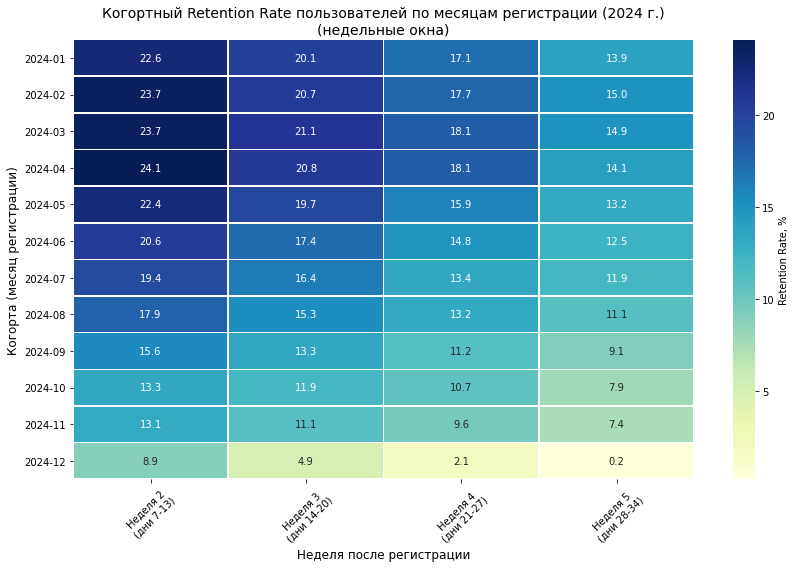

In [70]:
# Визуализация когортного Retention Rate (недельные окна)

# Подготавливаем данные для тепловой карты, исключая week_1 (она всегда 100%)
retention_heatmap_data = weekly_pivot.set_index('cohort_month')[
    ['Неделя 2 (дни 7-13)', 'Неделя 3 (дни 14-20)', 
     'Неделя 4 (дни 21-27)', 'Неделя 5 (дни 28-34)']
].astype(float)

plt.figure(figsize=(12, 8))

sns.heatmap(retention_heatmap_data, 
            annot=True, 
            fmt='.1f', 
            cmap='YlGnBu', 
            linewidths=0.5, 
            cbar_kws={'label': 'Retention Rate, %'})

plt.title('Когортный Retention Rate пользователей по месяцам регистрации (2024 г.)\n(недельные окна)', fontsize=14)
plt.xlabel('Неделя после регистрации', fontsize=12)
plt.ylabel('Когорта (месяц регистрации)', fontsize=12)
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5], 
           labels=['Неделя 2\n(дни 7-13)', 'Неделя 3\n(дни 14-20)', 
                   'Неделя 4\n(дни 21-27)', 'Неделя 5\n(дни 28-34)'], 
           rotation=45)
plt.tight_layout()
plt.show()

Как будто-бы прямо плохо с удержанием. Посмотрим долю пользователей, которые зарегистрировались, но не совершили никаких значимых (целевых) действий. В контексте маркетплейса "целевое действие" - это любое событие, кроме самой регистрации. Таких пользователей называют "мертвые души" или "неактивированные пользователи".

In [71]:
# Расчет доли пользователей без единого действия после регистрации

# Получаем список всех зарегистрированных пользователей
all_users = pa_marketplace_users[['user_id', 'registration_date']].copy()
all_users['reg_month'] = all_users['registration_date'].dt.to_period('M')

print(f"Всего зарегистрированных пользователей: {all_users['user_id'].nunique()}")

# Получаем список пользователей, у которых есть хотя бы одно событие в events
active_users = pa_marketplace_events['user_id'].unique()
print(f"Пользователей с хотя бы одним событием: {len(active_users)}")

# Находим "мертвых" пользователей
all_users_set = set(all_users['user_id'])
active_users_set = set(active_users)

dead_users_count = len(all_users_set - active_users_set)
dead_users_share = (dead_users_count / len(all_users_set)) * 100

print(f"\nПользователей без единого действия: {dead_users_count}")
print(f"Доля 'мертвых' пользователей: {dead_users_share:.1f}%")
print(f"Доля активированных пользователей: {100 - dead_users_share:.1f}%")

Всего зарегистрированных пользователей: 44151
Пользователей с хотя бы одним событием: 21602

Пользователей без единого действия: 22549
Доля 'мертвых' пользователей: 51.1%
Доля активированных пользователей: 48.9%


Посмотрим еще long-term аналитику: помимо анализа удержания на первых неделях, важно понимать, как пользователи возвращаются в продукт в долгосрочной перспективе. Месячный retention показывает, какая часть пользователей остается с продуктом спустя 1, 2, 3 и более месяцев после регистрации. Это критически важно для оценки долгосрочной ценности клиента (LTV) и эффективности стратегий удержания.

Что делаем:
- Формируем когорты (группируем пользователей по месяцу регистрации)
- Для каждого пользователя проверяем, был ли он активен (совершил любое событие) в календарные месяцы после регистрации
- Считаем retention: для каждой когорты и для каждого последующего месяца вычисляем долю пользователей, которые были активны в этом месяце. Для когорт, которые еще не "дожили" до определенного месяца (например, декабрьская когорта не может показать удержание на 2-й месяц), в таблице будет указан NaN. Это корректный подход, отличающий отсутствие данных от нулевого удержания (когда пользователи были, но никто не вернулся).

In [72]:
# Расчет долгосрочного Retention Rate по месяцам

# Используем уже созданные cohorts и cohort_sizes

# Получаем активности пользователей из events
user_activity = pa_marketplace_events[['user_id', 'event_date']].drop_duplicates()

# Добавляем месяц события
user_activity['event_month'] = user_activity['event_date'].dt.to_period('M')

# Объединяем с когортами
cohort_activity = user_activity.merge(cohorts, on='user_id', how='inner')

# Вычисляем сколько месяцев прошло с регистрации до события
cohort_activity['months_since_reg'] = (cohort_activity['event_month'].astype(int) - 
                                        cohort_activity['cohort_month'].astype(int))

# Оставляем только события после регистрации
monthly_retention = cohort_activity[cohort_activity['months_since_reg'] > 0]

# Определяем максимальное количество месяцев для анализа
max_months = monthly_retention['months_since_reg'].max()

# Считаем уникальных пользователей по когортам и месяцам
monthly_counts = monthly_retention.groupby(['cohort_month', 'months_since_reg'])['user_id'].nunique().reset_index()
monthly_counts.columns = ['cohort_month', 'months_since_reg', 'returning_users']

# Создаем сводную таблицу
monthly_pivot = monthly_counts.pivot(index='cohort_month', 
                                      columns='months_since_reg', 
                                      values='returning_users').reset_index()

# Добавляем размер когорт
monthly_pivot = monthly_pivot.merge(cohort_sizes, on='cohort_month', how='left')

# Рассчитываем retention для каждого месяца
for month in range(1, max_months + 1):
    if month in monthly_pivot.columns:
        monthly_pivot[f'{month} месяц'] = (monthly_pivot[month] / monthly_pivot['cohort_size'] * 100).round(1)
    else:
        monthly_pivot[f'{month} месяц'] = np.nan

# Формируем финальную таблицу
output_columns = ['cohort_month'] + [f'{month} месяц' for month in range(1, max_months + 1)]

print(f"Долгосрочный Retention Rate по месячным окнам")
print(monthly_pivot[output_columns].to_string(index=False, na_rep='NaN'))

Долгосрочный Retention Rate по месячным окнам
cohort_month  1 месяц  2 месяц  3 месяц  4 месяц  5 месяц  6 месяц  7 месяц  8 месяц  9 месяц  10 месяц  11 месяц
     2024-01     36.9     17.7      8.2      4.1      1.8      0.9      0.4      0.0      0.1       0.0       0.0
     2024-02     40.5     17.9      9.0      4.7      1.8      0.9      0.4      0.1      0.0       0.1       NaN
     2024-03     37.6     19.2      9.3      4.3      2.1      0.8      0.3      0.1      0.1       NaN       NaN
     2024-04     39.3     19.4      9.4      4.8      2.3      1.1      0.7      0.3      NaN       NaN       NaN
     2024-05     36.9     17.2      7.7      3.6      1.6      0.5      0.2      NaN      NaN       NaN       NaN
     2024-06     34.3     17.0      7.6      3.8      1.8      0.5      NaN      NaN      NaN       NaN       NaN
     2024-07     32.7     14.9      7.1      3.6      1.3      NaN      NaN      NaN      NaN       NaN       NaN
     2024-08     30.2     14.2      7.4   

Для визуализации долгосрочного retention по месяцам также используем тепловую карту. Она позволяет наглядно увидеть, как меняется удержание на разных временных горизонтах и для разных когорт.

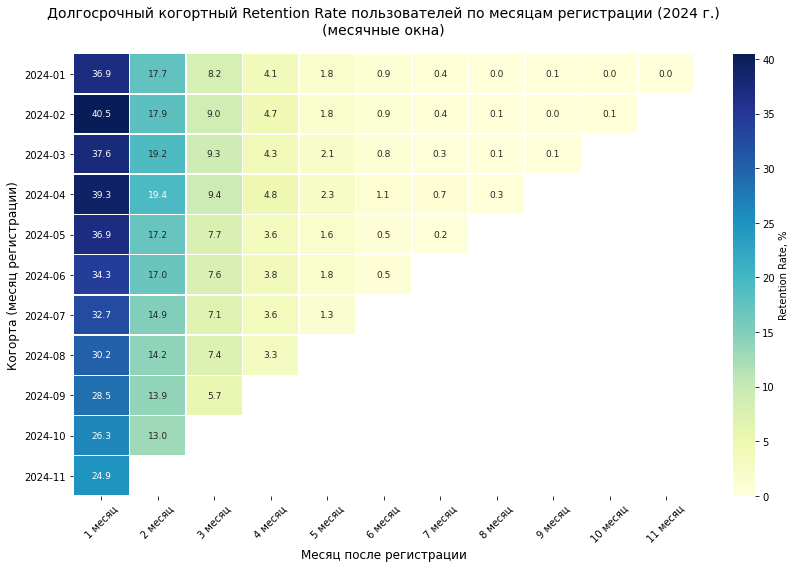

In [73]:
# Подготавливаем данные для тепловой карты
retention_monthly_data = monthly_pivot.set_index('cohort_month')[[f'{month} месяц' for month in range(1, max_months + 1)]].astype(float)

# Настраиваем размер графика
plt.figure(figsize=(max(12, max_months * 0.7), max(8, len(retention_monthly_data) * 0.5)))

# Строим тепловую карту
sns.heatmap(retention_monthly_data, 
            annot=True, 
            fmt='.1f', 
            cmap='YlGnBu', 
            linewidths=0.5, 
            cbar_kws={'label': 'Retention Rate, %'},
            annot_kws={'fontsize': 9})

plt.title('Долгосрочный когортный Retention Rate пользователей по месяцам регистрации (2024 г.)\n(месячные окна)', 
          fontsize=14, pad=20)
plt.xlabel('Месяц после регистрации', fontsize=12)
plt.ylabel('Когорта (месяц регистрации)', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Предварительный вывод по удержанию (Retention Rate)**

Анализ удержания пользователей выявил несколько ключевых моментов, которые требуют внимания бизнеса.

- Крайне высокая доля "мертвых душ"

Из всех зарегистрировавшихся в 2024 году пользователей 51.1% не совершили ни одного действия после регистрации. Это означает, что более половины маркетингового бюджета на привлечение потрачена впустую. Эти пользователи даже не начали взаимодействие с продуктом. Доля активированных пользователей составляет лишь 48.9%.

- Удержание среди активированных пользователей

Для тех, кто хотя бы начал взаимодействовать с продуктом, удержание на недельных окнах выглядит следующим образом:

    - На 2-й неделе (дни 7-13) возвращается в среднем 15-24% пользователей (в зависимости от когорты)
    - На 3-й неделе (дни 14-20) — 13-21%
    - На 4-й неделе (дни 21-27) — 11-18%
    - На 5-й неделе (дни 28-34) — 9-15%

Для e-commerce это умеренные показатели. Они показывают, что продукт способен удерживать часть аудитории, но потенциал для роста остается значительным.

- Тревожный тренд: удержание падает для поздних когорт

    - Наблюдается устойчивое снижение удержания от ранних когорт (январь-март) к поздним (сентябрь-ноябрь):
    - Удержание на 5-й неделе у когорты января — 13.9%, у когорты ноября — 7.4% (падение почти в 2 раза)
    - Удержание на 2-й неделе у когорты января — 22.6%, у когорты ноября — 13.1%

Это тревожный сигнал. Продукт стал хуже удерживать пользователей во втором полугодии. Возможные причины: ухудшение качества трафика из каналов привлечения, снижение эффективности онбординга, рост конкуренции или накопившиеся технические проблемы.

- Долгосрочное удержание (месячные окна)

На месячных окнах картина ожидаемо более размытая, но тренд сохраняется:

    - На 1-й месяц удержание составляет 25-40% (пик у февраля 40.5%)
    - На 3-й месяц 6-9%
    - На 6-й месяц 0.5-1.1%
    - На 11-й месяц (только для январской когорты) 0.0%

Долгосрочное удержание крайне низкое: к 6-му месяцу с продуктом остается менее 1% пользователей. Это означает, что продукт не формирует устойчивую лояльную аудиторию, и бизнес вынужден постоянно привлекать новых пользователей для поддержания выручки.

Ключевые инсайты и точки роста:

- Первая и главная проблема 51.1% "мертвых душ". Необходимо срочно проанализировать каналы привлечения. Возможно, какие-то каналы дают много нецелевого трафика, который не конвертируется даже в первое действие. Также стоит проверить онбординг, не возникает ли у пользователей технических проблем при первом входе.

- Удержание среди активированных пользователей требует улучшения. Даже те, кто начал взаимодействие, массово уходят после 2-3 недель. Точки роста: триггерные коммуникации (push, email) на 3-7 день после регистрации, персонализированные рекомендации, промокод на второй заказ.

- Падение удержания в поздних когортах это сигнал о системных проблемах. Необходимо сравнить качество трафика по месяцам, проанализировать изменения в продукте во втором полугодии (возможно, были неудачные обновления), а также оценить конкурентную среду.

- Долгосрочное удержание близко к нулю - это критично для LTV. Без возврата пользователей спустя 3-6 месяцев бизнес не может окупать затраты на привлечение. Необходимо внедрять механики, стимулирующие повторные покупки: программы лояльности, реферальные программы, email-рассылки с персонализированными подборками.

При интерпретации этой метрики следует учитывать, что 1584 пользователя (17,8% от всех платящих) имеют заказы, но не имеют событий в логах. Это техническая аномалия, которая не влияет на расчет доли "мертвых душ" (так как они не имеют событий), но может незначительно занижать оценку активности части платящей аудитории.

**Конверсия в заказ (Conversion Rate)**

Продуктовые воронки (классическаую и step-by-step) будем рассматривать дальше (в задаче про детализацию), но сейчас посмотрим верхнеуровневую метрику - конверсию в заказ.

Будем рассматривать два варианта конверсии в заказ:
- Конверсия от активных пользователей
- Конверсия от всех пользователей

Конверсия от активных пользователей - это процент пользователей, которые совершили хотя бы одну покупку, от общего числа активных пользователей (тех, кто совершил хотя бы одно событие на платформе, кроме регистрации). Для маркетплейса это ключевая метрика эффективности воронки продаж, так как она показывает, насколько успешно продукт превращает "посетителей" (тех, кто хотя бы зашел и посмотрел) в "покупателей".

В отличие от классической e-commerce воронки, где конверсию считают от посещения сайта, будем считать от активных пользователей. Это более релевантный подход, так как мы уже знаем, что 51.1% зарегистрировавшихся пользователей - "мертвые души", и их включение в расчет только занизило бы реальную конверсию среди тех, кто действительно взаимодействует с продуктом.

Конверсия = (количество уникальных платящих пользователей / количество активных пользователей) × 100

In [74]:
# Расчет конверсии от активных пользователей

# Получаем список всех активных пользователей (с любым событием)
active_users = pa_marketplace_events['user_id'].unique()
n_active = len(active_users)
print(f"Активных пользователей (совершили хотя бы одно событие): {n_active}")

# Получаем список платящих пользователей (совершили хотя бы одну покупку)
paying_users = pa_marketplace_orders['user_id'].unique()
n_paying = len(paying_users)
print(f"Платящих пользователей (совершили хотя бы одну покупку): {n_paying}")

# Рассчитываем общую конверсию
total_conversion = round(n_paying / n_active * 100, 1)
print(f"\nОбщая конверсия в заказ: {total_conversion}%")

Активных пользователей (совершили хотя бы одно событие): 21602
Платящих пользователей (совершили хотя бы одну покупку): 8654

Общая конверсия в заказ: 40.1%


In [75]:
# Расчет конверсии от активных пользователей по месяцам

# Активные пользователи по месяцам (уникальные user_id, которые были активны в этом месяце)
active_by_month = pa_marketplace_events.groupby('event_month')['user_id'].nunique().reset_index()
active_by_month.columns = ['month', 'active_users']

# Платящие пользователи по месяцам (уникальные user_id, которые сделали заказ в этом месяце)
paying_by_month = pa_marketplace_orders.groupby('order_month')['user_id'].nunique().reset_index()
paying_by_month.columns = ['month', 'paying_users']

# Объединяем данные
conversion_by_month = active_by_month.merge(paying_by_month, on='month', how='left')
conversion_by_month['paying_users'] = conversion_by_month['paying_users'].fillna(0)
conversion_by_month['conversion_rate'] = (conversion_by_month['paying_users'] / conversion_by_month['active_users'] * 100).round(1)

print("\nКонверсия от активных пользователей по месяцам:")
print(conversion_by_month[['month', 'active_users', 'paying_users', 'conversion_rate']].to_string(index=False))


Конверсия от активных пользователей по месяцам:
     month  active_users  paying_users  conversion_rate
2024-01-01          1102           439             39.8
2024-02-01          2079           804             38.7
2024-03-01          2753          1128             41.0
2024-04-01          2961          1287             43.5
2024-05-01          3220          1362             42.3
2024-06-01          3094          1201             38.8
2024-07-01          3370          1349             40.0
2024-08-01          3768          1348             35.8
2024-09-01          3646          1138             31.2
2024-10-01          3497           972             27.8
2024-11-01          3381           817             24.2
2024-12-01          3263           774             23.7


Для отображения конверсии в заказ выбираем линейную диаграмму. Динамика во времени: нам важно увидеть тренд (растет конверсия, падает или остается стабильной)

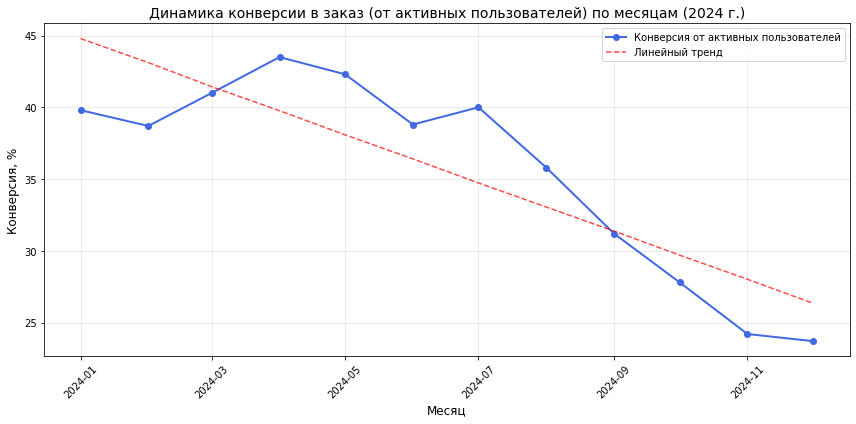

In [76]:
# Визуализация конверсии от активных пользователей

plt.figure(figsize=(12, 6))

# Строим линию конверсии
plt.plot(conversion_by_month['month'], conversion_by_month['conversion_rate'], 
         marker='o', linestyle='-', linewidth=2, markersize=6, 
         color='royalblue', label='Конверсия от активных пользователей')

# Добавляем линию тренда
z = np.polyfit(range(len(conversion_by_month)), conversion_by_month['conversion_rate'], 1)
p = np.poly1d(z)
plt.plot(conversion_by_month['month'], p(range(len(conversion_by_month))), 
         linestyle='--', color='red', linewidth=1.5, alpha=0.7, label='Линейный тренд')

plt.title('Динамика конверсии в заказ (от активных пользователей) по месяцам (2024 г.)', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Конверсия, %', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Классическая конверсия в заказ - это процент пользователей, которые совершили хотя бы одну покупку, от общего числа зарегистрированных пользователей. В отличие от конверсии от активных, этот показатель учитывает всех, кто когда-либо зарегистрировался, включая "мертвые души" (51.1% пользователей, которые не совершили ни одного действия). Эта метрика показывает реальную эффективность маркетингового бюджета: сколько из всех привлеченных пользователей в итоге стали покупателями.

Конверсия = (количество уникальных платящих пользователей, зарегистрировавшихся в месяце X / количество зарегистрированных в месяце X) × 100

In [77]:
# Расчет классической конверсии (от всех зарегистрированных)

# Все зарегистрированные пользователи
all_registered = pa_marketplace_users['user_id'].unique()
n_all_registered = len(all_registered)
print(f"Всего зарегистрированных пользователей: {n_all_registered}")

# Платящие пользователи
paying_users = pa_marketplace_orders['user_id'].unique()
n_paying = len(paying_users)
print(f"Платящих пользователей: {n_paying}")

# Рассчитываем общую классическую конверсию
classic_total_conversion = round(n_paying / n_all_registered * 100, 1)
print(f"\nКлассическая конверсия в заказ (от всех зарегистрированных): {classic_total_conversion}%")

Всего зарегистрированных пользователей: 44151
Платящих пользователей: 8654

Классическая конверсия в заказ (от всех зарегистрированных): 19.6%


In [78]:
# Расчет классической конверсии по месяцам (от зарегистрированных в этом месяце)

# Все зарегистрированные пользователи по месяцам регистрации
registered_by_month = pa_marketplace_users.groupby(pa_marketplace_users['registration_date'].dt.to_period('M'))['user_id'].nunique().reset_index()
registered_by_month.columns = ['month', 'registered_users']

# Для каждого пользователя определяем, покупал ли он когда-либо
users_with_purchase = pa_marketplace_orders[['user_id']].drop_duplicates()
users_with_purchase['has_purchase'] = 1

# Добавляем информацию о регистрации и покупке
users_full = pa_marketplace_users[['user_id', 'registration_date']].copy()
users_full['reg_month'] = users_full['registration_date'].dt.to_period('M')
users_full = users_full.merge(users_with_purchase, on='user_id', how='left')
users_full['has_purchase'] = users_full['has_purchase'].fillna(0)

# Считаем количество платящих по месяцам регистрации
paying_by_reg_month = users_full[users_full['has_purchase'] == 1].groupby('reg_month')['user_id'].nunique().reset_index()
paying_by_reg_month.columns = ['month', 'paying_users']

# Объединяем данные
classic_conversion_by_month = registered_by_month.merge(paying_by_reg_month, on='month', how='left')
classic_conversion_by_month['paying_users'] = classic_conversion_by_month['paying_users'].fillna(0)
classic_conversion_by_month['classic_conversion_rate'] = (classic_conversion_by_month['paying_users'] / classic_conversion_by_month['registered_users'] * 100).round(1)

print("\nКлассическая конверсия по месяцам")
print(classic_conversion_by_month[['month', 'registered_users', 'paying_users', 'classic_conversion_rate']].to_string(index=False))


Классическая конверсия по месяцам
  month  registered_users  paying_users  classic_conversion_rate
2024-01              2985           837                     28.0
2024-02              2711           804                     29.7
2024-03              2965           877                     29.6
2024-04              2905           911                     31.4
2024-05              3066           854                     27.9
2024-06              2810           716                     25.5
2024-07              4388           998                     22.7
2024-08              4431           810                     18.3
2024-09              4466           668                     15.0
2024-10              4440           495                     11.1
2024-11              4383           423                      9.7
2024-12              4601           261                      5.7


In [79]:
# Расчет классической конверсии по месяцам (от зарегистрированных в этом месяце)

# Все зарегистрированные пользователи по месяцам регистрации
registered_by_month = pa_marketplace_users.groupby(pa_marketplace_users['registration_date'].dt.to_period('M'))['user_id'].nunique().reset_index()
registered_by_month.columns = ['month', 'registered_users']

# Для каждого пользователя определяем, покупал ли он когда-либо
users_with_purchase = pa_marketplace_orders[['user_id']].drop_duplicates()
users_with_purchase['has_purchase'] = 1

# Добавляем информацию о регистрации и покупке
users_full = pa_marketplace_users[['user_id', 'registration_date']].copy()
users_full['reg_month'] = users_full['registration_date'].dt.to_period('M')
users_full = users_full.merge(users_with_purchase, on='user_id', how='left')
users_full['has_purchase'] = users_full['has_purchase'].fillna(0)

# Считаем количество платящих по месяцам регистрации
paying_by_reg_month = users_full[users_full['has_purchase'] == 1].groupby('reg_month')['user_id'].nunique().reset_index()
paying_by_reg_month.columns = ['month', 'paying_users']

# Объединяем данные
classic_conversion_by_month = registered_by_month.merge(paying_by_reg_month, on='month', how='left')
classic_conversion_by_month['paying_users'] = classic_conversion_by_month['paying_users'].fillna(0)
classic_conversion_by_month['classic_conversion_rate'] = (classic_conversion_by_month['paying_users'] / classic_conversion_by_month['registered_users'] * 100).round(1)

print("\nКлассическая конверсия по месяцам (от зарегистрированных в этом месяце):")
print(classic_conversion_by_month[['month', 'registered_users', 'paying_users', 'classic_conversion_rate']].to_string(index=False))


Классическая конверсия по месяцам (от зарегистрированных в этом месяце):
  month  registered_users  paying_users  classic_conversion_rate
2024-01              2985           837                     28.0
2024-02              2711           804                     29.7
2024-03              2965           877                     29.6
2024-04              2905           911                     31.4
2024-05              3066           854                     27.9
2024-06              2810           716                     25.5
2024-07              4388           998                     22.7
2024-08              4431           810                     18.3
2024-09              4466           668                     15.0
2024-10              4440           495                     11.1
2024-11              4383           423                      9.7
2024-12              4601           261                      5.7


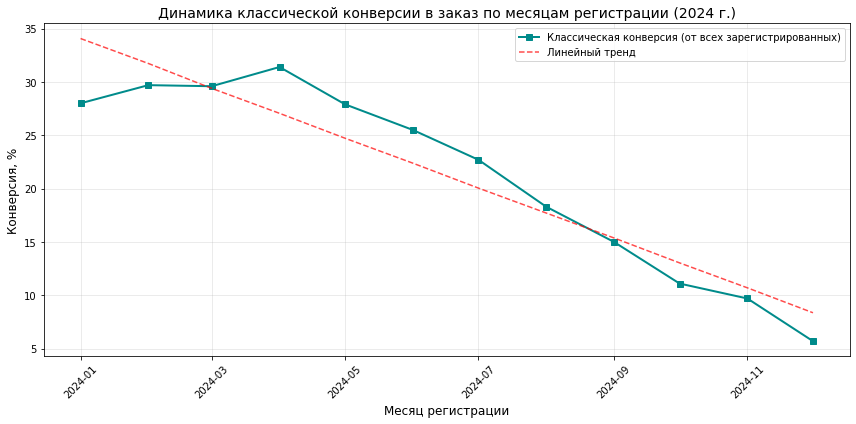

In [80]:
# Визуализация классической конверсии

plt.figure(figsize=(12, 6))

# Преобразуем month из Period в datetime для корректного отображения
classic_conversion_by_month['month_dt'] = classic_conversion_by_month['month'].dt.to_timestamp()

# Строим линию конверсии
plt.plot(classic_conversion_by_month['month_dt'], classic_conversion_by_month['classic_conversion_rate'], 
         marker='s', linestyle='-', linewidth=2, markersize=6, 
         color='darkcyan', label='Классическая конверсия (от всех зарегистрированных)')

# Добавляем линию тренда
z_classic = np.polyfit(range(len(classic_conversion_by_month)), classic_conversion_by_month['classic_conversion_rate'], 1)
p_classic = np.poly1d(z_classic)
plt.plot(classic_conversion_by_month['month_dt'], p_classic(range(len(classic_conversion_by_month))), 
         linestyle='--', color='red', linewidth=1.5, alpha=0.7, label='Линейный тренд')

plt.title('Динамика классической конверсии в заказ по месяцам регистрации (2024 г.)', fontsize=14)
plt.xlabel('Месяц регистрации', fontsize=12)
plt.ylabel('Конверсия, %', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Сравним два этих подхода:

In [81]:
# Сравнение подходов
print(f"\n  Конверсия от активных (общая): {total_conversion}%")
print(f"  Классическая конверсия (общая): {classic_total_conversion}%")
print(f"  Разница: {total_conversion - classic_total_conversion:.1f} п.п.")
print(f"  Классическая конверсия примерно в {round(total_conversion / classic_total_conversion, 1)} раза ниже, чем конверсия от активных")


  Конверсия от активных (общая): 40.1%
  Классическая конверсия (общая): 19.6%
  Разница: 20.5 п.п.
  Классическая конверсия примерно в 2.0 раза ниже, чем конверсия от активных


**Предварительный вывод по конверсии в заказ**

Анализ конверсии в заказ проводился в двух разрезах: конверсия от активных пользователей (тех, кто совершил хотя бы одно событие на платформе) и классической конверсии (от всех зарегистрированных пользователей, включая "мертвые души").

**Конверсия от активных пользователей** составляет 40,1%. Это означает, что из всех пользователей, которые хотя бы начали взаимодействие с продуктом (посмотрели товар, добавили в корзину, искали что-то), 40,1% в итоге совершают покупку. Это достаточно высокий показатель, который говорит о том, что продукт эффективно конвертирует "посетителей" в "покупателей".

**Классическая конверсия** (от всех зарегистрированных) составляет 19,6%, примерно в 2 раза ниже. Разница в 20,5 процентных пунктов - это прямая проекция доли "мертвых душ" (51,1% пользователей, которые зарегистрировались, но не совершили ни одного действия). Эти пользователи никогда не увидят продукт, но при этом "размывают" классическую конверсию, делая её нерепрезентативной для оценки реальной эффективности продукта.

Динамика по месяцам:

Конверсия от активных пользователей демонстрирует четкий тренд на снижение во втором полугодии:
- Пик приходится на апрель 43,5%
- К декабрю показатель падает до 23,7% (снижение почти в 1,8 раза)

Классическая конверсия следует аналогичному тренду, но с еще более резким падением: с 31,4% в апреле до 5,7% в декабре (падение в 5,5 раз).

Для глубинной сегментации и поиска точек роста целесообразно использовать **конверсию от активных пользователей**. Классический подход (от всех зарегистрированных) включает в себя 51,1% "мертвых душ" - пользователей, которые никогда не взаимодействовали с продуктом и, вероятно, уже не вернутся. Анализировать их покупательское поведение бессмысленно, так как его просто нет.

Фокус на конверсии от активных пользователей позволит:
- Оценивать реальную эффективность воронки продаж
- Сравнивать качество разных каналов привлечения (исключая "шум" от неактивированных)
- Понимать, на каком этапе взаимодействия теряются потенциальные покупатели

Инсайт:

Продукт достаточно хорошо конвертирует тех, кто дошел до первого действия (40,1%). Проблема не в том, что пользователи не покупают - проблема в том, что половина из них даже не начинает путь. Основная точка роста - увеличение доли активированных пользователей, а не дальнейшее улучшение конверсии среди уже активных.

### 3. Оценка метрик монетизации и юнит-экономики

Выполните анализ монетизации. Определите, сколько зарабатывает продукт и сколько тратит на привлечение.

Важны как агрегированные метрики (ARPU, AOV), так и показатели эффективности (CAC, ROI, Payback Period).

Сформулируйте первые выводы по результатам анализа метрик. Сделайте это в формате записки для заказчика. Изложите все основные результаты так, чтобы прослеживалась связь между мыслями. Не пишите много — заказчик не будет читать записку полностью, а просто просмотрит.

Напишите выводы в конце блока, чтобы заказчик мог быстро ознакомиться с основными результатами.

Для оценки эффективности маркетинговых инвестиций и понимания экономической модели бизнеса необходимо рассчитать ключевые метрики юнит-экономики. В дополнение к уже полученным показателям мы определим стоимость привлечения клиента (CAC), пожизненную ценность клиента (LTV), окупаемость инвестиций (ROI) и срок окупаемости (Payback Period). Это позволит ответить на главные вопросы: окупаются ли затраты на привлечение, сколько приносит каждый клиент и как быстро бизнес выходит в прибыль.

Уже рассчитанные метрики:
- AOV (средний чек) 14030 руб. за год, с динамикой по месяцам.
- Общая выручка маркетплейса 22 млн руб. за 2024 год, с динамикой по месяцам.
- Количество платящих пользователей 8922 человека.


Для оценки юнит-экономики мы используем классический подход - расчет на платящих пользователях. Именно они приносят выручку и окупают маркетинговые инвестиции.

Для диагностики проблем воронки и понимания, где теряется потенциальная выручка, дополнительно покажем показатели для других срезов (активные пользователи, все зарегистрированные). Это позволит увидеть, на каком этапе происходит основной отток.

**ARPU средний доход на пользователя**

ARPU показывает, сколько денег в среднем приносит один пользователь. Для юнит-экономики ключевой показатель - ARPPU (на платящих). Сопоставление с другими срезами показывает потери на этапах воронки.

In [82]:
# Расчет ARPU для трех срезов (все, активные, платящие)

total_revenue = pa_marketplace_orders['revenue'].sum()

n_all_users = pa_marketplace_users['user_id'].nunique()
n_active_users = pa_marketplace_events['user_id'].nunique()
n_paying_users = pa_marketplace_orders['user_id'].nunique()

arpu_all = total_revenue / n_all_users
arpu_active = total_revenue / n_active_users
arppu = total_revenue / n_paying_users  # ARPPU = ARPU на платящих

print(f"ARPU (средний доход на пользователя):")
print(f"  ARPU_all (на всех зарегистрированных): {arpu_all:.2f} руб.")
print(f"  ARPU_active (на активных): {arpu_active:.2f} руб.")
print(f"  ARPPU (на платящих): {arppu:.2f} руб.")

# Потери на этапах воронки
loss_activation = (1 - n_active_users / n_all_users) * 100
loss_conversion = (1 - n_paying_users / n_active_users) * 100

print(f"\nПотери на этапах воронки:")
print(f"  Потеря между регистрацией и первым действием: {loss_activation:.1f}%")
print(f"  Потеря между первым действием и покупкой: {loss_conversion:.1f}%")

ARPU (средний доход на пользователя):
  ARPU_all (на всех зарегистрированных): 483.54 руб.
  ARPU_active (на активных): 988.28 руб.
  ARPPU (на платящих): 2466.94 руб.

Потери на этапах воронки:
  Потеря между регистрацией и первым действием: 51.1%
  Потеря между первым действием и покупкой: 59.9%


Для сравнения трех показателей ARPU лучше всего подходит столбчатая диаграмма: покажет наглядную разницу

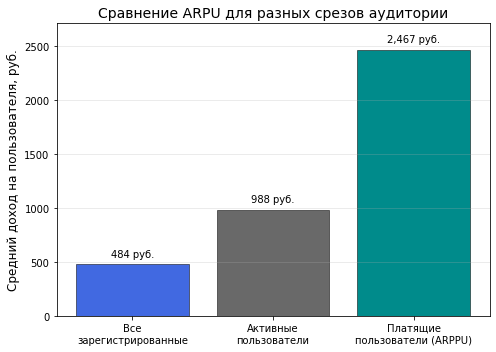

In [83]:
# Визуализация ARPU

arpu_labels = ['Все\nзарегистрированные', 'Активные\nпользователи', 'Платящие\nпользователи (ARPPU)']
arpu_values = [arpu_all, arpu_active, arppu]
arpu_colors = ['royalblue', 'dimgrey', 'darkcyan']

plt.figure(figsize=(7, 5))
bars = plt.bar(arpu_labels, arpu_values, color=arpu_colors, edgecolor='black', linewidth=0.5)

plt.ylim(0, max(arpu_values) * 1.1)

for bar, value in zip(bars, arpu_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(arpu_values) * 0.02,
             f'{value:,.0f} руб.', ha='center', va='bottom', fontsize=10)

plt.title('Сравнение ARPU для разных срезов аудитории', fontsize=14)
plt.ylabel('Средний доход на пользователя, руб.', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Предварительный вывод по ARPU**

- **ARPU_all** (на всех зарегистрированных) составил 483,54 руб. - это общая эффективность всей воронки.
- **ARPU_active** (на активных пользователях) - 988,28 руб. Разрыв между ARPU_all и ARPU_active составляет 504,74 руб. Это прямая потеря от того, что каждый второй зарегистрировавшийся (51,1%) не совершает ни одного действия. Половина потенциальной выручки "умирает" на старте.
- **ARPPU** (на платящих) - 2466,94 руб. Разрыв между ARPU_active и ARPPU составляет 1478,66 руб. Это потеря от того, что из тех, кто дошел до первого действия, 59,9% так и не совершают покупку.

Инсайт:

Выявлено два последовательных провала:

1. Первая точка потери (51,1%): пользователи регистрируются и уходят, не сделав ни одного действия. Это провал онбординга или качества трафика.
2. Вторая точка потери (59,9%): из тех, кто остался, большинство не доходит до покупки. Это провал воронки продаж.

Из 100 зарегистрировавшихся 51 человек уходит сразу, не начав взаимодействие. Из оставшихся 49 только 20 человек доходят до покупки. В итоге у нас 20 покупателей из 100 регистраций.

Точки роста (обе очень важны):
- Увеличить активацию (с 49% до хотя бы 70%), вернуть тех, кто уходит на старте
- Увеличить конверсию активных в покупку (с 40% до хотя бы 60%), дожать тех, кто уже начал взаимодействие

Только работа над обоими этапами одновременно даст значимый рост выручки.

**CAC (Customer Acquisition Cost) стоимость привлечения одного клиента**

CAC стоимость привлечения одного клиента. Рассчитываем классическим способом: бюджет на маркетинг / количество платящих пользователей. Динамика CAC по месяцам показывает, как меняется эффективность привлечения.

In [84]:
# Расчет CAC

# Подготавливаем данные о пользователях
users_cac = pa_marketplace_users[['user_id', 'cohort_month']].copy()
users_cac['cohort_month'] = users_cac['cohort_month'].dt.to_period('M')
users_cac['is_paying'] = users_cac['user_id'].isin(pa_marketplace_orders['user_id'].unique())

# Агрегируем платящих пользователей по месяцам
paying_by_month = users_cac[users_cac['is_paying']].groupby('cohort_month')['user_id'].nunique().reset_index()
paying_by_month.columns = ['cohort_month', 'paying_users']

# Подготавливаем данные о бюджетах
campaign_costs = pa_marketplace_campaign_costs.copy()
campaign_costs['spend_month'] = campaign_costs['spend_month'].dt.to_period('M')
budget_by_month = campaign_costs.groupby('spend_month')['budget'].sum().reset_index()
budget_by_month.columns = ['month', 'total_budget']

# Объединяем и рассчитываем CAC
cac_data = paying_by_month.merge(budget_by_month, left_on='cohort_month', right_on='month', how='inner')
cac_data['cac'] = cac_data['total_budget'] / cac_data['paying_users']

print("CAC по месяцам:")
print(cac_data[['cohort_month', 'total_budget', 'paying_users', 'cac']].round(2).to_string(index=False))

CAC по месяцам:
cohort_month  total_budget  paying_users     cac
     2024-01    1177456.97           837 1406.76
     2024-02    1061385.93           804 1320.13
     2024-03    1167680.37           877 1331.45
     2024-04    1147739.92           911 1259.87
     2024-05    1225322.28           854 1434.80
     2024-06    1130439.77           716 1578.83
     2024-07    1776446.60           998 1780.01
     2024-08    1811677.75           810 2236.64
     2024-09    1820718.83           668 2725.63
     2024-10    1810802.57           495 3658.19
     2024-11    1773970.36           423 4193.78
     2024-12    1858569.86           261 7120.96


In [85]:
# Среднее значение
avg_cac = cac_data['cac'].mean()
print(f"Средний CAC: {avg_cac:.2f} руб.")

Средний CAC: 2503.92 руб.


Для визуализации CAC лучше всего подходит линейный график динамики по месяцам. Это позволит увидеть тренд: растет стоимость привлечения или снижается, оценить масштабируемость бизнеса (если CAC растет, то бизнес становится менее эффективным).

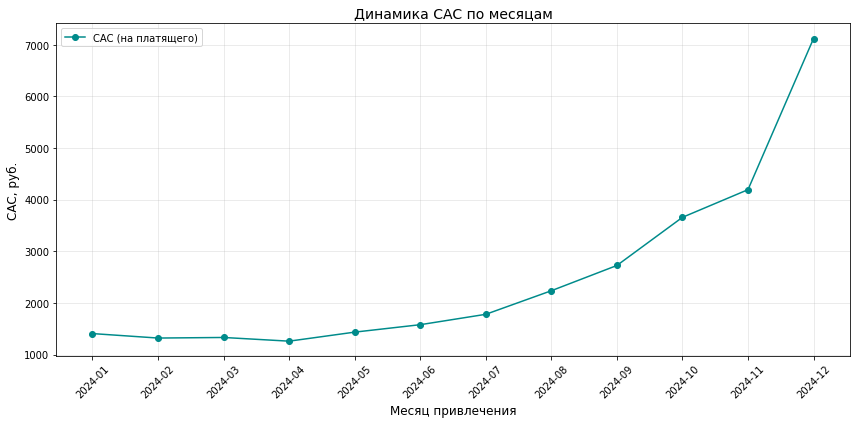

In [86]:
# Визуализация CAC

plt.figure(figsize=(12, 6))

months_str = cac_data['cohort_month'].astype(str)

plt.plot(months_str, cac_data['cac'], 
         marker='o', linestyle='-', linewidth=1.5, markersize=6, 
         color='darkcyan', label='CAC (на платящего)')

plt.title('Динамика CAC по месяцам', fontsize=14)
plt.xlabel('Месяц привлечения', fontsize=12)
plt.ylabel('CAC, руб.', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Предварительный вывод по CAC**

CAC (стоимость привлечения покупателя) в среднем составил 2504 руб.

Показатель резко вырос за год - это тревожный сигнал: с 1407 руб. в январе до 7121 руб. в декабре (рост в 5 раз).

При среднем доходе от платящего пользователя (ARPPU) 2467 руб. это означает, что если в январе привлечение было эффективным (CAC < ARPPU), то к декабрю оно стало убыточным (CAC > ARPPU). Бизнес тратит на привлечение больше, чем зарабатывает с клиента.

Масштабирование происходит за счет ухудшения эффективности. Крайне важно остановить рост CAC, иначе бизнес перестанет быть прибыльным даже при идеальной активации и конверсии.

**LTV (Lifetime Value) пожизненная ценность клиента**

LTV (Lifetime Value) - это суммарный доход, который приносит один клиент за всё время взаимодействия с продуктом. Для корректной оценки юнит-экономики мы рассчитываем LTV на платящих пользователях, так как именно они генерируют выручку.

При сравнении LTV с CAC важно использовать сопоставимые данные. CAC считается по когортам (пользователи, привлечённые в определённом месяце), поэтому для корректного сравнения LTV также следует рассчитывать накопленным итогом для каждой когорты за одинаковый период времени.

Однако для верхнеуровневой оценки мы сначала посчитаем простой LTV как отношение общей выручки к общему количеству платящих пользователей. Это даст общее представление о ценности клиента.

- **LTV_paying** = Общая выручка / Количество платящих пользователей
- **LTV_active** = Общая выручка / Количество активных пользователей *(диагностика)*
- **LTV_all** = Общая выручка / Количество всех зарегистрированных пользователей *(диагностика)*

Для более точного анализа также рассчитаем накопительный LTV по когортам, который показывает, как меняется ценность клиента с течением времени после первой покупки. Это позволяет:

- Оценить, через сколько месяцев клиент окупает CAC
- Сравнить поведение разных когорт между собой
- Прогнозировать долгосрочную ценность новых клиентов.

In [87]:
# Расчет LTV для трех срезов аудитории

total_revenue = pa_marketplace_orders['revenue'].sum()

n_all_users = pa_marketplace_users['user_id'].nunique()
n_active_users = pa_marketplace_events['user_id'].nunique()
n_paying_users = pa_marketplace_orders['user_id'].nunique()

ltv_paying = total_revenue / n_paying_users
ltv_active = total_revenue / n_active_users
ltv_all = total_revenue / n_all_users

print(f"LTV (пожизненная ценность клиента):")
print(f"  LTV_all (на всех зарегистрированных): {ltv_all:.2f} руб. (диагностика)")
print(f"  LTV_active (на активных): {ltv_active:.2f} руб. (диагностика)")
print(f"  LTV_paying (на платящих): {ltv_paying:.2f} руб.")

LTV (пожизненная ценность клиента):
  LTV_all (на всех зарегистрированных): 483.54 руб. (диагностика)
  LTV_active (на активных): 988.28 руб. (диагностика)
  LTV_paying (на платящих): 2466.94 руб.


In [88]:
# Сравнение с CAC
print(f"Сравнение LTV_paying и среднего CAC:")
print(f"  LTV_paying / CAC = {ltv_paying / avg_cac:.2f}")

if ltv_paying / avg_cac > 1:
    print(f"  Платящие пользователи в среднем окупаются (LTV > CAC)")
else:
    print(f"  Платящие пользователи в среднем не окупаются (LTV < CAC)")

Сравнение LTV_paying и среднего CAC:
  LTV_paying / CAC = 0.99
  Платящие пользователи в среднем не окупаются (LTV < CAC)


Визуализируем разницу между срезами наглядно столбчатой диаграммой

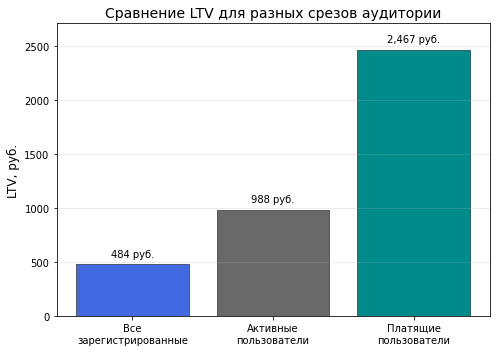

In [89]:
# Сравнение LTV для разных срезов аудитории

ltv_labels = ['Все\nзарегистрированные', 'Активные\nпользователи', 'Платящие\nпользователи']
ltv_values = [ltv_all, ltv_active, ltv_paying]
ltv_colors = ['royalblue', 'dimgrey', 'darkcyan']

plt.figure(figsize=(7, 5))
bars = plt.bar(ltv_labels, ltv_values, color=ltv_colors, edgecolor='black', linewidth=0.5)

plt.ylim(0, max(ltv_values) * 1.1)

for bar, value in zip(bars, ltv_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(ltv_values) * 0.02,
             f'{value:,.0f} руб.', ha='center', va='bottom', fontsize=10)

plt.title('Сравнение LTV для разных срезов аудитории', fontsize=14)
plt.ylabel('LTV, руб.', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Посмотрим еще накопительный LTV платящих пользователей по когортам. 

Накопительный LTV по когортам показывает, как меняется суммарный доход от клиентов одной когорты с течением времени. 

Для этого:
- Для каждого платящего пользователя определяется месяц его первой покупки (когорта)
- Для каждой когорты считается, сколько выручки принесли пользователи в 1-й, 2-й, 3-й и т.д. месяцы после первой покупки
- Выручка суммируется накопленным итогом и делится на количество новых платящих пользователей в когорте

Это позволяет:
- Оценить, через сколько месяцев клиент начинает приносить чистую прибыль (когда накопленный LTV превышает CAC)
- Сравнить долгосрочную ценность клиентов из разных когорт
- Выявить тренды: становятся ли клиенты "лучше" или "хуже" со временем Его лучше всего визуализировать тепловой картой (heatmap). Это позволяет увидеть, как быстро окупается каждая когорта и сравнить поведение разных когорт между собой.

In [90]:
# Расчет накопительного LTV по когортам

# Определяем месяц первой покупки
first_purchase = pa_marketplace_orders.groupby('user_id')['order_date'].min().reset_index()
first_purchase.columns = ['user_id', 'first_order_date']
first_purchase['cohort_month'] = first_purchase['first_order_date'].dt.to_period('M')

# Количество новых платящих по месяцам
new_paying_by_month = first_purchase.groupby('cohort_month')['user_id'].nunique().reset_index()
new_paying_by_month.columns = ['cohort_month', 'new_paying_users']

# Добавляем информацию о когорте к заказам
cohort_revenue = pa_marketplace_orders.merge(
    first_purchase[['user_id', 'first_order_date', 'cohort_month']], 
    on='user_id', 
    how='left'
)

# Считаем месяцы после первой покупки
cohort_revenue['days_after_first'] = (cohort_revenue['order_date'] - cohort_revenue['first_order_date']).dt.days
cohort_revenue['month_after'] = (cohort_revenue['days_after_first'] / 30).astype(int) + 1

# Суммируем выручку по когортам и месяцам
monthly_ltv = cohort_revenue.groupby(['cohort_month', 'month_after'])['revenue'].sum().reset_index()
monthly_ltv = monthly_ltv.merge(new_paying_by_month, on='cohort_month')
monthly_ltv['cumulative_ltv'] = monthly_ltv.groupby('cohort_month')['revenue'].cumsum() / monthly_ltv['new_paying_users']

# Сводная таблица для тепловой карты
ltv_pivot = monthly_ltv.pivot(index='cohort_month', 
                               columns='month_after', 
                               values='cumulative_ltv')
ltv_pivot

month_after,1,2,3,4,5,6,7,8,9
cohort_month,,,,,,,,,
2024-01,1972.894809,2437.133293,2653.316000,2799.952006,2882.018639,2902.469966,NaN,2908.611567,NaN
2024-02,1869.408496,2284.018844,2474.214356,2579.080270,2609.338880,2624.020455,2629.899559,NaN,NaN
2024-03,1865.354789,2395.319053,2660.329569,2826.913760,2903.329674,2955.468035,2969.040411,2973.834555,2977.502156
2024-04,1841.101240,2207.399156,2398.825570,2507.802752,2586.030468,2650.644125,2667.798010,2669.854890,2673.396191
2024-05,1874.450001,2371.807017,2584.280490,2683.915519,2708.503840,2731.889718,2738.150006,2743.370906,NaN
2024-06,1726.352406,2099.953532,2236.576547,2310.901217,2324.945254,2333.376335,2335.570463,NaN,NaN
2024-07,1916.172781,2349.818830,2568.808014,2650.343695,2684.727559,2692.092717,NaN,NaN,NaN
2024-08,1861.287095,2203.120848,2345.419730,2445.071681,2456.694934,NaN,NaN,NaN,NaN
2024-09,1616.105550,1972.494230,2059.342275,2105.895322,NaN,NaN,NaN,NaN,NaN


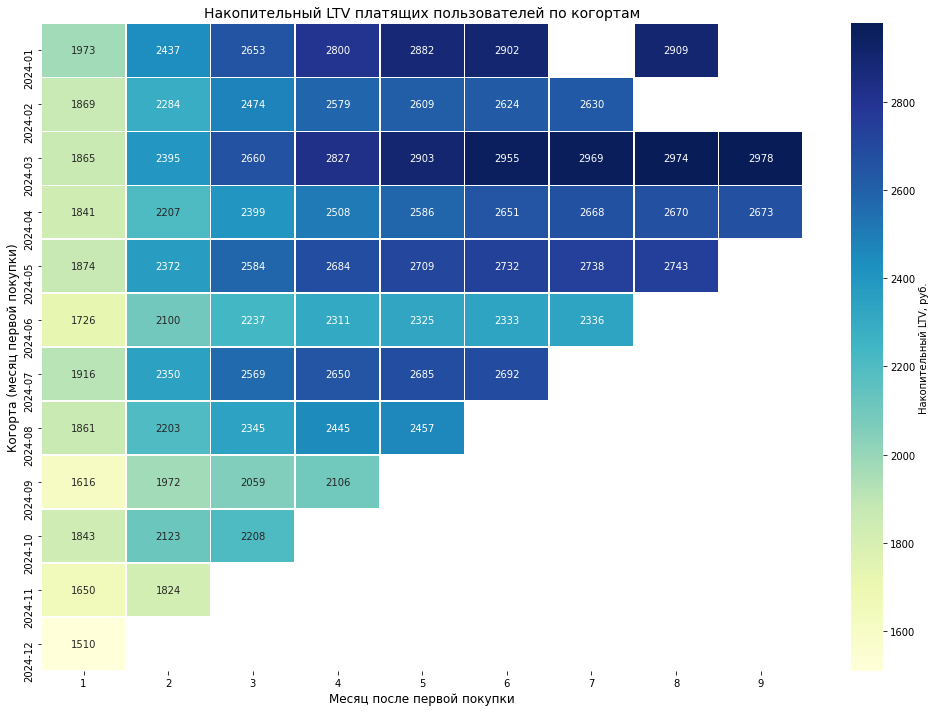

In [91]:
# Тепловая карта накопительного LTV

plt.figure(figsize=(14, 10))

sns.heatmap(ltv_pivot, 
            annot=True, 
            fmt='.0f', 
            cmap='YlGnBu', 
            linewidths=0.5,
            cbar_kws={'label': 'Накопительный LTV, руб.'})

plt.title('Накопительный LTV платящих пользователей по когортам', fontsize=14)
plt.xlabel('Месяц после первой покупки', fontsize=12)
plt.ylabel('Когорта (месяц первой покупки)', fontsize=12)
plt.tight_layout()
plt.show()

**Предварительный вывод по LTV**

Базовый LTV (средняя пожизненная ценность):
- LTV_paying (на платящего пользователя): 2 467 руб.
- LTV_active (на активного пользователя): 988 руб. (для диагностики)
- LTV_all (на всех зарегистрированных): 484 руб. (для диагностики)

Сравнение с CAC:
- Средний CAC за год: 2504 руб.
- LTV_paying / CAC = 0,99 (< 1)

Платящие пользователи в среднем НЕ окупаются (LTV < CAC). Каждый привлечённый клиент в среднем приносит на 37 рублей меньше, чем стоило его привлечение.

Что видим по тепловой карте (накопительный LTV по когортам):
- Ранние когорты (январь-май) достигают LTV около 2500–2900 руб. к 3-5 месяцу
- Когорты с июня по декабрь демонстрируют более низкий накопленный LTV
- Когорта сентября: LTV около 2100 руб. на 4-м месяце (ниже среднего CAC)
- Когорта декабря: LTV всего около 1500 руб. на 1-м месяце

Инсайты:

1. Поздние когорты приносят меньше выручки, чем ранние. Если в январе LTV достигал около 2900 руб., то в сентябре - только около 2100 руб. Это подтверждает ухудшение качества привлекаемой аудитории.

2. Бизнес находится на грани окупаемости. LTV_paying (2467 руб.) практически равен среднему CAC (2504 руб.). Любое дальнейшее ухудшение сделает модель убыточной.

3. Необходимо увеличивать LTV через:
   - Повышение частоты повторных покупок (программы лояльности, email-рассылки)
   - Увеличение среднего чека (кросс-продажи, апсейлы)
   - Улучшение удержания (удлинение "жизни" клиента).

**ROI и Payback Period**

ROI (Return on Investment) - окупаемость инвестиций в процентах, показывает, сколько рублей прибыли приносит каждый вложенный рубль. Если ROI > 0, то инвестиции окупаются, если ROI < 0, то бизнес работает в убыток.

ROI = (LTV - CAC) / CAC × 100%

Payback Period - срок окупаемости, показывает, через сколько месяцев после привлечения клиент начинает приносить чистую прибыль (когда накопленный LTV превышает CAC). Это важный показатель для оценки эффективности маркетинговых бюджетов и управления денежными потоками.

Эти метрики позволяют:
- Оценить, окупается ли текущая модель привлечения
- Понять, как быстро возвращаются вложенные средства
- Сравнить эффективность разных когорт (более быстрая окупаемость — признак качественной аудитории).

In [92]:
# ROI на основе средних значений
roi = (ltv_paying - avg_cac) / avg_cac * 100

print(f"ROI (окупаемость инвестиций): {roi:.1f}%")

if roi > 0:
    print(f"Прибыль {roi:.1f} копеек с каждого вложенного рубля")
else:
    print(f"Убыток {abs(roi):.1f} копеек с каждого вложенного рубля")

ROI (окупаемость инвестиций): -1.5%
Убыток 1.5 копеек с каждого вложенного рубля


Для корректного сравнения по когортам нужно использовать накопленный LTV каждой когорты.
Но сначала посмотрим с использованием среднего LTV (для демонстрации динамики CAC)

In [93]:
# ROI по месяцам (для анализа динамики)
cac_data['ltv_paying'] = ltv_paying  # используем общий LTV (упрощение)
cac_data['roi'] = (cac_data['ltv_paying'] - cac_data['cac']) / cac_data['cac'] * 100

print("\nROI по месяцам (упрощенный расчет):")
print(cac_data[['cohort_month', 'cac', 'roi']].round(2).to_string(index=False))


ROI по месяцам (упрощенный расчет):
cohort_month     cac    roi
     2024-01 1406.76  75.36
     2024-02 1320.13  86.87
     2024-03 1331.45  85.28
     2024-04 1259.87  95.81
     2024-05 1434.80  71.94
     2024-06 1578.83  56.25
     2024-07 1780.01  38.59
     2024-08 2236.64  10.30
     2024-09 2725.63  -9.49
     2024-10 3658.19 -32.56
     2024-11 4193.78 -41.18
     2024-12 7120.96 -65.36


In [94]:
print(f"\nPayback Period (месяц, когда накопленный LTV превысил CAC = {avg_cac:.0f} руб.):")
print("Анализ по тепловой карте накопительного LTV:")

for cohort in ltv_pivot.index:
    cohort_data = ltv_pivot.loc[cohort].dropna()
    payback_month = None
    for month, ltv_value in cohort_data.items():
        if ltv_value >= avg_cac:
            payback_month = month
            break
    if payback_month:
        print(f"  Когорта {cohort}: окупается на {payback_month}-м месяце (LTV = {ltv_value:.0f} руб.)")
    else:
        print(f"  Когорта {cohort}: не окупилась за доступный период")


Payback Period (месяц, когда накопленный LTV превысил CAC = 2504 руб.):
Анализ по тепловой карте накопительного LTV:
  Когорта 2024-01: окупается на 3-м месяце (LTV = 2653 руб.)
  Когорта 2024-02: окупается на 4-м месяце (LTV = 2579 руб.)
  Когорта 2024-03: окупается на 3-м месяце (LTV = 2660 руб.)
  Когорта 2024-04: окупается на 4-м месяце (LTV = 2508 руб.)
  Когорта 2024-05: окупается на 3-м месяце (LTV = 2584 руб.)
  Когорта 2024-06: не окупилась за доступный период
  Когорта 2024-07: окупается на 3-м месяце (LTV = 2569 руб.)
  Когорта 2024-08: не окупилась за доступный период
  Когорта 2024-09: не окупилась за доступный период
  Когорта 2024-10: не окупилась за доступный период
  Когорта 2024-11: не окупилась за доступный период
  Когорта 2024-12: не окупилась за доступный период


Визуализируем ROI линейным графиком динамики по месяцам, он показывает, как меняется окупаемость инвестиций во времени. Падающий тренд ROI будет тревожным сигналом.

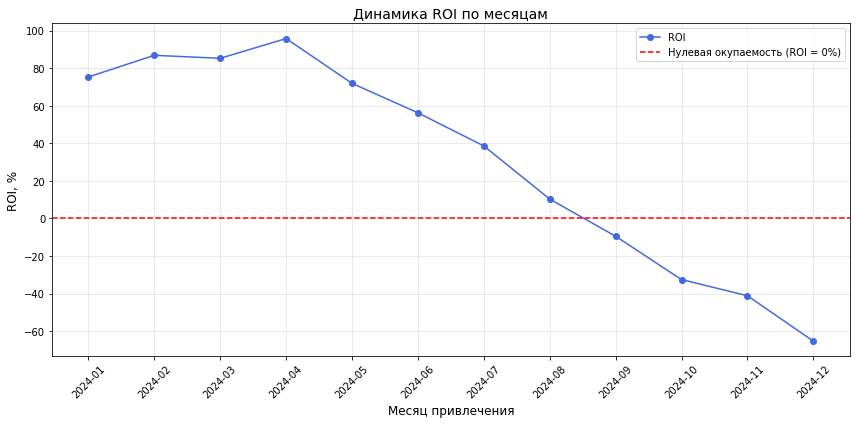

In [95]:
# Динамика ROI по месяцам

plt.figure(figsize=(12, 6))

months_str = cac_data['cohort_month'].astype(str)

plt.plot(months_str, cac_data['roi'], 
         marker='o', linestyle='-', linewidth=1.5, markersize=6, 
         color='royalblue', label='ROI')

# Добавляем линию нулевой окупаемости
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Нулевая окупаемость (ROI = 0%)')

plt.title('Динамика ROI по месяцам', fontsize=14)
plt.xlabel('Месяц привлечения', fontsize=12)
plt.ylabel('ROI, %', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Предварительный вывод по ROI и Payback Period**
ROI (окупаемость инвестиций) в среднем за год составил -1,5%. Это означает, что каждый вложенный в привлечение рубль приносит убыток 1,5 копейки. Бизнес находится на границе окупаемости.

Динамика ROI по месяцам показывает резкое ухудшение:
- Январь-апрель: ROI положительный, достигает пика +95,8% в апреле. Привлечение эффективно.
- Май-август: ROI снижается с +71,9% до +10,3%. Эффективность падает.
- Сентябрь-декабрь: ROI становится отрицательным, достигая -65,4% в декабре. Каждый рубль, вложенный в привлечение в декабре, приносит убыток 65 копеек.

Payback Period (срок окупаемости):
- Ранние когорты (январь, март, май, июль): окупаются на 3-м месяце
- Когорты февраля и апреля: окупаются на 4-м месяце
- Когорты с июня по декабрь: не окупаются за доступный период наблюдения

Инсайты:
- Бизнес на грани. ROI близок к нулю, любое ухудшение CAC или LTV делает модель убыточной.
- Тренд катастрофический. Если в начале года ROI был положительным (до 96%), то к концу года он упал до -65%. При сохранении тренда бизнес станет глубоко убыточным.
- Качество когорт падает. Ранние когорты окупались за 3-4 месяца, поздние (с июня) не окупаются вовсе. Это подтверждает, что привлекаемая аудитория становится менее качественной.

Точки роста (в порядке приоритета):
- Остановить рост CAC. Без этого любые улучшения воронки не спасут ситуацию
- Увеличить LTV_paying через повышение частоты покупок или среднего чека
- Улучшить активацию и конверсию, чтобы больше пользователей доходило до покупки

## Выводы по этапам 2 и 3


Представьте ключевые выводы в текстовом виде здесь или приложите ссылку на документ с презентацией.

Не забудьте предоставить доступ на просмотр и комментирование документа.

<h1 style="font-size: 24px;">Итоговый вывод по этапам 2 и 3: состояние бизнеса и ключевые проблемы</h1>

**Аудитория: рост есть, но качество падает**

Аудитория маркетплейса за 2024 год выросла в 3,4 раза: MAU увеличился с 1102 в январе до пиковых 3768 в августе. Однако коэффициент липкости (DAU/MAU) снизился с 11,2% в апреле до 7,9% в декабре при среднем значении 9,8%. Это тревожный сигнал: пользователи приходят реже, продукт не становится для них привычкой, а маркетинг привлекает всё больше "одноразовой" аудитории.

**Выручка: уверенный рост в первом полугодии и падение во втором**

Общая выручка маркетплейса за 2024 год составила 21,35 млн рублей. Первое полугодие показало взрывной рост: с 623 тыс. рублей в январе до пиковых 2,42 млн рублей в мае, с максимальными темпами в феврале (+99,5%) и марте (+51,4%). Однако начиная с июня наблюдается устойчивое снижение: падение на 15,2% в июне, затем на 21,6% в сентябре, и продолжение нисходящего тренда до декабря (-9,0%). К концу года выручка составила 1,29 млн рублей - это на 47% ниже майского пика. Среднемесячная выручка 1,78 млн рублей.

**Проблема 1: 51,1% "мертвых душ"**

Из 44151 зарегистрировавшихся пользователей 22549 человек (51,1%) не совершили ни одного действия после регистрации. Это зря потраченный маркетинговый бюджет. Если бы активация выросла с 49% до хотя бы 70%, выручка выросла бы на 40% без увеличения бюджета.

Классическая конверсия (от всех зарегистрированных) составляет 19,6%, а конверсия от активных пользователей 40,1%. Разница в 2 раза - это прямое следствие "мертвых душ". Проблема не в том, что продукт плохо продаёт (среди активных конверсия высокая), а в том, что половина аудитории даже не начинает путь.

**Проблема 2: CAC растёт в 5 раз, бизнес на грани убыточности**

CAC (стоимость привлечения покупателя) вырос с 1407 рублей в январе до 7121 рубля в декабре (рост в 5 раз). При среднем доходе от платящего пользователя (ARPPU) 2467 рублей это означает:

- в январе привлечение было эффективным (CAC < ARPPU)
- с июня CAC начинает превышать ARPPU
- к декабрю бизнес тратит на привлечение в 2,9 раза больше, чем зарабатывает с клиента

ROI за год составил -1,5% (убыток 1,5 копейки с каждого рубля). Динамика катастрофическая: с +95,8% в апреле до -65,4% в декабре. Масштабирование происходит за счёт ухудшения эффективности.

Payback Period (срок окупаемости):
- ранние когорты (январь, март, май, июль) окупались на 3-м месяце
- когорты февраля и апреля на 4-м месяце
- когорты с июня по декабрь не окупаются за доступный период

**Проблема 3: удержание падает, долгосрочная лояльность отсутствует**

На 5-й неделе после регистрации возвращается 9–15% пользователей (в зависимости от когорты), и тренд падающий: когорта января 13,9%, когорта ноября 7,4% (падение в 2 раза).

Долгосрочное удержание критически низкое:
- на 1-й месяц: 25–40%
- на 3-й месяц: 6–9%
- на 6-й месяц: менее 1%

К 6-му месяцу с продуктом остаётся менее 1% пользователей. Бизнес не формирует лояльную аудиторию и вынужден постоянно привлекать новых.

**Точки роста (в порядке приоритета)**

1. Остановить рост CAC. Проанализировать эффективность каналов привлечения: какие каналы дают качественную аудиторию, а какие "сгорели". Без этого любые улучшения воронки не спасут ситуацию.

2. Увеличить активацию. Сейчас 51% пользователей умирают на старте. Триггерные письма, push-уведомления, промокод на первый заказ сразу после регистрации могут поднять активацию до 70% и дать +40% выручки без увеличения бюджета.

3. Увеличить LTV платящих. Через программы лояльности, персонализированные рекомендации, email-рассылки. Даже небольшое увеличение частоты покупок или среднего чека (AOV стабилен на уровне 14 000 рублей) даст рост выручки.

4. Улучшить долгосрочное удержание. Внедрить механики для повторных покупок: реферальные программы, кэшбэк, сезонные акции. Без этого бизнес не сможет окупать растущий CAC.

**Что проверить дополнительно**

- Каналы привлечения: какие каналы дают высокий CAC и низкую активацию? Возможно, некоторые каналы нужно отключать или пересматривать таргетинг.
- Воронка по каналам: отличается ли конверсия от активных для разных каналов?
- Платёжная система: нет ли технических сбоев на этапе оплаты? Почему 35% завершивших оформление не доходят до покупки?
- Изменения в продукте во втором полугодии: были ли неудачные обновления, которые могли повлиять на удержание и конверсию?

**Итоговый вывод**

Бизнес находится на перепутье. Аудитория растёт, но качество падает. Привлечение становится убыточным. При этом продукт хорошо продаёт тем, кто до него дошёл (40% активных покупают). **Необходимо остановить рост CAC и увеличить активацию.** Без этого масштабирование приведёт к убыткам.

## 4. Поиск инсайтов, точек роста и сегментация


После того как вы провели верхнеуровневую оценку данных, самое время переходить от общей картины к точечным наблюдениям. Посмотрите вглубь данных: по каналам,
сегментам пользователей, категориям товаров, регионам, типам устройств. Ищите
закономерности, различия, аномалии.

Цель — сформировать обоснованные гипотезы:

* какие сегменты работают лучше остальных
* какие сегменты работают хуже остальных
* на каких этапах воронки теряются пользователи
* какие группы можно или нужно масштабировать
* куда стоит инвестировать больше внимания или ресурсов

По итогам анализа также:

* сформулируйте в виде аналитической записки выводы
* сформулируйте несколько гипотез, которые помогут развить продукт. Например: «Если предлагать клиентам на iOS персонализированные скидки, то они станут чаще конвертировать в продукт». При формулировании гипотез опишите, на что вы опираетесь при её формировании. Например, на динамику метрики или на взаимосвязь метрик.

Напишите выводы в конце блока, чтобы заказчик мог быстро ознакомиться с основными результатами.
Отправьте работу на проверку ревьюеру. Ревьюер будет проверять корректность выводов и гипотез, а не сам код расчета, поэтому проверьте, что у вас есть выводы по каждому из блоков в предназначенном для этого месте.
После завершения ревью вы получите от ревьюера новые вводные и задачу от бизнеса.


**Поиск инсайтов, точек роста и сегментация**

На предыдущих этапах мы выполнили верхнеуровневую оценку состояния маркетплейса и выявили ключевые проблемы:

- 51,1% "мертвых душ". Пользователи регистрируются, но не совершают ни одного действия
- Падение выручки во втором полугодии на 47% от майского пика
- Рост CAC в 5 раз, с 1407 до 7121 рубля
- Отрицательный ROI (-1,5%) и падение качества поздних когорт
- Провал на финальном шаге воронки. 35% пользователей отваливаются после завершения оформления

Теперь наша задача - заглянуть вглубь данных и понять, какие сегменты аудитории работают лучше или хуже, на каких этапах воронки происходят основные потери, и куда стоит инвестировать усилия для роста.

**Цели этапа 4:**
1. Детально проанализировать продуктовую воронку для выявления проблемных этапов
2. Провести сегментный анализ (по каналам привлечения, регионам, типам устройств, категориям товаров)
3. Сформулировать обоснованные гипотезы для улучшения ключевых метрик

**План анализа**

1. Детальный анализ продуктовой воронки. Построить классическую и step-by-step воронку для всех пользователей и для активных. Выявить этапы с наибольшей потерей пользователей.
2. Сегментация по каналам привлечения (acq_channel). Сравнить конверсию в покупку и удержание по разным каналам. Выявить самые эффективные и самые убыточные каналы.
3. Сегментация по регионам. Сравнить поведение пользователей из разных регионов, найти регионы с аномально высокой/низкой конверсией.
4. Сегментация по типам устройств (device). Сравнить воронку для mobile, desktop, tablet и выявить, на каком этапе происходят основные потери.
5. Сегментация по категориям товаров. Определить, какие категории приносят основную выручку, найти категории с высоким и низким средним чеком.
6. Формулирование гипотез и точек роста. На основе инсайтов сформулировать проверяемые гипотезы и предложить конкретные действия для улучшения метрик.

**Продуктовая воронка**

После того как мы выяснили, что 51.1% зарегистрированных пользователей не совершают ни одного действия ("мертвые души"), возникает закономерный вопрос: как правильно анализировать воронку продаж?

В аналитике маркетплейсов используются два подхода, каждый из которых отвечает на свой вопрос:
- Воронка по всем зарегистрированным пользователям показывает реальную эффективность маркетингового бюджета. Она включает всех, на кого тратились деньги, и демонстрирует, сколько из привлеченных пользователей в итоге дошли до покупки. Это честная метрика для оценки окупаемости инвестиций.
- Воронка по активным пользователям (тех, кто совершил хотя бы одно событие) показывает качество продукта и пользовательского опыта. Она исключает "мертвые души" и позволяет понять, на каком этапе "живые" пользователи отваливаются из-за проблем с интерфейсом, ценой или процессом оплаты.

Сопоставление этих двух воронок дает полную картину, где теряется основная выручка: на этапе активации (когда пользователь даже не начал путь) или на этапах внутри продукта.

Воронка по всем зарегистрированным пользователям

In [96]:
# Построение воронки для всех зарегистрированных пользователей

# Получаем список всех зарегистрированных пользователей
all_users_list = pa_marketplace_users['user_id'].unique()
print(f"Всех зарегистрированных пользователей: {len(all_users_list)}")

# Считаем количество пользователей на каждом этапе
step1_registration = len(all_users_list)
users_product_view = pa_marketplace_events[pa_marketplace_events['event_type'] == 'product_view']['user_id'].nunique()
users_add_to_cart = pa_marketplace_events[pa_marketplace_events['event_type'] == 'add_to_cart']['user_id'].nunique()
users_checkout_start = pa_marketplace_events[pa_marketplace_events['event_type'] == 'checkout_start']['user_id'].nunique()
users_checkout_complete = pa_marketplace_events[pa_marketplace_events['event_type'] == 'checkout_complete']['user_id'].nunique()
users_purchase = pa_marketplace_orders['user_id'].nunique()

# Создаем таблицу для воронки
funnel_data_all = pd.DataFrame({
    'Этап': ['1. Регистрация', 
             '2. Просмотр товара', 
             '3. Добавление в корзину', 
             '4. Начало оформления', 
             '5. Завершение оформления', 
             '6. Покупка'],
    'Пользователи': [step1_registration, users_product_view, users_add_to_cart, 
                     users_checkout_start, users_checkout_complete, users_purchase]
})

# Рассчитываем конверсию
funnel_data_all['Конверсия от предыдущего, %'] = (
    funnel_data_all['Пользователи'] / funnel_data_all['Пользователи'].shift(1) * 100
).round(1)
funnel_data_all['Конверсия от первого этапа, %'] = (
    funnel_data_all['Пользователи'] / funnel_data_all['Пользователи'].iloc[0] * 100
).round(1)

# Заменяем NaN на '-'
funnel_data_all['Конверсия от предыдущего, %'] = funnel_data_all['Конверсия от предыдущего, %'].fillna('-')
funnel_data_all['Конверсия от первого этапа, %'] = funnel_data_all['Конверсия от первого этапа, %'].fillna('-')

print("Воронка всех зарегистрированных пользователей:")
print(funnel_data_all.to_string(index=False))

Всех зарегистрированных пользователей: 44151
Воронка всех зарегистрированных пользователей:
                    Этап  Пользователи Конверсия от предыдущего, %  Конверсия от первого этапа, %
          1. Регистрация         44151                           -                          100.0
      2. Просмотр товара         21533                        48.8                           48.8
 3. Добавление в корзину         19887                        92.4                           45.0
    4. Начало оформления         16293                        81.9                           36.9
5. Завершение оформления         13486                        82.8                           30.5
              6. Покупка          8654                        64.2                           19.6


Визуализируем

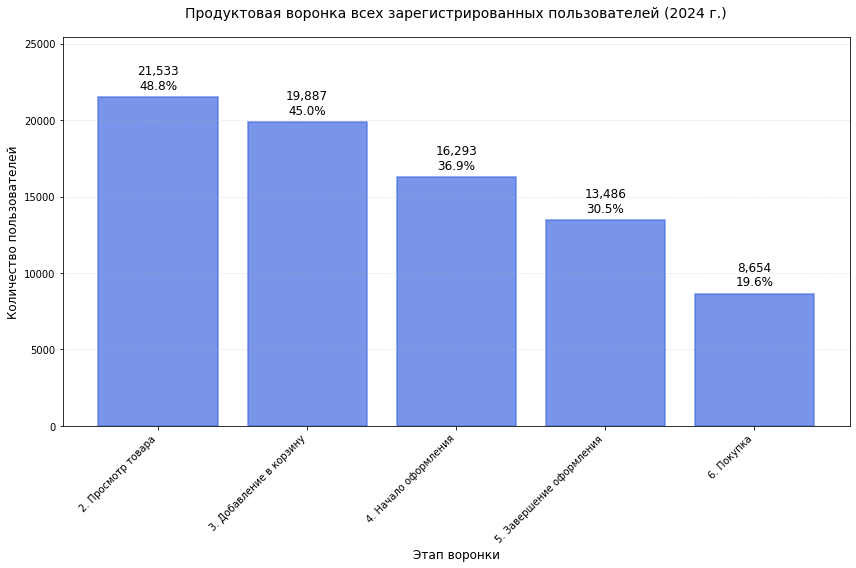

In [97]:
# Визуализация воронки для всех пользователей

# Исключаем первый этап (регистрацию) для наглядности
funnel_data_all_filtered = funnel_data_all.iloc[1:].copy()

plt.figure(figsize=(12, 8))

bars = plt.bar(funnel_data_all_filtered['Этап'], funnel_data_all_filtered['Пользователи'], 
               color='royalblue', alpha=0.7, edgecolor='royalblue', linewidth=1.5)

conversion_rates = funnel_data_all_filtered['Конверсия от первого этапа, %']
max_value = funnel_data_all_filtered['Пользователи'].max()
y_offset_top = max_value * 0.06
spacing = max_value * 0.045

for bar, value, conv in zip(bars, funnel_data_all_filtered['Пользователи'], conversion_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset_top,
             f'{value:,}', ha='center', va='bottom', fontsize=12)
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset_top - spacing,
             f'{conv}%', ha='center', va='bottom', fontsize=12)

plt.ylim(0, max_value + y_offset_top + max_value * 0.12)
plt.title('Продуктовая воронка всех зарегистрированных пользователей (2024 г.)', fontsize=14, pad=20)
plt.xlabel('Этап воронки', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Для более глубокого анализа добавим step-by-step воронку (для всех пользователей) с последовательными шагами. Конверсию будем считать от предыдущего шага.

In [98]:
# Step-by-step воронка для всех зарегистрированных пользователей

# Берем всех пользователей
all_events = pa_marketplace_events.copy()

# Создаем словарь соответствия событий и шагов
event_to_step = {
    'product_view': 1,
    'add_to_cart': 2,
    'checkout_start': 3,
    'checkout_complete': 4
}

# Для каждого пользователя находим максимальный шаг из событий
user_max_step_all = all_events[all_events['event_type'].isin(event_to_step.keys())].groupby('user_id')['event_type'].agg(
    lambda x: max([event_to_step[e] for e in x if e in event_to_step])
).reset_index()
user_max_step_all.columns = ['user_id', 'max_step']

# Добавляем информацию о покупке
user_max_step_all['has_purchase'] = user_max_step_all['user_id'].isin(pa_marketplace_orders['user_id'].unique())
user_max_step_all['final_step'] = user_max_step_all.apply(
    lambda row: 5 if row['has_purchase'] else row['max_step'], axis=1
)

# Считаем количество пользователей на каждом шаге
step_counts_all = {}
for step in range(1, 6):
    if step == 5:
        step_counts_all[step] = user_max_step_all[user_max_step_all['final_step'] >= step]['user_id'].nunique()
    else:
        step_counts_all[step] = user_max_step_all[user_max_step_all['max_step'] >= step]['user_id'].nunique()

# Создаем данные для визуализации с 5 переходами (включая регистрация → просмотр)
all_count = len(all_users_list)
users_product_view_all = step_counts_all[1]

step_by_step_transitions_all = pd.DataFrame({
    'Переход': ['Регистрация → Просмотр', 
                'Просмотр → Корзина', 
                'Корзина → Оформление', 
                'Оформление → Завершение', 
                'Завершение → Покупка'],
    'Пользователи': [users_product_view_all, 
                     step_counts_all[2], 
                     step_counts_all[3], 
                     step_counts_all[4], 
                     step_counts_all[5]],
    'Конверсия, %': [
        round(users_product_view_all / all_count * 100, 1),
        round(step_counts_all[2] / step_counts_all[1] * 100, 1) if step_counts_all[1] > 0 else 0,
        round(step_counts_all[3] / step_counts_all[2] * 100, 1) if step_counts_all[2] > 0 else 0,
        round(step_counts_all[4] / step_counts_all[3] * 100, 1) if step_counts_all[3] > 0 else 0,
        round(step_counts_all[5] / step_counts_all[4] * 100, 1) if step_counts_all[4] > 0 else 0
    ]
})

print("\nStep-by-step воронка (все пользователи):")
print(step_by_step_transitions_all.to_string(index=False))


Step-by-step воронка (все пользователи):
                Переход  Пользователи  Конверсия, %
 Регистрация → Просмотр         21573          48.9
     Просмотр → Корзина         19927          92.4
   Корзина → Оформление         16333          82.0
Оформление → Завершение         13486          82.6
   Завершение → Покупка          7068          52.4


Визуализируем

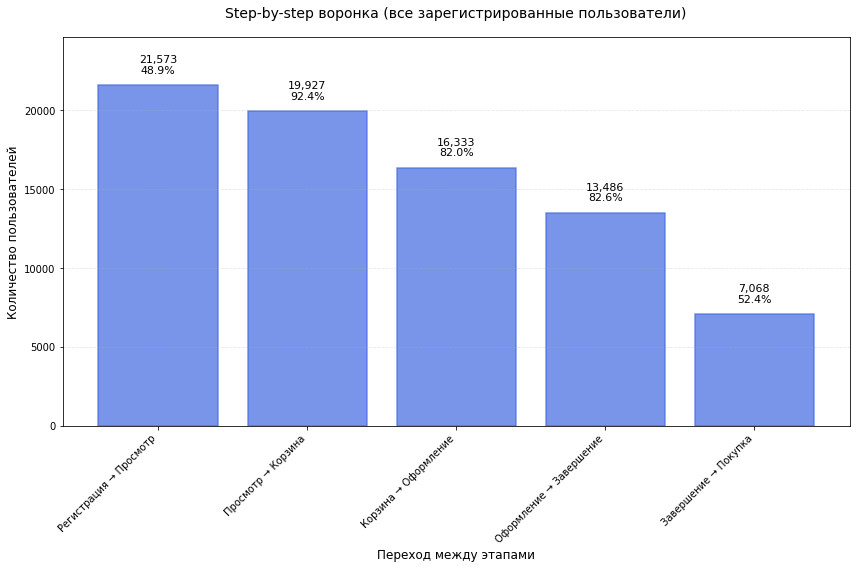

In [99]:
# Визуализация step-by-step воронки для всех пользователей

plt.figure(figsize=(12, 8))

bars = plt.bar(step_by_step_transitions_all['Переход'], step_by_step_transitions_all['Пользователи'], 
               color='royalblue', alpha=0.7, edgecolor='royalblue', linewidth=1.5)

conversion_rates = step_by_step_transitions_all['Конверсия, %']
max_value = step_by_step_transitions_all['Пользователи'].max()
y_offset = max_value * 0.06

for bar, value, conv in zip(bars, step_by_step_transitions_all['Пользователи'], conversion_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset,
             f'{value:,}', ha='center', va='bottom', fontsize=11)
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset - max_value * 0.03,
             f'{conv}%', ha='center', va='bottom', fontsize=11)

plt.ylim(0, max_value + y_offset + max_value * 0.08)
plt.title('Step-by-step воронка (все зарегистрированные пользователи)', fontsize=14, pad=20)
plt.xlabel('Переход между этапами', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Для сопоставления покажем воронку только для активных пользователей — тех, кто совершил хотя бы одно событие после регистрации. Это позволит увидеть, как работает продукт с аудиторией, которая начала взаимодействие.

In [100]:
# Построение продуктовой воронки для активных пользователей

# Получаем список активных пользователей
active_users_list = pa_marketplace_events['user_id'].unique()
print(f"Активных пользователей: {len(active_users_list)}")

Активных пользователей: 21602


In [101]:
# Для каждого этапа считаем количество пользователей
step1_count = len(active_users_list)
users_product_view = pa_marketplace_events[pa_marketplace_events['event_type'] == 'product_view']['user_id'].nunique()
users_add_to_cart = pa_marketplace_events[pa_marketplace_events['event_type'] == 'add_to_cart']['user_id'].nunique()
users_checkout_start = pa_marketplace_events[pa_marketplace_events['event_type'] == 'checkout_start']['user_id'].nunique()
users_checkout_complete = pa_marketplace_events[pa_marketplace_events['event_type'] == 'checkout_complete']['user_id'].nunique()
users_purchase = pa_marketplace_orders['user_id'].nunique()

# Создаем таблицу для воронки
funnel_data = pd.DataFrame({
    'Этап': ['1. Первое действие\n(активация)', 
             '2. Просмотр товара', 
             '3. Добавление в корзину', 
             '4. Начало оформления', 
             '5. Завершение оформления', 
             '6. Покупка'],
    'Пользователи': [step1_count, users_product_view, users_add_to_cart, 
                     users_checkout_start, users_checkout_complete, users_purchase]
})

# Рассчитываем конверсию
funnel_data['Конверсия от предыдущего, %'] = (
    funnel_data['Пользователи'] / funnel_data['Пользователи'].shift(1) * 100
).round(1)
funnel_data['Конверсия от первого этапа, %'] = (
    funnel_data['Пользователи'] / funnel_data['Пользователи'].iloc[0] * 100
).round(1)

# Заменяем NaN на '-'
funnel_data['Конверсия от предыдущего, %'] = funnel_data['Конверсия от предыдущего, %'].fillna('-')
funnel_data['Конверсия от первого этапа, %'] = funnel_data['Конверсия от первого этапа, %'].fillna('-')

print("Воронка активных пользователей:")
print(funnel_data.to_string(index=False))

Воронка активных пользователей:
                           Этап  Пользователи Конверсия от предыдущего, %  Конверсия от первого этапа, %
1. Первое действие\n(активация)         21602                           -                          100.0
             2. Просмотр товара         21533                        99.7                           99.7
        3. Добавление в корзину         19887                        92.4                           92.1
           4. Начало оформления         16293                        81.9                           75.4
       5. Завершение оформления         13486                        82.8                           62.4
                     6. Покупка          8654                        64.2                           40.1


Для отображения воронки лучше всего подходит столбчатая диаграмма с абсолютными значениями. Она позволяет наглядно увидеть, где происходит основной отток. Для наглядности исключаем первый этап (активацию), так как он всегда 100%.

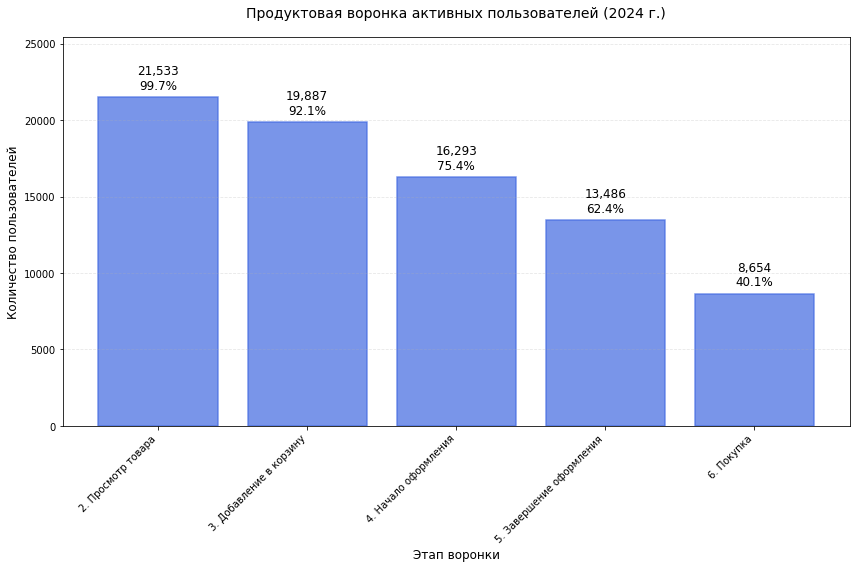

In [102]:
# Визуализация продуктовой воронки

# Исключаем первый этап (активацию)
funnel_data_filtered = funnel_data.iloc[1:].copy()

plt.figure(figsize=(12, 8))

bars = plt.bar(funnel_data_filtered['Этап'], funnel_data_filtered['Пользователи'], 
               color='royalblue', alpha=0.7, edgecolor='royalblue', linewidth=1.5)

conversion_rates = funnel_data_filtered['Конверсия от первого этапа, %']
max_value = funnel_data_filtered['Пользователи'].max()
y_offset_top = max_value * 0.06
spacing = max_value * 0.045

for bar, value, conv in zip(bars, funnel_data_filtered['Пользователи'], conversion_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset_top,
             f'{value:,}', ha='center', va='bottom', fontsize=12)
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset_top - spacing,
             f'{conv}%', ha='center', va='bottom', fontsize=12)

plt.ylim(0, max_value + y_offset_top + max_value * 0.12)
plt.title('Продуктовая воронка активных пользователей (2024 г.)', fontsize=14, pad=20)
plt.xlabel('Этап воронки', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Для более глубокого анализа посмотрим еще e-commerce воронку с последовательными шагами step-by-step. Конверсию будем считать от предыдущего шага.

In [103]:
# Step-by-step воронка (от активации до покупки)

# Берем только активных пользователей
active_events = pa_marketplace_events[pa_marketplace_events['user_id'].isin(active_users_list)]

# Создаем словарь соответствия событий и шагов
event_to_step = {
    'product_view': 1,
    'add_to_cart': 2,
    'checkout_start': 3,
    'checkout_complete': 4
}

# Для каждого пользователя находим максимальный шаг из событий
user_max_step = active_events[active_events['event_type'].isin(event_to_step.keys())].groupby('user_id')['event_type'].agg(
    lambda x: max([event_to_step[e] for e in x if e in event_to_step])
).reset_index()
user_max_step.columns = ['user_id', 'max_step']

# Добавляем информацию о покупке
user_max_step['has_purchase'] = user_max_step['user_id'].isin(pa_marketplace_orders['user_id'].unique())
user_max_step['final_step'] = user_max_step.apply(
    lambda row: 5 if row['has_purchase'] else row['max_step'], axis=1
)

# Считаем количество пользователей на каждом шаге
step_counts = {}
for step in range(1, 6):
    if step == 5:
        step_counts[step] = user_max_step[user_max_step['final_step'] >= step]['user_id'].nunique()
    else:
        step_counts[step] = user_max_step[user_max_step['max_step'] >= step]['user_id'].nunique()

# Создаем данные для визуализации с 5 переходами (включая активация → просмотр)
active_count = len(active_users_list)  # все активные пользователи
users_product_view = step_counts[1]     # пользователи, дошедшие до просмотра

# Формируем итоговую таблицу для визуализации
step_by_step_transitions = pd.DataFrame({
    'Переход': ['Активация → Просмотр', 
                'Просмотр → Корзина', 
                'Корзина → Оформление', 
                'Оформление → Завершение', 
                'Завершение → Покупка'],
    'Пользователи': [users_product_view, 
                     step_counts[2], 
                     step_counts[3], 
                     step_counts[4], 
                     step_counts[5]],
    'Конверсия, %': [
        round(users_product_view / active_count * 100, 1),
        round(step_counts[2] / step_counts[1] * 100, 1) if step_counts[1] > 0 else 0,
        round(step_counts[3] / step_counts[2] * 100, 1) if step_counts[2] > 0 else 0,
        round(step_counts[4] / step_counts[3] * 100, 1) if step_counts[3] > 0 else 0,
        round(step_counts[5] / step_counts[4] * 100, 1) if step_counts[4] > 0 else 0
    ]
})

# Выводим таблицу
print("Step-by-step воронка (от активации до покупки):")
print(step_by_step_transitions.to_string(index=False))

Step-by-step воронка (от активации до покупки):
                Переход  Пользователи  Конверсия, %
   Активация → Просмотр         21573          99.9
     Просмотр → Корзина         19927          92.4
   Корзина → Оформление         16333          82.0
Оформление → Завершение         13486          82.6
   Завершение → Покупка          7068          52.4


Для отображения конверсии между этапами тоже выберем столбчатую диаграмму. Подписи на оси X показывают переходы между этапами, а высота столбца - процент пользователей, перешедших на следующий шаг.

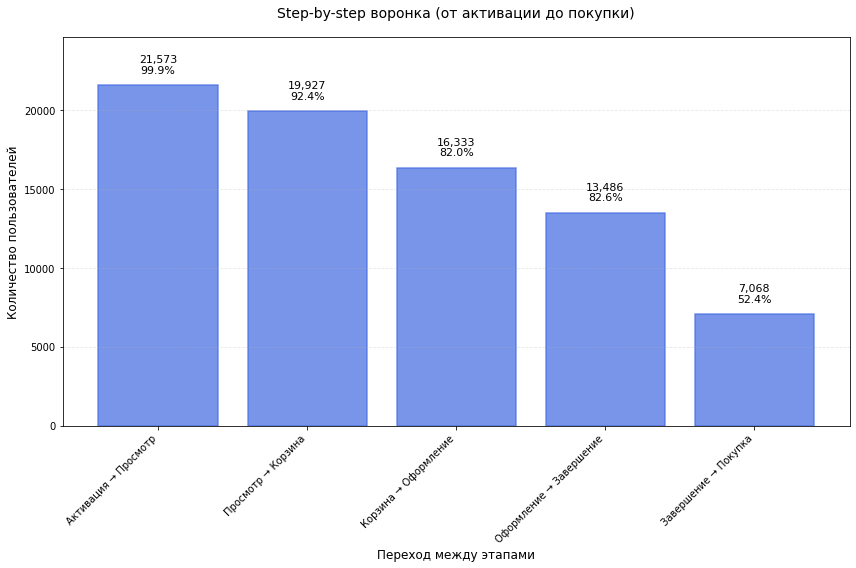

In [104]:
# Визуализация
plt.figure(figsize=(12, 8))

bars = plt.bar(step_by_step_transitions['Переход'], step_by_step_transitions['Пользователи'], 
               color='royalblue', alpha=0.7, edgecolor='royalblue', linewidth=1.5)

conversion_rates = step_by_step_transitions['Конверсия, %']
max_value = step_by_step_transitions['Пользователи'].max()
y_offset = max_value * 0.06  

# Добавляем подписи 
for bar, value, conv in zip(bars, step_by_step_transitions['Пользователи'], conversion_rates):
    # Число пользователей
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset,
             f'{value:,}', ha='center', va='bottom', fontsize=11)
    # Процент конверсии
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset - max_value * 0.03,
             f'{conv}%', ha='center', va='bottom', fontsize=11)

plt.ylim(0, max_value + y_offset + max_value * 0.08)
plt.title('Step-by-step воронка (от активации до покупки)', fontsize=14, pad=20)
plt.xlabel('Переход между этапами', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

**Предварительный вывод по продуктовой воронке**

Сопоставление двух подходов к анализу воронки дает полную картину состояния бизнеса.

**Воронка по всем зарегистрированным пользователям** показывает реальную эффективность маркетингового бюджета: из 100 привлеченных пользователей до просмотра товара доходит только 48,8, а до покупки - лишь 19,6. Это означает, что 80,4% привлеченной аудитории не окупает затраты на их привлечение. Основной провал происходит на первом же шаге: после регистрации 51,1% пользователей не совершают ни одного действия - это "мертвые души", на которых маркетинговый бюджет потрачен впустую.

**Воронка по активным пользователям** (исключающая "мертвые души") показывает совершенно иную картину. Среди тех, кто хотя бы начал взаимодействие, практически все (99,7%) доходят до просмотра товара, а конверсия в покупку составляет 40,1%. Самый критический отток среди активных происходит на финальном шаге - из завершивших оформление до покупки доходит только 64,2%, что указывает на проблемы с оплатой (например, сложность процесса оплаты). При этом начальные этапы воронки (просмотр → корзина → оформление) работают стабильно с конверсией 82-92%.

Инсайт:

Проблема бизнеса не в том, что продукт плохо продает (среди активных пользователей конверсия 40,1% — это отличный показатель), а в том, что половина привлеченной аудитории умирает на старте, даже не начав взаимодействие. Если бы удалось поднять активацию с текущих 48,9% до хотя бы 70%, выручка выросла бы на 40% без увеличения маркетингового бюджета. При этом даже среди активных пользователей есть потенциал роста за счет оптимизации финального шага оплаты, где теряется более трети потенциальных покупателей.

**Сегментация по каналам привлечения (acq_channel)**

Каналы привлечения - это первое, что нужно проанализировать в рамках сегментации. Именно здесь скрыта одна из главных причин роста CAC и падения качества аудитории. Мы уже знаем, что во втором полугодии CAC вырос в 5 раз, а доля платящих среди активных пользователей упала с 43,5% до 23,7%. Теперь наша задача - понять, какие каналы приносят качественных платящих пользователей, а какие - "мертвые души" и убыточных клиентов.

Для каждого канала привлечения рассчитаем:

- объём трафика: количество зарегистрированных пользователей vs количество активных
- кто дошёл до покупки: количество платящих пользователей (все пользователи vs активные)
- воронки (классическую и step-by-step) в разрезе каналов на одном поле для сравнения
- средний чек (AOV): покупательская способность аудитории канала
- выручку на пользователя (ARPU): общая монетизация
- CAC: стоимость привлечения одного платящего


Такой набор метрик позволит ответить на главные вопросы: какие каналы масштабировать, какие отключать, а какие требуют доработки онбординга.

Сначала подготовим данные:

In [105]:
# Подготовка данных для сегментации по каналам привлечения

# Получаем данные о пользователях с каналами привлечения
users_channels = pa_marketplace_users[['user_id', 'acq_channel']].copy()

# Отмечаем активных пользователей (есть хотя бы одно событие)
active_users_set = set(pa_marketplace_events['user_id'].unique())
users_channels['is_active'] = users_channels['user_id'].isin(active_users_set).astype(int)

# Отмечаем платящих пользователей (есть хотя бы один заказ)
paying_users_set = set(pa_marketplace_orders['user_id'].unique())
users_channels['is_paying'] = users_channels['user_id'].isin(paying_users_set).astype(int)

# Собираем выручку по пользователям (для ARPU и AOV)
user_revenue = pa_marketplace_orders.groupby('user_id')['revenue'].sum().reset_index()
user_revenue.columns = ['user_id', 'user_revenue']

# Собираем количество заказов и сумму GMV по пользователям (для AOV)
user_orders = pa_marketplace_orders.groupby('user_id').agg(
    orders_count=('order_id', 'count'),
    total_gmv=('total_price', 'sum')
).reset_index()

# Объединяем все данные
channel_data = users_channels.merge(user_revenue, on='user_id', how='left')
channel_data = channel_data.merge(user_orders, on='user_id', how='left')

# Заполняем NaN для неплатящих
channel_data['user_revenue'] = channel_data['user_revenue'].fillna(0)
channel_data['orders_count'] = channel_data['orders_count'].fillna(0)
channel_data['total_gmv'] = channel_data['total_gmv'].fillna(0)

# 7. Агрегируем по каналам
channel_agg = channel_data.groupby('acq_channel').agg(
    registered_users=('user_id', 'count'),
    active_users=('is_active', 'sum'),
    paying_users=('is_paying', 'sum'),
    total_revenue=('user_revenue', 'sum'),
    total_orders=('orders_count', 'sum'),
    total_gmv=('total_gmv', 'sum')
).reset_index()

# Выводим таблицу
print(channel_agg.to_string(index=False))

    acq_channel  registered_users  active_users  paying_users  total_revenue  total_orders    total_gmv
      affiliate              6069          3690          2338   6735814.7765        9668.0 134716295.53
email marketing              2044          1272           325    555698.7405         793.0  11113974.81
     google ads              9319          5612          3187   8236760.2370       11896.0 164735204.74
            seo              3312          2167           874   1909934.7465        2803.0  38198694.93
   social media              4179          2198          1211   3000254.7405        3978.0  60005094.81
         tiktok             19228          6663           719    910448.2055        1308.0  18208964.11


In [106]:
# Рассчитываем метрики
channel_agg['activation_rate'] = (channel_agg['active_users'] / channel_agg['registered_users'] * 100).round(1)
channel_agg['classic_conversion'] = (channel_agg['paying_users'] / channel_agg['registered_users'] * 100).round(1)
channel_agg['active_conversion'] = (channel_agg['paying_users'] / channel_agg['active_users'] * 100).round(1)
channel_agg['aov'] = (channel_agg['total_gmv'] / channel_agg['total_orders']).round(2)
channel_agg['arpu'] = (channel_agg['total_revenue'] / channel_agg['registered_users']).round(2)

# Добавляем CAC (стоимость привлечения платящего)
# Подготавливаем данные о бюджетах по каналам
campaign_costs = pa_marketplace_campaign_costs.copy()
campaign_costs['acq_channel'] = campaign_costs['acq_channel'].str.lower()
budget_by_channel = campaign_costs.groupby('acq_channel')['budget'].sum().reset_index()
budget_by_channel.columns = ['acq_channel', 'total_budget']

# Объединяем с данными по каналам
channel_agg = channel_agg.merge(budget_by_channel, on='acq_channel', how='left')
channel_agg['cac'] = (channel_agg['total_budget'] / channel_agg['paying_users']).round(2)

# Сортируем для удобства
channel_agg = channel_agg.sort_values('registered_users', ascending=False)

print("Метрики по каналам привлечения:")
channel_agg

Метрики по каналам привлечения:


,acq_channel,registered_users,active_users,paying_users,total_revenue,total_orders,total_gmv,activation_rate,classic_conversion,active_conversion,aov,arpu,total_budget,cac
5,tiktok,19228,6663,719,9.104482e+05,1308.0,1.820896e+07,34.7,3.7,10.8,13921.23,47.35,9.695376e+06,13484.53
2,google ads,9319,5612,3187,8.236760e+06,11896.0,1.647352e+08,60.2,34.2,56.8,13847.95,883.87,4.663490e+06,1463.29
0,affiliate,6069,3690,2338,6.735815e+06,9668.0,1.347163e+08,60.8,38.5,63.4,13934.25,1109.87,2.012341e+06,860.71
4,social media,4179,2198,1211,3.000255e+06,3978.0,6.000509e+07,52.6,29.0,55.1,15084.24,717.94,1.647396e+06,1360.36
3,seo,3312,2167,874,1.909935e+06,2803.0,3.819869e+07,65.4,26.4,40.3,13627.79,576.67,6.615116e+05,756.88
1,email marketing,2044,1272,325,5.556987e+05,793.0,1.111397e+07,62.2,15.9,25.6,14015.10,271.87,5.383424e+05,1656.44


Для сравнения каналов лучше всего подходят столбчатые диаграммы. Они позволяют наглядно увидеть, какие каналы лидируют по объёму трафика, конверсии и эффективности. Для ключевых метрик (конверсия, AOV, CAC) построим отдельные графики, чтобы акцентировать внимание на важных различиях.

Настроим цвета

In [107]:
# Настройка цветов 
colors = {'google ads': 'royalblue', 'email marketing': 'darkcyan', 
          'affiliate': 'dimgrey', 'seo': 'lightcoral', 
          'social media': 'mediumseagreen', 'tiktok': 'goldenrod'}

Зарегистрированные vs активные пользователи по каналам

Сравниваем количество зарегистрированных и активных пользователей в разрезе каналов. Это позволяет оценить, какой канал привлекает больше "мёртвых душ" (пользователи, которые зарегистрировались, но не совершили ни одного действия), а какой приводит более вовлечённую аудиторию. Чем меньше разрыв между столбцами, тем лучше канал справляется с активацией.

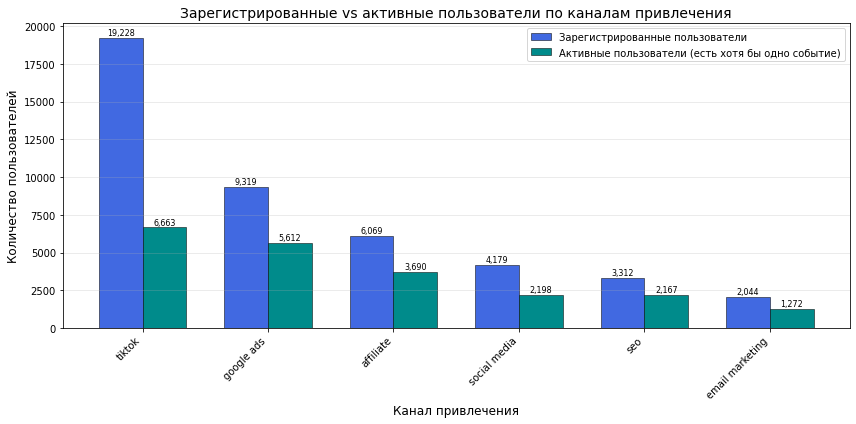

In [108]:
# Сравнение: зарегистрированные vs активные пользователи по каналам
plt.figure(figsize=(12, 6))

x = np.arange(len(channel_agg['acq_channel']))
width = 0.35

bars1 = plt.bar(x - width/2, channel_agg['registered_users'], width, 
                label='Зарегистрированные пользователи',
                color='royalblue', edgecolor='black', linewidth=0.5)
bars2 = plt.bar(x + width/2, channel_agg['active_users'], width,
                label='Активные пользователи (есть хотя бы одно событие)',
                color='darkcyan', edgecolor='black', linewidth=0.5)

plt.title('Зарегистрированные vs активные пользователи по каналам привлечения', fontsize=14)
plt.xlabel('Канал привлечения', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(x, channel_agg['acq_channel'], rotation=45, ha='right')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

# Добавляем подписи значений на столбцы
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

TikTok привёл наибольшее количество пользователей (19228), но при этом доля активных самая низкая - только 34,7%. Это значит, что 65% пришедших с TikTok не совершили ни одного действия. Google Ads и Affiliate показывают сбалансированный результат: высокая активация (60,2% и 60,8%) при значительном объёме трафика. SEO лидирует по активации (65,4%), но уступает по масштабу. Email Marketing имеет небольшой трафик, но активация 62,2%, хороший показатель.

Сравнение конверсий в покупку по каналам (все vs активные)

Классическая конверсия (от регистрации до покупки) показывает общую эффективность канала с учётом всех привлечённых пользователей. Конверсия из активных в покупку показывает, насколько хорошо канал приводит платящих среди тех, кто хотя бы начал взаимодействие. Разрыв между этими метриками - это доля "мёртвых душ".

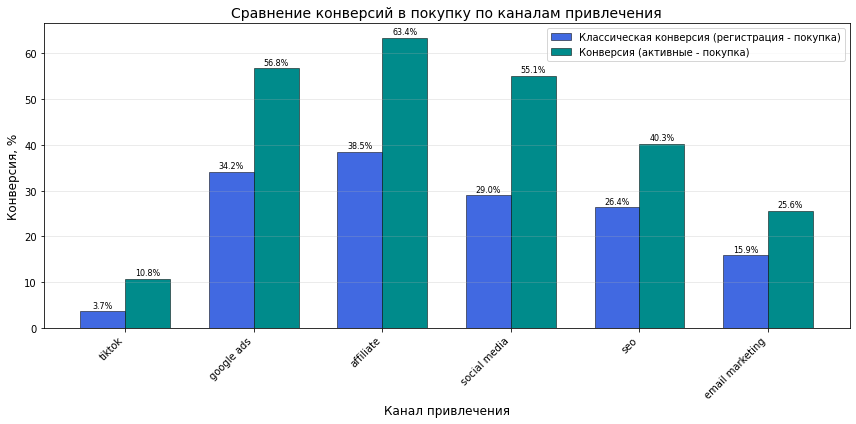

In [109]:
# Сравнение конверсий в покупку: классическая (регистрация - покупка) vs активная (активные - покупка) по каналам привлечения
plt.figure(figsize=(12, 6))

x = np.arange(len(channel_agg['acq_channel']))  # позиции для групп
width = 0.35  # ширина столбца

bars1 = plt.bar(x - width/2, channel_agg['classic_conversion'], width, 
                label='Классическая конверсия (регистрация - покупка)',
                color='royalblue', edgecolor='black', linewidth=0.5)
bars2 = plt.bar(x + width/2, channel_agg['active_conversion'], width,
                label='Конверсия (активные - покупка)',
                color='darkcyan', edgecolor='black', linewidth=0.5)

plt.title('Сравнение конверсий в покупку по каналам привлечения', fontsize=14)
plt.xlabel('Канал привлечения', fontsize=12)
plt.ylabel('Конверсия, %', fontsize=12)
plt.xticks(x, channel_agg['acq_channel'], rotation=45, ha='right')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

# Добавляем подписи значений на столбцы
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Наибольший разрыв между конверсиями у TikTok: классическая конверсия всего 3,7%, а среди активных - 10,8%. Это означает, что TikTok приводит много неактивной аудитории. Google Ads и Affiliate показывают лучшие результаты: классическая конверсия 34,2% и 38,5%, а среди активных - 56,8% и 63,4% соответственно. Это самые эффективные каналы по качеству трафика. Email Marketing показывает низкую классическую конверсию (15,9%), но среди активных - 25,6%, что говорит о проблемах с активацией, а не с продуктом.

Посмотрим продуктовые воронки по каналам

In [110]:
# Создаём данные для воронок по каналам на основе channel_agg

funnel_channels_data = []

for channel in channel_agg['acq_channel']:
    # Получаем пользователей этого канала
    channel_users = pa_marketplace_users[pa_marketplace_users['acq_channel'] == channel]['user_id'].unique()
    
    # Количество зарегистрированных
    registered = len(channel_users)
    
    # Количество пользователей на каждом этапе воронки
    product_view = pa_marketplace_events[
        (pa_marketplace_events['user_id'].isin(channel_users)) & 
        (pa_marketplace_events['event_type'] == 'product_view')
    ]['user_id'].nunique()
    
    add_to_cart = pa_marketplace_events[
        (pa_marketplace_events['user_id'].isin(channel_users)) & 
        (pa_marketplace_events['event_type'] == 'add_to_cart')
    ]['user_id'].nunique()
    
    checkout_start = pa_marketplace_events[
        (pa_marketplace_events['user_id'].isin(channel_users)) & 
        (pa_marketplace_events['event_type'] == 'checkout_start')
    ]['user_id'].nunique()
    
    checkout_complete = pa_marketplace_events[
        (pa_marketplace_events['user_id'].isin(channel_users)) & 
        (pa_marketplace_events['event_type'] == 'checkout_complete')
    ]['user_id'].nunique()
    
    purchase = pa_marketplace_orders[
        pa_marketplace_orders['user_id'].isin(channel_users)
    ]['user_id'].nunique()
    
    funnel_channels_data.append({
        'channel': channel,
        'registered': registered,
        'product_view': product_view,
        'add_to_cart': add_to_cart,
        'checkout_start': checkout_start,
        'checkout_complete': checkout_complete,
        'purchase': purchase
    })

funnel_channels_df = pd.DataFrame(funnel_channels_data)

print("Данные для воронок по каналам:")
print(funnel_channels_df.to_string(index=False))

Данные для воронок по каналам:
        channel  registered  product_view  add_to_cart  checkout_start  checkout_complete  purchase
         tiktok       19228          6631         5649            3849               2633       719
     google ads        9319          5607         5344            4676               4105      3187
      affiliate        6069          3674         3531            3136               2774      2338
   social media        4179          2189         2062            1734               1467      1211
            seo        3312          2160         2091            1853               1620       874
email marketing        2044          1272         1210            1045                887       325


Классическая воронка по каналам (конверсия от регистрации)

Строим классическую воронку для каждого канала, где конверсия считается от регистрации (накопленным итогом). Это позволяет сравнить, какой канал лучше проводит пользователя по всему пути от регистрации до покупки. На одном графике отображаем все каналы - так видно, где какой канал проседает.

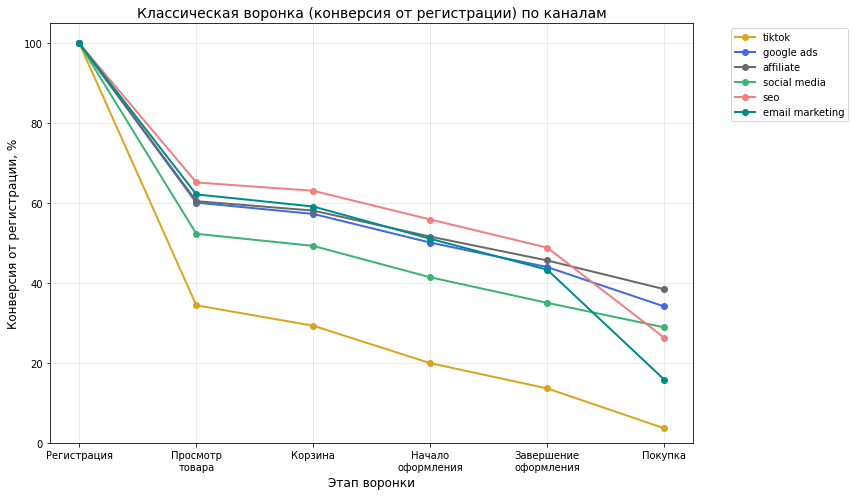

In [111]:
# Классическая воронка по каналам (конверсия от регистрации)

stages = ['Регистрация', 'Просмотр\nтовара', 'Корзина', 'Начало\nоформления', 
          'Завершение\nоформления', 'Покупка']

plt.figure(figsize=(12, 7))

for channel in funnel_channels_df['channel']:
    data = funnel_channels_df[funnel_channels_df['channel'] == channel].iloc[0]
    
    # Классическая конверсия (от регистрации)
    conv_registration = 100
    conv_view = data['product_view'] / data['registered'] * 100
    conv_cart = data['add_to_cart'] / data['registered'] * 100
    conv_checkout_start = data['checkout_start'] / data['registered'] * 100
    conv_checkout_complete = data['checkout_complete'] / data['registered'] * 100
    conv_purchase = data['purchase'] / data['registered'] * 100
    
    stage_values = [conv_registration, conv_view, conv_cart, 
                    conv_checkout_start, conv_checkout_complete, conv_purchase]
    
    plt.plot(stages, stage_values, marker='o', linewidth=2, markersize=6,
             color=colors.get(channel, 'gray'), label=channel)

plt.title('Классическая воронка (конверсия от регистрации) по каналам', fontsize=14)
plt.xlabel('Этап воронки', fontsize=12)
plt.ylabel('Конверсия от регистрации, %', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

Все каналы демонстрируют схожую динамику: основной отток происходит на первом этапе (регистрация - просмотр товара). Google Ads и Affiliate уверенно лидируют на всём пути, сохраняя конверсию в покупку на уровне 34–38%. TikTok и Email Marketing показывают самый низкий результат на всех этапах - к покупке доходит менее 5% и 16% соответственно. SEO и Social Media занимают промежуточное положение. Интересно, что после этапа "добавление в корзину" все каналы теряют пользователей примерно одинаково: проблемы с оплатой носят общепродуктовый характер, не зависящий от канала.

Step-by-step воронка (конверсия от предыдущего этапа) по каналам

Строим step-by-step воронку, где конверсия считается от предыдущего этапа. Это позволяет увидеть, на каком конкретном переходе какой канал теряет больше всего пользователей. График помогает диагностировать проблемные этапы для каждого канала.

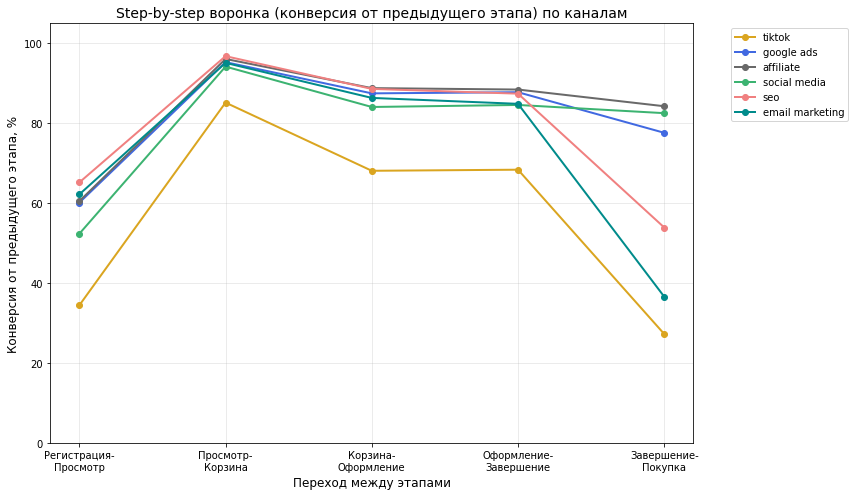

In [112]:
# Step-by-step воронка по каналам (конверсия от предыдущего этапа)

steps = ['Регистрация-\nПросмотр', 'Просмотр-\nКорзина', 'Корзина-\nОформление', 
         'Оформление-\nЗавершение', 'Завершение-\nПокупка']

plt.figure(figsize=(12, 7))

for channel in funnel_channels_df['channel']:
    data = funnel_channels_df[funnel_channels_df['channel'] == channel].iloc[0]
    
    # Step-by-step конверсии от предыдущего этапа
    conv_view = data['product_view'] / data['registered'] * 100 if data['registered'] > 0 else 0
    conv_cart = data['add_to_cart'] / data['product_view'] * 100 if data['product_view'] > 0 else 0
    conv_checkout_start = data['checkout_start'] / data['add_to_cart'] * 100 if data['add_to_cart'] > 0 else 0
    conv_checkout_complete = data['checkout_complete'] / data['checkout_start'] * 100 if data['checkout_start'] > 0 else 0
    conv_purchase = data['purchase'] / data['checkout_complete'] * 100 if data['checkout_complete'] > 0 else 0
    
    step_values = [conv_view, conv_cart, conv_checkout_start, conv_checkout_complete, conv_purchase]
    
    plt.plot(steps, step_values, marker='o', linewidth=2, markersize=6,
             color=colors.get(channel, 'gray'), label=channel)

plt.title('Step-by-step воронка (конверсия от предыдущего этапа) по каналам', fontsize=14)
plt.xlabel('Переход между этапами', fontsize=12)
plt.ylabel('Конверсия от предыдущего этапа, %', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

Первый переход (регистрация - просмотр товара) - самый критичный для всех каналов. TikTok теряет здесь 65% пользователей, Email Marketing около 38%, а лучшие показатели у SEO (35% потерь) и Affiliate (39% потерь). На переходах "просмотр - корзина" и "корзина - оформление" все каналы показывают высокую конверсию (80–95%), значит, здесь проблем нет. Финальный переход (завершение оформления - покупка) это вторая проблемная зона: все каналы теряют 35–50% пользователей. Это указывает на общепродуктовую проблему с оплатой, не зависящую от канала привлечения.

CAC по каналам

CAC - стоимость привлечения одного платящего пользователя. Рассчитывается как бюджет канала, делённый на количество платящих. Показывает, какой канал экономически эффективен, а какой убыточен. Сравниваем с ARPPU (средний доход на платящего), который в среднем по рынку составляет 2467 рублей.

In [113]:
# ARPPU из этапа 3 (средний доход на платящего)
arppu = total_revenue / n_paying_users
print(f"ARPPU = {arppu:.2f} руб.")

ARPPU = 2466.94 руб.


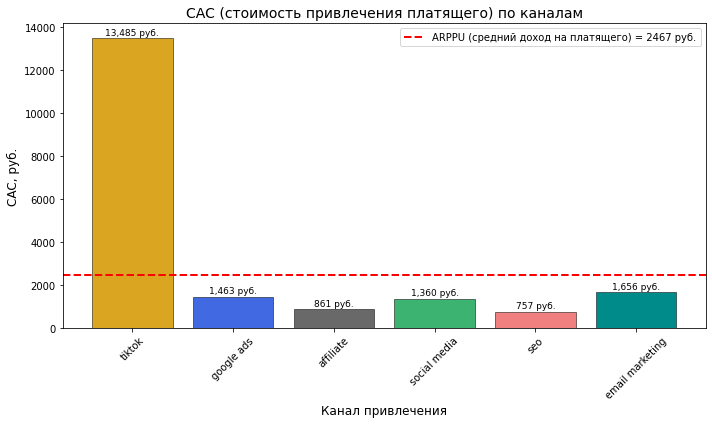

In [114]:
# CAC (стоимость привлечения платящего) по каналам с линией ARPPU
plt.figure(figsize=(10, 6))

bars = plt.bar(channel_agg['acq_channel'], channel_agg['cac'], 
               color=[colors.get(ch, 'steelblue') for ch in channel_agg['acq_channel']],
               edgecolor='black', linewidth=0.5)

# Добавляем горизонтальную линию ARPPU
plt.axhline(y=arppu, color='red', linestyle='--', linewidth=2, 
            label=f'ARPPU (средний доход на платящего) = {arppu:.0f} руб.')

plt.title('CAC (стоимость привлечения платящего) по каналам', fontsize=14)
plt.xlabel('Канал привлечения', fontsize=12)
plt.ylabel('CAC, руб.', fontsize=12)
plt.xticks(rotation=45)
plt.legend(loc='upper right')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{bar.get_height():,.0f} руб.', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Самый низкий CAC у SEO (757 руб.) и Affiliate (861 руб.) - эти каналы эффективны и масштабируемы. Google Ads (1463 руб.) и Social Media (1360 руб.) находятся в приемлемом диапазоне. TikTok показывает катастрофический CAC (13485 руб.) - привлечение одного платящего стоит в 5,5 раз больше, чем средний доход с него. Email Marketing также неэффективен (CAC 1656 руб. при ARPPU 2 467 руб. маржинальность низкая. Канал не убыточен, но и не эффективен, требует оптимизации). Рекомендация: отключить TikTok, перераспределить бюджет в SEO и Affiliate.

ARPU средний доход на всех пользователей

ARPU - средний доход на одного зарегистрированного пользователя. Показывает, сколько денег в среднем приносит каждый привлечённый пользователь (независимо от того, платил он или нет). Это показатель эффективности канала, учитывающий и конверсию, и средний чек.

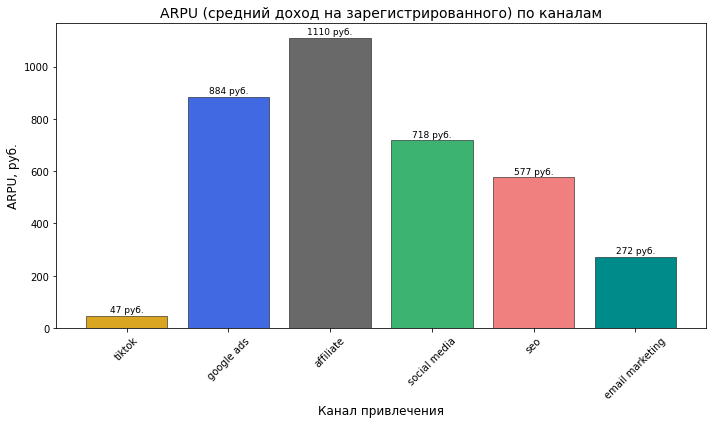

In [115]:
# ARPU (средний доход на зарегистрированного) по каналам
plt.figure(figsize=(10, 6))
bars = plt.bar(channel_agg['acq_channel'], channel_agg['arpu'], 
               color=[colors.get(ch, 'steelblue') for ch in channel_agg['acq_channel']],
               edgecolor='black', linewidth=0.5)
plt.title('ARPU (средний доход на зарегистрированного) по каналам', fontsize=14)
plt.xlabel('Канал привлечения', fontsize=12)
plt.ylabel('ARPU, руб.', fontsize=12)
plt.xticks(rotation=45)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{bar.get_height():.0f} руб.', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Google Ads и Affiliate лидируют по ARPU (884 руб. и 1110 руб. соответственно) - каждый привлечённый пользователь приносит значительный доход. Social Media (718 руб.) и SEO (577 руб.) показывают средние результаты. TikTok (47 руб.) и Email Marketing (272 руб.) имеют низкий ARPU из-за высокой доли "мёртвых душ" и низкой конверсии. Это подтверждает выводы предыдущих графиков.

AOV средний чек на платящего

AOV - средний чек (средняя сумма одного заказа). Рассчитывается только на платящих пользователях. Показывает покупательскую способность аудитории, пришедшей через разные каналы. Высокий AOV может компенсировать низкую конверсию.

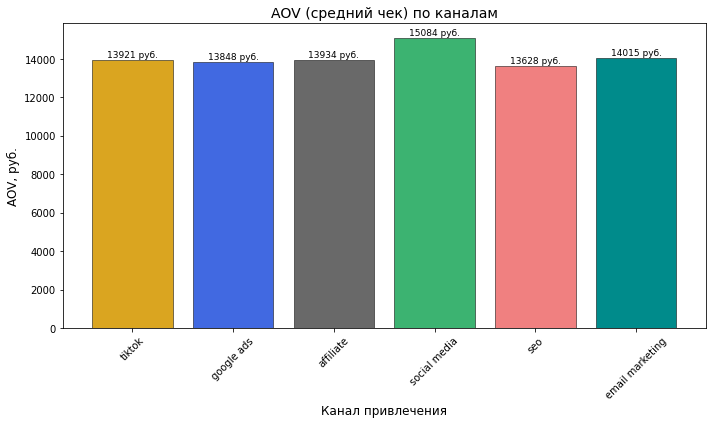

In [116]:
# AOV (средний чек) по каналам
plt.figure(figsize=(10, 6))
bars = plt.bar(channel_agg['acq_channel'], channel_agg['aov'], 
               color=[colors.get(ch, 'steelblue') for ch in channel_agg['acq_channel']],
               edgecolor='black', linewidth=0.5)
plt.title('AOV (средний чек) по каналам', fontsize=14)
plt.xlabel('Канал привлечения', fontsize=12)
plt.ylabel('AOV, руб.', fontsize=12)
plt.xticks(rotation=45)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{bar.get_height():.0f} руб.', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

AOV по каналам стабилен и находится в диапазоне 13600–15100 рублей. Самый высокий средний чек у Social Media (15084 руб.), самый низкий у SEO (13628 руб.). Разница незначительна (около 10% от среднего значения). Это означает, что проблема низкой эффективности каналов (TikTok, Email Marketing) связана не с покупательской способностью, а с низкой конверсией и высокой долей неактивных пользователей.

**Предварительный вывод по сегментации по каналам привлечения**

Анализ каналов привлечения выявил чёткое разделение на три группы: эффективные, средние и проблемные.

- Эффективные каналы: лидеры по качеству трафика и экономической эффективности это каналы Affiliate и Google Ads. Оба канала показывают высокую активацию (60–61%), конверсию из активных в покупку (56–63%) и классическую конверсию (34–38%). CAC у Affiliate (861 руб.) и Google Ads (1463 руб.) ниже ARPPU (2467 руб.), что делает их прибыльными. ARPU также высокий (884–1110 руб.). Это каналы, которые нужно масштабировать.

- Средние каналы: SEO и Social Media занимают промежуточное положение. SEO лидирует по активации (65,4%) и имеет самый низкий CAC (757 руб.), что делает его самым эффективным с точки зрения затрат. Однако его масштаб невелик (3312 зарегистрированных пользователей). Social Media показывает хорошую конверсию из активных в покупку (55,1%) и высокий AOV (15084 руб.), но уступает лидерам по объёму трафика и ARPU. Оба канала требуют осторожного масштабирования с сохранением качества.

- Проблемные каналы: TikTok и Email Marketing. TikTok привлёк наибольшее количество пользователей (19228), но доля активных всего 34,7%, классическая конверсия 3,7%, а CAC достигает 13485 рублей - это в 5,5 раз выше ARPPU. Канал убыточен. Email Marketing показывает низкую классическую конверсию (15,9%) и высокий CAC (1656 руб.) при небольшом объёме трафика. Рекомендация: отключить TikTok, перераспределить бюджет в Affiliate и SEO. Email Marketing требует доработки стратегии или полного пересмотра.

Инсайт: 

Step-by-step воронка показала, что на переходах "просмотр - корзина" и "корзина - оформление" все каналы демонстрируют высокую конверсию (80–95%). Проблемы с оплатой (финальный переход) и активацией (первый переход) носят общепродуктовый характер и не зависят от канала. AOV стабилен по всем каналам (13600–15100 руб.), что подтверждает: проблема не в покупательской способности аудитории, а в низкой конверсии и высокой доле неактивных пользователей.

Точки роста по каналам:
- Масштабировать Affiliate, Google Ads и SEO
- Отключить TikTok, пересмотреть Email Marketing
- Улучшать активацию и оплату на уровне продукта, это повысит эффективность всех каналов.

**Сегментация по регионам (region)**

Региональная сегментация позволяет понять, в каких регионах продукт востребован больше, а где наблюдаются проблемы с активацией, конверсией или монетизацией. Это поможет принять решения о перераспределении рекламных бюджетов, адаптации контента под локальные особенности или точечной работе с проблемными регионами.

Для каждого региона рассчитаем:

- объём трафика: количество зарегистрированных пользователей vs количество активных
- кто дошёл до покупки: количество платящих пользователей (все пользователи vs активные)
- воронки (классическую и step-by-step) в разрезе регионов на одном поле для сравнения
- средний чек (AOV): покупательская способность аудитории региона
- выручку на пользователя (ARPU): общая монетизация

Такой набор метрик позволит ответить на главные вопросы: какие регионы масштабировать, какие требуют доработки онбординга, а где продукт не "заходит".

Сначала подготовим данные

In [117]:
# Получаем данные о пользователях с регионами
users_regions = pa_marketplace_users[['user_id', 'region']].copy()

# Отмечаем активных пользователей (есть хотя бы одно событие)
active_users_set = set(pa_marketplace_events['user_id'].unique())
users_regions['is_active'] = users_regions['user_id'].isin(active_users_set).astype(int)

# Отмечаем платящих пользователей (есть хотя бы один заказ)
paying_users_set = set(pa_marketplace_orders['user_id'].unique())
users_regions['is_paying'] = users_regions['user_id'].isin(paying_users_set).astype(int)

# Собираем выручку по пользователям
user_revenue = pa_marketplace_orders.groupby('user_id')['revenue'].sum().reset_index()
user_revenue.columns = ['user_id', 'user_revenue']

# Собираем количество заказов и сумму GMV по пользователям (для AOV)
user_orders = pa_marketplace_orders.groupby('user_id').agg(
    orders_count=('order_id', 'count'),
    total_gmv=('total_price', 'sum')
).reset_index()

# Объединяем все данные
region_data = users_regions.merge(user_revenue, on='user_id', how='left')
region_data = region_data.merge(user_orders, on='user_id', how='left')

# Заполняем NaN для неплатящих
region_data['user_revenue'] = region_data['user_revenue'].fillna(0)
region_data['orders_count'] = region_data['orders_count'].fillna(0)
region_data['total_gmv'] = region_data['total_gmv'].fillna(0)

# Агрегируем по регионам
region_agg = region_data.groupby('region').agg(
    registered_users=('user_id', 'count'),
    active_users=('is_active', 'sum'),
    paying_users=('is_paying', 'sum'),
    total_revenue=('user_revenue', 'sum'),
    total_orders=('orders_count', 'sum'),
    total_gmv=('total_gmv', 'sum')
).reset_index()

# Выводим таблицу
print(region_agg.to_string(index=False))

            region  registered_users  active_users  paying_users  total_revenue  total_orders    total_gmv
    Другие Регионы             14516          7146          2816   6837361.3200        9807.0 136747226.40
      Екатеринбург              2145          1019           418   1143765.8995        1592.0  22875317.99
         Краснодар              1398           698           290    728837.6345         949.0  14576752.69
            Москва             10959          5433          2200   5410184.1500        7949.0 108203683.00
Московская Область              3549          1729           681   1658614.0185        2280.0  33172280.37
   Нижний Новгород              1748           833           354    841422.0020        1224.0  16828440.04
       Новосибирск              1723           817           310    728729.0540        1072.0  14574581.08
    Ростов-На-Дону              1423           688           268    603704.7930         906.0  12074095.86
   Санкт-Петербург              6690 

In [118]:
# Рассчитываем метрики
region_agg['activation_rate'] = (region_agg['active_users'] / region_agg['registered_users'] * 100).round(1)
region_agg['classic_conversion'] = (region_agg['paying_users'] / region_agg['registered_users'] * 100).round(1)
region_agg['active_conversion'] = (region_agg['paying_users'] / region_agg['active_users'] * 100).round(1)
region_agg['aov'] = (region_agg['total_gmv'] / region_agg['total_orders']).round(2)
region_agg['arpu'] = (region_agg['total_revenue'] / region_agg['registered_users']).round(2)

# Сортируем для удобства
region_agg = region_agg.sort_values('registered_users', ascending=False)

print("Метрики по регионам:")
region_agg

Метрики по регионам:


,region,registered_users,active_users,paying_users,total_revenue,total_orders,total_gmv,activation_rate,classic_conversion,active_conversion,aov,arpu
0,Другие Регионы,14516,7146,2816,6.837361e+06,9807.0,1.367472e+08,49.2,19.4,39.4,13943.84,471.02
3,Москва,10959,5433,2200,5.410184e+06,7949.0,1.082037e+08,49.6,20.1,40.5,13612.24,493.67
8,Санкт-Петербург,6690,3239,1317,3.396293e+06,4667.0,6.792585e+07,48.4,19.7,40.7,14554.50,507.67
4,Московская Область,3549,1729,681,1.658614e+06,2280.0,3.317228e+07,48.7,19.2,39.4,14549.25,467.35
1,Екатеринбург,2145,1019,418,1.143766e+06,1592.0,2.287532e+07,47.5,19.5,41.0,14368.92,533.22
5,Нижний Новгород,1748,833,354,8.414220e+05,1224.0,1.682844e+07,47.7,20.3,42.5,13748.73,481.36
6,Новосибирск,1723,817,310,7.287291e+05,1072.0,1.457458e+07,47.4,18.0,37.9,13595.69,422.94
7,Ростов-На-Дону,1423,688,268,6.037048e+05,906.0,1.207410e+07,48.3,18.8,39.0,13326.82,424.25
2,Краснодар,1398,698,290,7.288376e+05,949.0,1.457675e+07,49.9,20.7,41.5,15360.12,521.34


Настроим цвета для регионов

In [119]:
# Настройка цветов для регионов
region_colors = {
    'Москва': 'royalblue',
    'Санкт-Петербург': 'darkcyan',
    'Московская Область': 'dimgrey',
    'Краснодар': 'lightcoral',
    'Екатеринбург': 'mediumseagreen',
    'Новосибирск': 'goldenrod',
    'Нижний Новгород': 'steelblue',
    'Ростов-На-Дону': 'coral',
    'Другие Регионы': 'darkorange'
}

Зарегистрированные vs активные пользователи по регионам

Сравниваем количество зарегистрированных и активных пользователей в разрезе регионов. Это позволяет оценить, в каком регионе больше "мёртвых душ" (пользователи, которые зарегистрировались, но не совершили ни одного действия), а где аудитория более вовлечённая. Чем меньше разрыв между столбцами, тем лучше регион справляется с активацией.

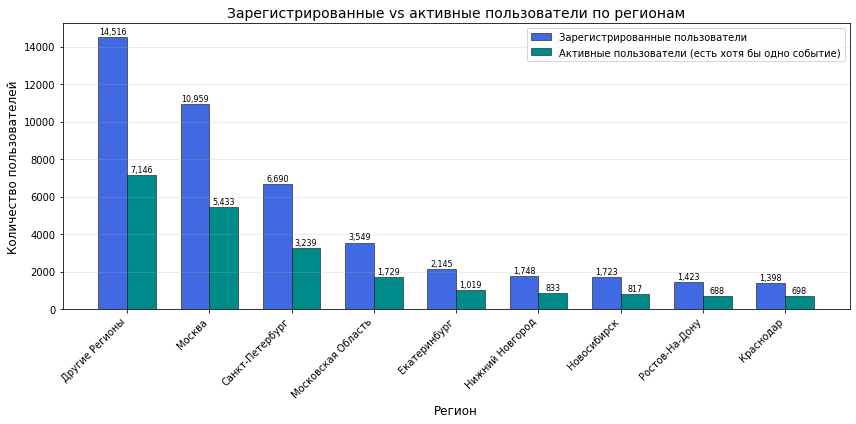

In [120]:
# Сравнение: зарегистрированные vs активные пользователи по регионам
plt.figure(figsize=(12, 6))

x = np.arange(len(region_agg['region']))
width = 0.35

bars1 = plt.bar(x - width/2, region_agg['registered_users'], width, 
                label='Зарегистрированные пользователи',
                color='royalblue', edgecolor='black', linewidth=0.5)
bars2 = plt.bar(x + width/2, region_agg['active_users'], width,
                label='Активные пользователи (есть хотя бы одно событие)',
                color='darkcyan', edgecolor='black', linewidth=0.5)

plt.title('Зарегистрированные vs активные пользователи по регионам', fontsize=14)
plt.xlabel('Регион', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(x, region_agg['region'], rotation=45, ha='right')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Лидеры по объёму трафика «Другие регионы» (14516 зарегистрированных), Москва (10959) и Санкт-Петербург (6690) - тут все логично, больше людей в целом в этих регионах и больше загеристрированных. Доля активации по всем регионам стабильна и находится в узком диапазоне 47–50%, без значительных разрывов. Лучшие показатели у Краснодара (49,9%), Москвы (49,6%) и «Других регионов» (49,2%). Самый низкий уровень активации в Новосибирске (47,4%) и Екатеринбурге (47,5%). Разница между регионами составляет всего 2,5 п.п., что говорит об отсутствии выраженных именно региональных проблем с активацией. «Мёртвые души» распределены равномерно по регионам.

Сравнение конверсий в покупке по регионам (все vs активные)

Классическая конверсия (от регистрации до покупки) показывает общую эффективность региона с учётом всех привлечённых пользователей. Конверсия из активных в покупку показывает, насколько хорошо регион конвертирует в платящих тех, кто хотя бы начал взаимодействие. Разрыв между этими метриками - это доля "мёртвых душ".

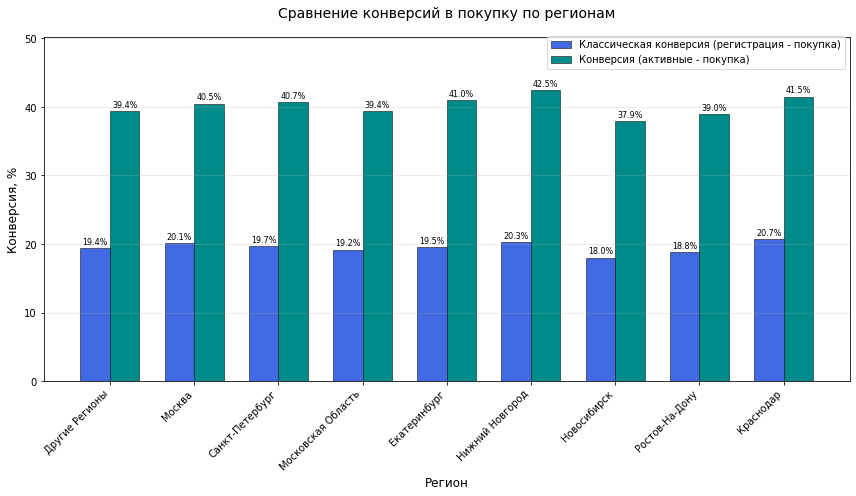

In [121]:
# Сравнение конверсий в покупку: классическая (регистрация - покупка) vs активная (активные - покупка) по регионам
plt.figure(figsize=(12, 7)) 

x = np.arange(len(region_agg['region']))
width = 0.35

bars1 = plt.bar(x - width/2, region_agg['classic_conversion'], width, 
                label='Классическая конверсия (регистрация - покупка)',
                color='royalblue', edgecolor='black', linewidth=0.5)
bars2 = plt.bar(x + width/2, region_agg['active_conversion'], width,
                label='Конверсия (активные - покупка)',
                color='darkcyan', edgecolor='black', linewidth=0.5)

plt.title('Сравнение конверсий в покупку по регионам', fontsize=14, pad=20) 
plt.xlabel('Регион', fontsize=12)
plt.ylabel('Конверсия, %', fontsize=12)
plt.xticks(x, region_agg['region'], rotation=45, ha='right')
plt.legend(loc='upper right', bbox_to_anchor=(1.0, 1.02))  
plt.grid(axis='y', alpha=0.3)

plt.ylim(0, max(region_agg['classic_conversion'].max(), region_agg['active_conversion'].max()) * 1.18)

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Классическая конверсия (от регистрации до покупки) по регионам варьируется от 18,0% (Новосибирск) до 20,7% (Краснодар). Разница между регионами минимальна, около 3 п.п. Конверсия из активных в покупку значительно выше (37,9–42,5%) и также стабильна по всем регионам. Это означает, что продукт одинаково хорошо конвертирует активных пользователей в покупателей независимо от региона. Проблемы с активацией и конверсией носят общепродуктовый, а не региональный характер.

Посмотрим продуктовые воронки по регионам

In [122]:
# Создаём данные для воронок по регионам
funnel_regions_data = []

for region in region_agg['region']:
    region_users = pa_marketplace_users[pa_marketplace_users['region'] == region]['user_id'].unique()
    
    registered = len(region_users)
    
    product_view = pa_marketplace_events[
        (pa_marketplace_events['user_id'].isin(region_users)) & 
        (pa_marketplace_events['event_type'] == 'product_view')
    ]['user_id'].nunique()
    
    add_to_cart = pa_marketplace_events[
        (pa_marketplace_events['user_id'].isin(region_users)) & 
        (pa_marketplace_events['event_type'] == 'add_to_cart')
    ]['user_id'].nunique()
    
    checkout_start = pa_marketplace_events[
        (pa_marketplace_events['user_id'].isin(region_users)) & 
        (pa_marketplace_events['event_type'] == 'checkout_start')
    ]['user_id'].nunique()
    
    checkout_complete = pa_marketplace_events[
        (pa_marketplace_events['user_id'].isin(region_users)) & 
        (pa_marketplace_events['event_type'] == 'checkout_complete')
    ]['user_id'].nunique()
    
    purchase = pa_marketplace_orders[
        pa_marketplace_orders['user_id'].isin(region_users)
    ]['user_id'].nunique()
    
    funnel_regions_data.append({
        'region': region,
        'registered': registered,
        'product_view': product_view,
        'add_to_cart': add_to_cart,
        'checkout_start': checkout_start,
        'checkout_complete': checkout_complete,
        'purchase': purchase
    })

funnel_regions_df = pd.DataFrame(funnel_regions_data)

print("Данные для воронок по регионам:")
print(funnel_regions_df.to_string(index=False))

Данные для воронок по регионам:
            region  registered  product_view  add_to_cart  checkout_start  checkout_complete  purchase
    Другие Регионы       14516          7126         6598            5419               4505      2816
            Москва       10959          5419         4992            4083               3358      2200
   Санкт-Петербург        6690          3227         2974            2443               2006      1317
Московская Область        3549          1721         1599            1307               1090       681
      Екатеринбург        2145          1017          933             772                637       418
   Нижний Новгород        1748           829          769             643                535       354
       Новосибирск        1723           815          750             617                519       310
    Ростов-На-Дону        1423           686          621             479                395       268
         Краснодар        1398           

Классическая воронка по регионам (конверсия от регистрации)

Строим классическую воронку для каждого региона, где конверсия считается от регистрации (накопленным итогом). Это позволяет сравнить, какой регион лучше проводит пользователя по всему пути от регистрации до покупки. На одном графике отображаем все регионы - так видно, где какой регион проседает.

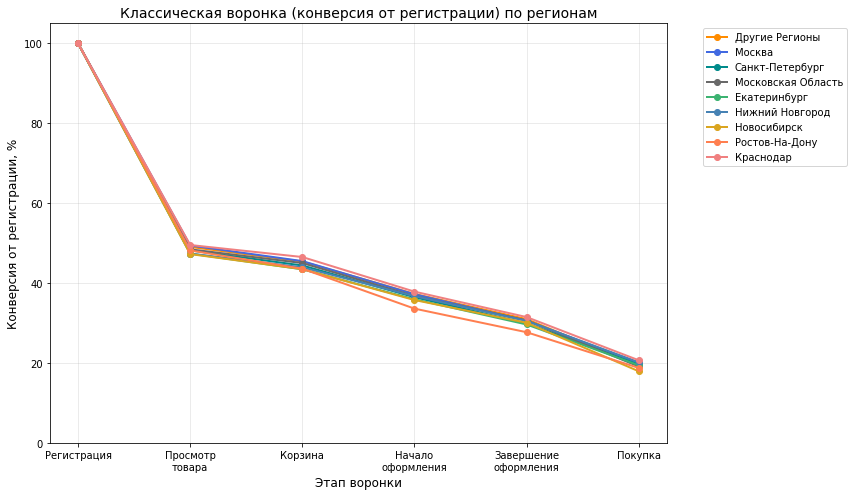

In [123]:
# Классическая воронка по регионам (конверсия от регистрации)

stages = ['Регистрация', 'Просмотр\nтовара', 'Корзина', 'Начало\nоформления', 
          'Завершение\nоформления', 'Покупка']

plt.figure(figsize=(12, 7))

for region in funnel_regions_df['region']:
    data = funnel_regions_df[funnel_regions_df['region'] == region].iloc[0]
    
    conv_registration = 100
    conv_view = data['product_view'] / data['registered'] * 100
    conv_cart = data['add_to_cart'] / data['registered'] * 100
    conv_checkout_start = data['checkout_start'] / data['registered'] * 100
    conv_checkout_complete = data['checkout_complete'] / data['registered'] * 100
    conv_purchase = data['purchase'] / data['registered'] * 100
    
    stage_values = [conv_registration, conv_view, conv_cart, 
                    conv_checkout_start, conv_checkout_complete, conv_purchase]
    
    plt.plot(stages, stage_values, marker='o', linewidth=2, markersize=6,
             color=region_colors.get(region, 'gray'), label=region)

plt.title('Классическая воронка (конверсия от регистрации) по регионам', fontsize=14)
plt.xlabel('Этап воронки', fontsize=12)
plt.ylabel('Конверсия от регистрации, %', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

Все регионы демонстрируют практически идентичную динамику на всех этапах воронки. Основной отток происходит на первом этапе (регистрация - просмотр товара) - конверсия падает с 100% до 48–50%. На последующих этапах потери минимальны и синхронны. Конверсия в покупку составляет 18–21% для всех регионов. Это подтверждает, что проблемы с активацией и оплатой не зависят от региона, а являются общепродуктовыми.

Step-by-step воронка по регионам (конверсия от предыдущего этапа)

Строим step-by-step воронку, где конверсия считается от предыдущего этапа. Это позволяет увидеть, на каком конкретном переходе какой регион теряет больше всего пользователей. График помогает диагностировать проблемные этапы для каждого региона.

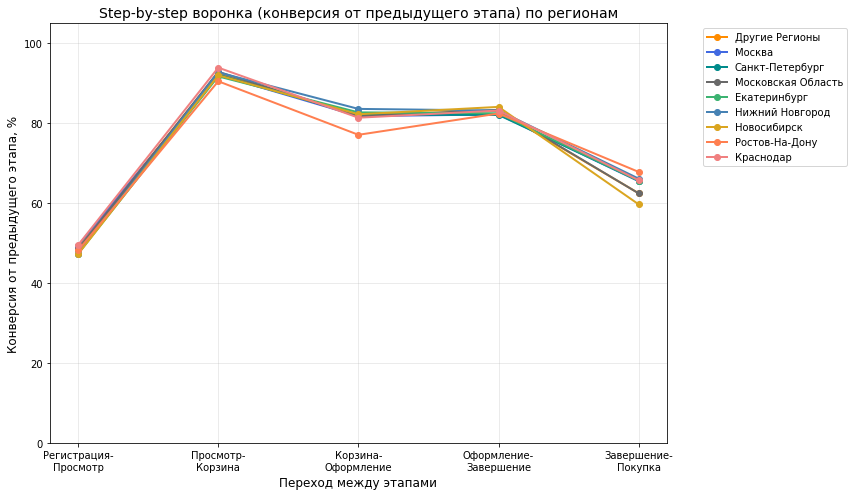

In [124]:
# Step-by-step воронка по регионам (конверсия от предыдущего этапа)

steps = ['Регистрация-\nПросмотр', 'Просмотр-\nКорзина', 'Корзина-\nОформление', 
         'Оформление-\nЗавершение', 'Завершение-\nПокупка']

plt.figure(figsize=(12, 7))

for region in funnel_regions_df['region']:
    data = funnel_regions_df[funnel_regions_df['region'] == region].iloc[0]
    
    conv_view = data['product_view'] / data['registered'] * 100 if data['registered'] > 0 else 0
    conv_cart = data['add_to_cart'] / data['product_view'] * 100 if data['product_view'] > 0 else 0
    conv_checkout_start = data['checkout_start'] / data['add_to_cart'] * 100 if data['add_to_cart'] > 0 else 0
    conv_checkout_complete = data['checkout_complete'] / data['checkout_start'] * 100 if data['checkout_start'] > 0 else 0
    conv_purchase = data['purchase'] / data['checkout_complete'] * 100 if data['checkout_complete'] > 0 else 0
    
    step_values = [conv_view, conv_cart, conv_checkout_start, conv_checkout_complete, conv_purchase]
    
    plt.plot(steps, step_values, marker='o', linewidth=2, markersize=6,
             color=region_colors.get(region, 'gray'), label=region)

plt.title('Step-by-step воронка (конверсия от предыдущего этапа) по регионам', fontsize=14)
plt.xlabel('Переход между этапами', fontsize=12)
plt.ylabel('Конверсия от предыдущего этапа, %', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

Первый переход (регистрация - просмотр) - самый критичный: конверсия составляет 48–50% во всех регионах без исключения. На переходах «просмотр - корзина» (90–93%), «корзина - оформление» (80–83%) и «оформление - завершение» (82–84%) все регионы показывают высокие и стабильные значения. Финальный переход (завершение - покупка) - вторая проблемная зона: конверсия падает до 60–65% во всех регионах. Это подтверждает, что проблемы с оплатой носят общепродуктовый характер.

ARPU (средний доход на зарегистрированного) по регионам

ARPU - средний доход на одного зарегистрированного пользователя. Показывает, сколько денег в среднем приносит каждый привлечённый пользователь (независимо от того, платил он или нет). Это показатель эффективности региона, учитывающий и конверсию, и средний чек.

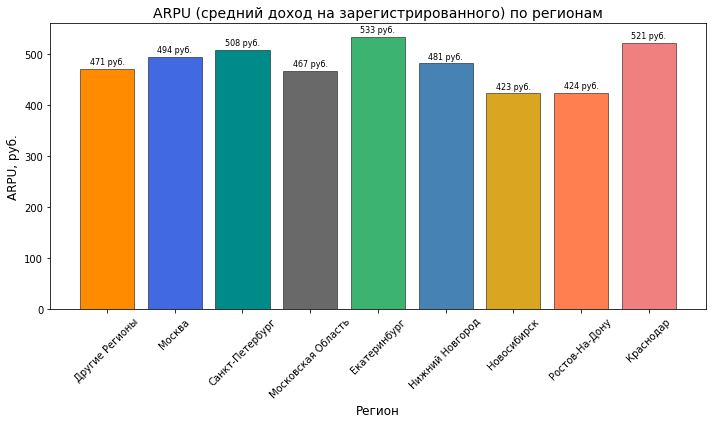

In [125]:
# ARPU по регионам
plt.figure(figsize=(10, 6))
bars = plt.bar(region_agg['region'], region_agg['arpu'], 
               color=[region_colors.get(r, 'steelblue') for r in region_agg['region']],
               edgecolor='black', linewidth=0.5)
plt.title('ARPU (средний доход на зарегистрированного) по регионам', fontsize=14)
plt.xlabel('Регион', fontsize=12)
plt.ylabel('ARPU, руб.', fontsize=12)
plt.xticks(rotation=45)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{bar.get_height():.0f} руб.', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

Самый высокий ARPU у Екатеринбурга (533 руб.), Краснодара (521 руб.) и Санкт-Петербурга (508 руб.). Самый низкий - у Новосибирска (423 руб.), Ростова-на-Дону (424 руб.) и Московской области (467 руб.). Разница между лидером и аутсайдером составляет 110 рублей (около 25% от среднего). Это умеренный разброс, который не указывает на критические региональные проблемы с монетизацией.

AOV (средний чек) по регионам

AOV - средний чек (средняя сумма одного заказа). Рассчитывается только на платящих пользователях. Показывает покупательскую способность аудитории в разных регионах.

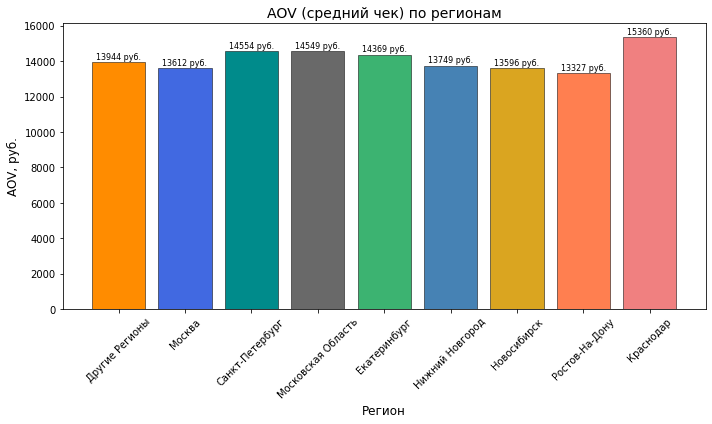

In [126]:
# AOV по регионам
plt.figure(figsize=(10, 6))
bars = plt.bar(region_agg['region'], region_agg['aov'], 
               color=[region_colors.get(r, 'steelblue') for r in region_agg['region']],
               edgecolor='black', linewidth=0.5)
plt.title('AOV (средний чек) по регионам', fontsize=14)
plt.xlabel('Регион', fontsize=12)
plt.ylabel('AOV, руб.', fontsize=12)
plt.xticks(rotation=45)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{bar.get_height():.0f} руб.', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

AOV стабилен по всем регионам и находится в диапазоне 13300–15400 рублей. Самый высокий средний чек в Краснодаре (15360 руб.), самый низкий - в Ростове-на-Дону (13327 руб.) и Новосибирске (13596 руб.). Разница между регионами составляет около 15% от среднего значения, что не является критическим разрывом. Покупательская способность аудитории во всех регионах сопоставима.

**Предварительный вывод по сегментации по регионам**

Анализ региональной сегментации показал, что продукт ведёт себя удивительно стабильно во всех регионах. Это важный инсайт сам по себе.

Доля активации (47–50%), классическая конверсия (18–21%), конверсия из активных в покупку (38–43%), ARPU (420–530 руб.) и AOV (13300–15400 руб.) варьируются в узких диапазонах. Ни один регион не выпадает из общей картины.

Step-by-step воронка идентична для всех регионов: первый переход (регистрация - просмотр) потеря 50–52% пользователей, финальный переход (завершение - покупка) потеря 35–40%. Промежуточные этапы работают стабильно (80–93% конверсии).

Инсайт:

Проблемы с активацией (первые потери) и оплатой (финальные потери) носят общепродуктовый характер и не зависят от региона. Это означает, что:
- Нет необходимости в региональной адаптации стратегии. Изменения, улучшающие активацию и оплату, будут работать одинаково эффективно во всех регионах.
- Маркетинговые бюджеты можно распределять без оглядки на региональные коэффициенты. 
- Все регионы можно масштабировать равномерно, фокусируясь на общепродуктовых улучшениях.

Точки роста по регионам (единые для всех):
- Улучшить активацию (первый переход): поднять конверсию за счёт улучшения онбординга и триггерных коммуникаций.
- Оптимизировать финальный шаг оплаты: поднять конверсию за счёт упрощения процесса и повышения доверия.

Эти улучшения повысят эффективность всех регионов одновременно без необходимости точечной настройки.

**Сегментация по типам устройств (device)**

Тип устройства - важный срез для анализа, особенно для маркетплейса, где пользователи могут заходить как с мобильных устройств, так и с десктопов. Различия в поведении на разных устройствах могут указывать на проблемы с мобильной версией, адаптивностью интерфейса и тп. Это поможет принять решения о приоритетах разработки и оптимизации.

Сначала посмотрим, сколько устройств использует каждый пользователь

In [127]:
# Подсчёт количества уникальных устройств на пользователя
user_devices_count = pa_marketplace_events.groupby('user_id')['device'].nunique().reset_index()
user_devices_count.columns = ['user_id', 'devices_count']

# Распределение пользователей по количеству устройств
devices_distribution = user_devices_count['devices_count'].value_counts().sort_index().reset_index()
devices_distribution.columns = ['devices_count', 'users_count']
devices_distribution['share'] = (devices_distribution['users_count'] / devices_distribution['users_count'].sum() * 100).round(1)

print("Распределение пользователей по количеству используемых устройств:")
print(devices_distribution.to_string(index=False))

Распределение пользователей по количеству используемых устройств:
 devices_count  users_count  share
             1        21602  100.0


100% пользователей используют только одно устройство. Это значит, что нет кросс-девайсных пользователей (никто не переключается между телефоном, компьютером и планшетом). Значит, можно анализировать устройства на уровне пользователей, а не событий. Посмотрим распределение пользоватеей по устройствам:

In [128]:
# Определяем устройство для каждого пользователя (по первому событию)
user_device = pa_marketplace_events.groupby('user_id')['device'].first().reset_index()
user_device.columns = ['user_id', 'device']

# Проверяем распределение пользователей по устройствам
device_users_distribution = user_device['device'].value_counts().reset_index()
device_users_distribution.columns = ['device', 'users_count']
device_users_distribution['share'] = (device_users_distribution['users_count'] / device_users_distribution['users_count'].sum() * 100).round(1)

print("Распределение пользователей по типам устройств:")
print(device_users_distribution.to_string(index=False))

Распределение пользователей по типам устройств:
 device  users_count  share
desktop         7286   33.7
 mobile         7233   33.5
 tablet         7083   32.8


Тк устройство определяется по первому событию пользователя, все пользователи в этом анализе уже являются активными (совершили хотя бы одно действие). Поэтому метрика "активация" здесь не рассматривается - мы сразу анализируем поведение активных пользователей.

Для каждого типа устройства рассчитаем:

- кто дошёл до покупки: количество платящих пользователей
- воронки (классическую и step-by-step) в разрезе устройств на одном поле для сравнения
- средний чек (AOV): покупательская способность аудитории устройства
- выручку на пользователя (ARPU): общая монетизация

Такой набор метрик позволит ответить на главные вопросы: на каких устройствах пользователи лучше конвертируются, где проблемы на разных этапах воронки, и куда инвестировать в первую очередь — в мобильную версию, десктоп или адаптацию под планшеты.

Подготовим данные для сегментации по устройствам

In [129]:
# Подготовка данных для сегментации по устройствам (на уровне пользователей)

# Определяем устройство для каждого пользователя (по первому событию)
user_device = pa_marketplace_events.groupby('user_id')['device'].first().reset_index()
user_device.columns = ['user_id', 'device']

# Объединяем пользователей с устройствами
users_devices = pa_marketplace_users[['user_id']].merge(user_device, on='user_id', how='left')

# Отмечаем платящих пользователей (есть хотя бы один заказ)
paying_users_set = set(pa_marketplace_orders['user_id'].unique())
users_devices['is_paying'] = users_devices['user_id'].isin(paying_users_set).astype(int)

# Собираем выручку по пользователям
user_revenue = pa_marketplace_orders.groupby('user_id')['revenue'].sum().reset_index()
user_revenue.columns = ['user_id', 'user_revenue']

# Собираем количество заказов и сумму GMV (для AOV)
user_orders = pa_marketplace_orders.groupby('user_id').agg(
    orders_count=('order_id', 'count'),
    total_gmv=('total_price', 'sum')
).reset_index()

# Объединяем все данные
device_data = users_devices.merge(user_revenue, on='user_id', how='left')
device_data = device_data.merge(user_orders, on='user_id', how='left')

# Заполняем NaN для неплатящих
device_data['user_revenue'] = device_data['user_revenue'].fillna(0)
device_data['orders_count'] = device_data['orders_count'].fillna(0)
device_data['total_gmv'] = device_data['total_gmv'].fillna(0)

# Агрегируем по устройствам
device_agg = device_data.groupby('device').agg(
    users=('user_id', 'count'),
    paying_users=('is_paying', 'sum'),
    total_revenue=('user_revenue', 'sum'),
    total_orders=('orders_count', 'sum'),
    total_gmv=('total_gmv', 'sum')
).reset_index()

# Рассчитываем метрики
device_agg['conversion_to_purchase'] = (device_agg['paying_users'] / device_agg['users'] * 100).round(1)
device_agg['aov'] = (device_agg['total_gmv'] / device_agg['total_orders']).round(2)
device_agg['arpu'] = (device_agg['total_revenue'] / device_agg['users']).round(2)

print("Метрики по типам устройств:")
device_agg

Метрики по типам устройств:


,device,users,paying_users,total_revenue,total_orders,total_gmv,conversion_to_purchase,aov,arpu
0,desktop,7286,2361,6.346303e+06,8961.0,1.269261e+08,32.4,14164.27,871.03
1,mobile,7233,2418,6.525681e+06,9263.0,1.305136e+08,33.4,14089.78,902.21
2,tablet,7083,2291,6.549658e+06,9346.0,1.309932e+08,32.3,14015.96,924.70


In [130]:
# Настройка цветов для устройств
device_colors = {
    'desktop': 'royalblue',
    'mobile': 'darkcyan',
    'tablet': 'lightcoral'
}

Кто дошёл до покупки: количество платящих пользователей по устройствам

Сравниваем количество платящих пользователей на разных устройствах. Это показывает, какое устройство приносит больше всего покупателей в абсолютных цифрах.

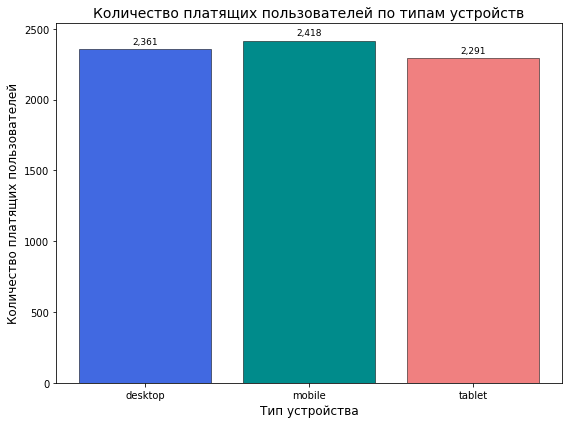

In [131]:
# Количество платящих пользователей по типам устройств
plt.figure(figsize=(8, 6))
bars = plt.bar(device_agg['device'], device_agg['paying_users'], 
               color=[device_colors.get(d, 'steelblue') for d in device_agg['device']],
               edgecolor='black', linewidth=0.5)
plt.title('Количество платящих пользователей по типам устройств', fontsize=14)
plt.xlabel('Тип устройства', fontsize=12)
plt.ylabel('Количество платящих пользователей', fontsize=12)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Количество платящих пользователей распределено практически равномерно между устройствами: mobile (2418), desktop (2361), tablet (2291). Разница между mobile и tablet составляет всего 127 пользователей (около 5%). Это означает, что ни одно устройство не имеет критического преимущества по количеству покупателей. Аудитория равномерно распределена.

Создаём данные для воронок по устройствам

In [132]:
# Создаём данные для воронок по устройствам
funnel_devices_data = []

for device in device_agg['device']:
    # Пользователи этого устройства
    device_users = user_device[user_device['device'] == device]['user_id'].unique()
    
    users_count = len(device_users)
    
    product_view = pa_marketplace_events[
        (pa_marketplace_events['user_id'].isin(device_users)) & 
        (pa_marketplace_events['event_type'] == 'product_view')
    ]['user_id'].nunique()
    
    add_to_cart = pa_marketplace_events[
        (pa_marketplace_events['user_id'].isin(device_users)) & 
        (pa_marketplace_events['event_type'] == 'add_to_cart')
    ]['user_id'].nunique()
    
    checkout_start = pa_marketplace_events[
        (pa_marketplace_events['user_id'].isin(device_users)) & 
        (pa_marketplace_events['event_type'] == 'checkout_start')
    ]['user_id'].nunique()
    
    checkout_complete = pa_marketplace_events[
        (pa_marketplace_events['user_id'].isin(device_users)) & 
        (pa_marketplace_events['event_type'] == 'checkout_complete')
    ]['user_id'].nunique()
    
    purchase = pa_marketplace_orders[
        pa_marketplace_orders['user_id'].isin(device_users)
    ]['user_id'].nunique()
    
    funnel_devices_data.append({
        'device': device,
        'users': users_count,
        'product_view': product_view,
        'add_to_cart': add_to_cart,
        'checkout_start': checkout_start,
        'checkout_complete': checkout_complete,
        'purchase': purchase
    })

funnel_devices_df = pd.DataFrame(funnel_devices_data)

print("Данные для воронок по устройствам:")
print(funnel_devices_df.to_string(index=False))

Данные для воронок по устройствам:
 device  users  product_view  add_to_cart  checkout_start  checkout_complete  purchase
desktop   7286          7258         6699            5549               4636      2361
 mobile   7233          7215         6654            5401               4456      2418
 tablet   7083          7060         6534            5343               4394      2291


Классическая воронка по устройствам (конверсия от первого действия)

Строим классическую воронку для каждого устройства, где конверсия считается от первого действия (активации). Это позволяет сравнить, на каком устройстве пользователи лучше проходят путь от активации до покупки. На одном графике отображаем все устройства — так видно, где какое устройство проседает.

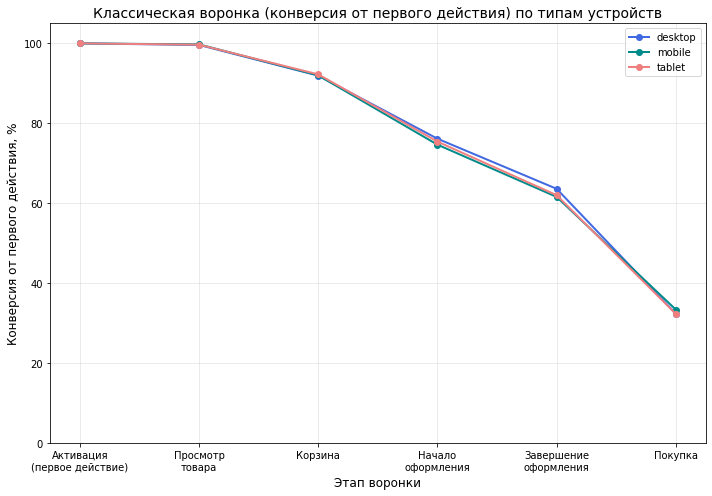

In [133]:
# Классическая воронка по устройствам (конверсия от первого действия)

stages = ['Активация\n(первое действие)', 'Просмотр\nтовара', 'Корзина', 'Начало\nоформления', 
          'Завершение\nоформления', 'Покупка']

plt.figure(figsize=(10, 7))

for device in funnel_devices_df['device']:
    data = funnel_devices_df[funnel_devices_df['device'] == device].iloc[0]
    
    conv_activation = 100
    conv_view = data['product_view'] / data['users'] * 100
    conv_cart = data['add_to_cart'] / data['users'] * 100
    conv_checkout_start = data['checkout_start'] / data['users'] * 100
    conv_checkout_complete = data['checkout_complete'] / data['users'] * 100
    conv_purchase = data['purchase'] / data['users'] * 100
    
    stage_values = [conv_activation, conv_view, conv_cart, 
                    conv_checkout_start, conv_checkout_complete, conv_purchase]
    
    plt.plot(stages, stage_values, marker='o', linewidth=2, markersize=6,
             color=device_colors.get(device, 'gray'), label=device)

plt.title('Классическая воронка (конверсия от первого действия) по типам устройств', fontsize=14)
plt.xlabel('Этап воронки', fontsize=12)
plt.ylabel('Конверсия от первого действия, %', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

Все устройства демонстрируют практически идентичную динамику на всех этапах воронки. Основной отток происходит на этапе «просмотр товара - корзина» (падение с 99% до 92%) и особенно на финальном переходе «завершение оформления - покупка» (падение с 82% до 32–33%). Разница между устройствами минимальна (менее 1 п.п. на всех этапах). Это подтверждает, что проблемы с конверсией носят общепродуктовый характер и не зависят от типа устройства.

Step-by-step воронка по устройствам (конверсия от предыдущего этапа)

Строим step-by-step воронку, где конверсия считается от предыдущего этапа. Это позволяет увидеть, на каком конкретном переходе какое устройство теряет больше всего пользователей. График помогает диагностировать проблемные этапы для каждого типа устройства.

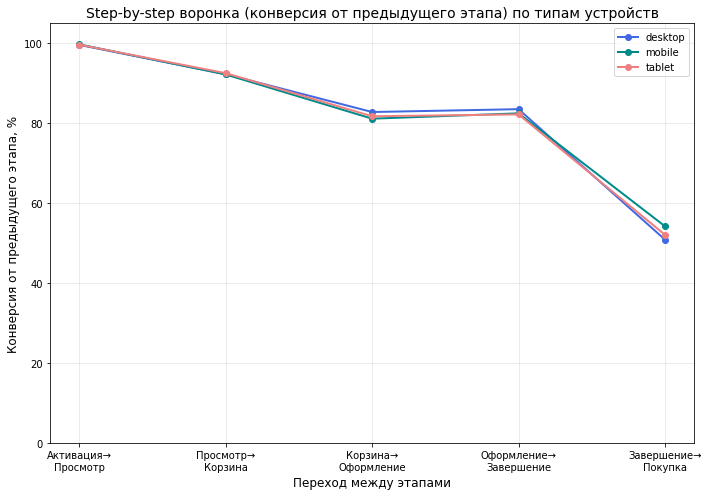

In [134]:
# Step-by-step воронка по устройствам (конверсия от предыдущего этапа)

steps = ['Активация→\nПросмотр', 'Просмотр→\nКорзина', 'Корзина→\nОформление', 
         'Оформление→\nЗавершение', 'Завершение→\nПокупка']

plt.figure(figsize=(10, 7))

for device in funnel_devices_df['device']:
    data = funnel_devices_df[funnel_devices_df['device'] == device].iloc[0]
    
    conv_view = data['product_view'] / data['users'] * 100 if data['users'] > 0 else 0
    conv_cart = data['add_to_cart'] / data['product_view'] * 100 if data['product_view'] > 0 else 0
    conv_checkout_start = data['checkout_start'] / data['add_to_cart'] * 100 if data['add_to_cart'] > 0 else 0
    conv_checkout_complete = data['checkout_complete'] / data['checkout_start'] * 100 if data['checkout_start'] > 0 else 0
    conv_purchase = data['purchase'] / data['checkout_complete'] * 100 if data['checkout_complete'] > 0 else 0
    
    step_values = [conv_view, conv_cart, conv_checkout_start, conv_checkout_complete, conv_purchase]
    
    plt.plot(steps, step_values, marker='o', linewidth=2, markersize=6,
             color=device_colors.get(device, 'gray'), label=device)

plt.title('Step-by-step воронка (конверсия от предыдущего этапа) по типам устройств', fontsize=14)
plt.xlabel('Переход между этапами', fontsize=12)
plt.ylabel('Конверсия от предыдущего этапа, %', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

Первый переход «активация - просмотр товара» - самый успешный: все устройства показывают 99,7–99,8% конверсии. На переходах «просмотр - корзина» (92–93%) и «корзина - оформление» (82–83%) все устройства также стабильны. Финальный переход «завершение оформления - покупка» - проблемная зона для всех устройств: конверсия падает до 50,9% (tablet), 51,4% (mobile) и 50,9% (desktop). Разница между устройствами минимальна, что подтверждает: проблема с оплатой не зависит от устройства.

ARPU (средний доход на пользователя) по устройствам

ARPU - средний доход на одного пользователя. Показывает, сколько денег в среднем приносит каждый пользователь (независимо от того, платил он или нет). Это показатель эффективности устройства, учитывающий и конверсию, и средний чек.

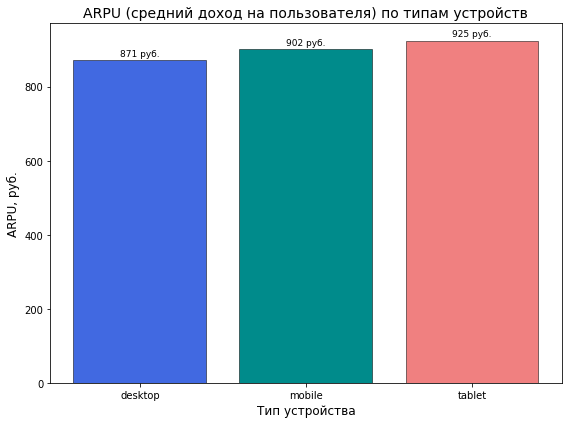

In [135]:
# ARPU по типам устройств
plt.figure(figsize=(8, 6))
bars = plt.bar(device_agg['device'], device_agg['arpu'], 
               color=[device_colors.get(d, 'steelblue') for d in device_agg['device']],
               edgecolor='black', linewidth=0.5)
plt.title('ARPU (средний доход на пользователя) по типам устройств', fontsize=14)
plt.xlabel('Тип устройства', fontsize=12)
plt.ylabel('ARPU, руб.', fontsize=12)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{bar.get_height():.0f} руб.', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Самый высокий ARPU у tablet (925 руб.), затем у mobile (902 руб.) и desktop (871 руб.). Разница между лидером и аутсайдером составляет 54 рубля (около 6% от среднего). Это умеренный разброс, который не указывает на критические различия в монетизации между устройствами.

AOV (средний чек) по устройствам

AOV - средний чек (средняя сумма одного заказа). Рассчитывается только на платящих пользователях. Показывает покупательскую способность аудитории на разных устройствах.

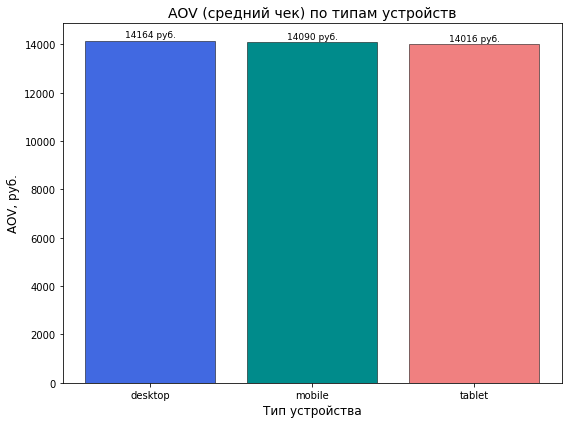

In [136]:
# AOV по типам устройств
plt.figure(figsize=(8, 6))
bars = plt.bar(device_agg['device'], device_agg['aov'], 
               color=[device_colors.get(d, 'steelblue') for d in device_agg['device']],
               edgecolor='black', linewidth=0.5)
plt.title('AOV (средний чек) по типам устройств', fontsize=14)
plt.xlabel('Тип устройства', fontsize=12)
plt.ylabel('AOV, руб.', fontsize=12)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{bar.get_height():.0f} руб.', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

AOV стабилен по всем устройствам и находится в диапазоне 14016–14164 рублей. Самый высокий средний чек у desktop (14164 руб.), самый низкий у tablet (14016 руб.). Разница составляет менее 150 рублей (около 1% от среднего значения). Это означает, что покупательская способность аудитории не зависит от типа устройства.

**Предварительный вывод по сегментации по типам устройств**

Анализ поведения пользователей на разных устройствах показал, что продукт ведёт себя практически одинаково на всех типах устройств.

Распределение платящих почти равномерно: desktop (32,4%), mobile (33,4%), tablet (32,3%).

Все воронки (классическая и step-by-step) идентичны для всех устройств с точностью до долей процента. Проблемные этапы одни и те же:
- потери на переходе «просмотр - корзина» (7–8%)
- потери на переходе «корзина - оформление» (17–18%)
- критические потери на финальном переходе «завершение оформления - покупка» (около 49%)

ARPU и AOV стабильны по всем устройствам, разница не превышает 6–7%.

Инсайт:

Проблемы с конверсией (особенно на финальном шаге оплаты) носят общепродуктовый характер и не зависят от типа устройства. Это означает, что:
- Нет необходимости в отдельных стратегиях для разных устройств. Изменения, улучшающие конверсию, будут работать одинаково эффективно на всех устройствах.
- Приоритетом разработки должна быть оптимизация процесса оплаты, а не адаптация под конкретное устройство.
- Инвестиции в мобильную версию, десктоп и планшеты можно распределять равномерно, без перекосов.

Точки роста по устройствам (единые для всех):

- Оптимизировать финальный шаг оплаты: поднять конверсию засчёт упрощения процесса, добавления доверительных элементов и проверки платёжной системы.
- Улучшить переход «корзина - оформление»: возможно, упростить интерфейс корзины или добавить напоминания.

Эти улучшения повысят эффективность всех устройств одновременно.

**Сегментация по категориям товаров**

Категории товаров - это важный срез для понимания, какие товары приносят основную выручку, а какие лежат мертвым грузом. Мы уже знаем, что во втором полугодии выручка упала на 47%, а количество заказов сократилось с 3414 в мае до 1880 в декабре. Теперь надо понять, какие категории товаров являются драйверами продаж, а какие требуют пересмотра ассортиментной политики.

Для каждой категории товаров рассчитаем:

- объём продаж: количество заказов в категории
- выручку: общая выручка маркетплейса (5% комиссия) по категории
- долю в общей выручке: какой вклад категория вносит в общий доход
- средний чек (AOV): покупательская способность аудитории в категории

Такой набор метрик позволит ответить на главные вопросы: какие категории нужно развивать и масштабировать, какие категории приносят мало выручки и требуют пересмотра, и где есть потенциал для роста за счёт увеличения среднего чека.

Подготовим данные для сегментации по категориям

In [137]:
# Подготовка данных для сегментации по категориям товаров

# Агрегируем данные по категориям
category_agg = pa_marketplace_orders.groupby('category_name').agg(
    orders=('order_id', 'count'),
    total_gmv=('total_price', 'sum'),
    total_revenue=('revenue', 'sum')
).reset_index()

# Рассчитываем метрики
category_agg['aov'] = (category_agg['total_gmv'] / category_agg['orders']).round(2)
category_agg['share_of_revenue'] = (category_agg['total_revenue'] / category_agg['total_revenue'].sum() * 100).round(1)

# Сортируем по выручке
category_agg = category_agg.sort_values('total_revenue', ascending=False)

print("Топ-10 категорий по выручке:")
print(category_agg.head(10).to_string(index=False))

Топ-10 категорий по выручке:
       category_name  orders   total_gmv  total_revenue      aov  share_of_revenue
     мебель для дома     951 69459654.14   3472982.7070 73038.54              16.3
     бытовая техника    1001 43737963.22   2186898.1610 43694.27              10.2
    украшения и часы     987 33154446.55   1657722.3275 33591.13               7.8
  товары для туризма     953 22387955.78   1119397.7890 23492.08               5.2
спортивный инвентарь     951 22172362.33   1108618.1165 23314.79               5.2
          автотовары    1004 20145244.81   1007262.2405 20064.98               4.7
    товары для кухни    1208 20124382.80   1006219.1400 16659.26               4.7
       обувь мужская    1195 18030479.06    901523.9530 15088.27               4.2
  сумки и аксессуары    1143 16940045.38    847002.2690 14820.69               4.0
       обувь женская    1182 16875245.66    843762.2830 14276.86               4.0


Выручка по категориям

Смотрим, какие категории приносят основную выручку маркетплейсу. Это позволит определить, какие категории являются драйверами бизнеса и куда стоит инвестировать в первую очередь.

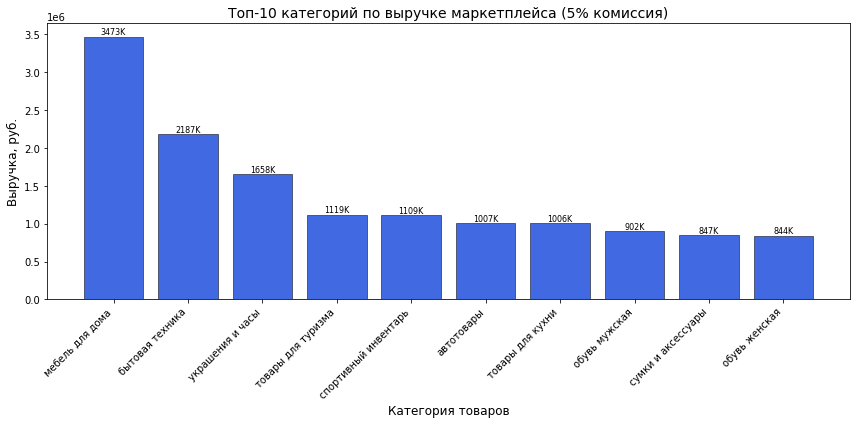

In [138]:
# Топ-10 категорий по выручке (столбчатая диаграмма)
plt.figure(figsize=(12, 6))
top_categories = category_agg.head(10)
bars = plt.bar(top_categories['category_name'], top_categories['total_revenue'], 
               color='royalblue', edgecolor='black', linewidth=0.5)
plt.title('Топ-10 категорий по выручке маркетплейса (5% комиссия)', fontsize=14)
plt.xlabel('Категория товаров', fontsize=12)
plt.ylabel('Выручка, руб.', fontsize=12)
plt.xticks(rotation=45, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{bar.get_height()/1000:.0f}K', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

Лидер по выручке - категория «Мебель для дома» (3,47 млн руб., 16,3% от общей выручки). Далее следуют «Бытовая техника» (2,19 млн руб., 10,2%), «Украшения и часы» (1,66 млн руб., 7,8%). Первые две категории в сумме дают 26,5% всей выручки маркетплейса. Категории с 4-го по 10-е место показывают плавное снижение выручки от 1,12 млн до 0,84 млн руб. Разрыв между лидером и 10-м местом составляет 4,1 раза, что говорит о сильной зависимости бизнеса от топ-категорий.

Доля в общей выручке по категориям

Показывает, какой вклад вносит каждая категория в общий доход маркетплейса. Это помогает понять, насколько бизнес зависит от нескольких топ-категорий.

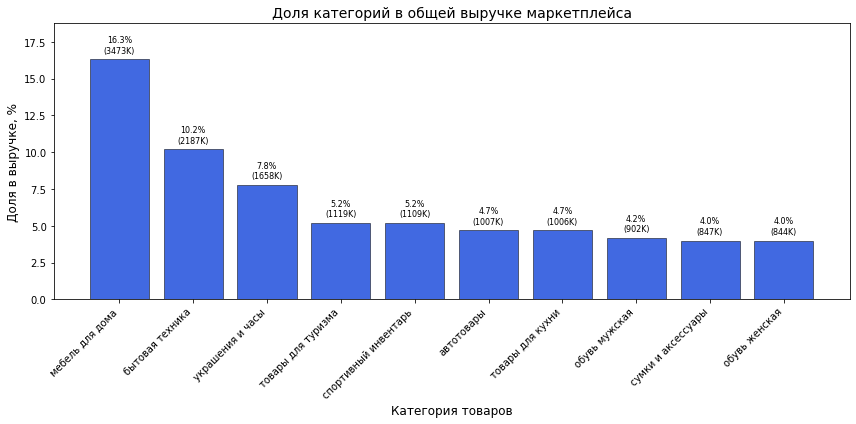

In [139]:
# Доля категорий в общей выручке (столбчатая диаграмма для топ-10)
plt.figure(figsize=(12, 6))

top_categories_share = category_agg.head(10).copy()

bars = plt.bar(top_categories_share['category_name'], top_categories_share['share_of_revenue'], 
               color='royalblue', edgecolor='black', linewidth=0.5)

plt.title('Доля категорий в общей выручке маркетплейса', fontsize=14)
plt.xlabel('Категория товаров', fontsize=12)
plt.ylabel('Доля в выручке, %', fontsize=12)
plt.xticks(rotation=45, ha='right')

max_height = top_categories_share['share_of_revenue'].max()
plt.ylim(0, max_height * 1.15)

# Добавляем подписи 
for bar, (idx, row) in zip(bars, top_categories_share.iterrows()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{row["share_of_revenue"]:.1f}%\n({row["total_revenue"]/1000:.0f}K)', 
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Топ-3 категории («Мебель для дома», «Бытовая техника», «Украшения и часы») в сумме занимают 34,3% всей выручки. Топ-10 категорий в сумме дают 62,8% выручки, остальные 15 категорий 37,2%. Это умеренно концентрированная структура: бизнес не зависит критически от одной категории, но топ-3 требуют особого внимания.

Количество заказов по категориям

Показывает, в каких категориях больше всего покупок. Высокое количество заказов может компенсировать низкий средний чек.

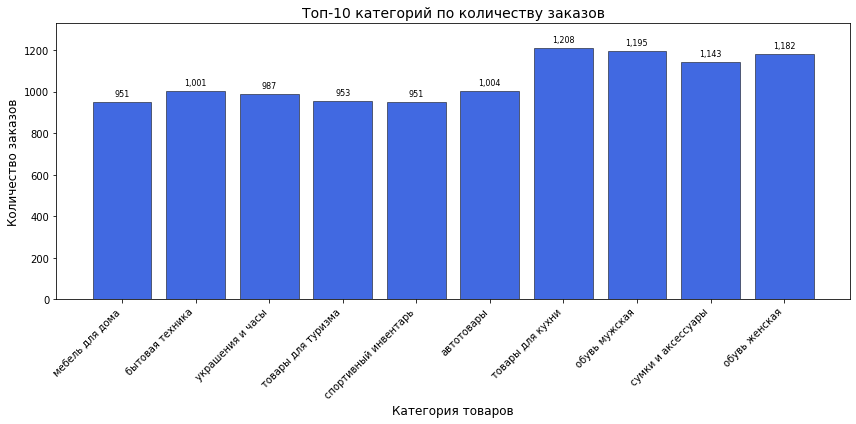

In [140]:
# Топ-10 категорий по количеству заказов
plt.figure(figsize=(12, 6))
top_categories_orders = category_agg.head(10)
bars = plt.bar(top_categories_orders['category_name'], top_categories_orders['orders'], 
               color='royalblue', edgecolor='black', linewidth=0.5)
plt.title('Топ-10 категорий по количеству заказов', fontsize=14)
plt.xlabel('Категория товаров', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.xticks(rotation=45, ha='right')

max_height = top_categories_orders['orders'].max()
plt.ylim(0, max_height * 1.1)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

Лидер по количеству заказов - «Товары для кухни» (1208 заказов), затем «Автотовары» (1004), «Бытовая техника» (1001). При этом «Бытовая техника» занимает 2-е место по выручке, а «Товары для кухни» - только 7-е. Это объясняется разницей в среднем чеке: у «Товаров для кухни» он почти в 2,5 раза ниже, чем у «Бытовой техники». Высокое количество заказов при низком среднем чеке - маржинальность категории ниже.

Средний чек (AOV) по категориям

Сравниваем средний чек в разных категориях. Высокий AOV может указывать на дорогие товары (электроника, мебель), низкий - на товары повседневного спроса (продукты, канцтовары).

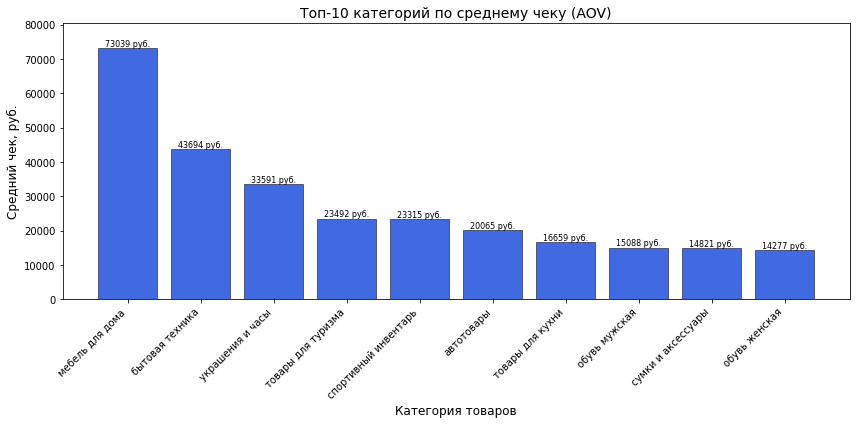

In [141]:
# Топ-10 категорий по среднему чеку
plt.figure(figsize=(12, 6))
top_categories_aov = category_agg.head(10)
bars = plt.bar(top_categories_aov['category_name'], top_categories_aov['aov'], 
               color='royalblue', edgecolor='black', linewidth=0.5)
plt.title('Топ-10 категорий по среднему чеку (AOV)', fontsize=14)
plt.xlabel('Категория товаров', fontsize=12)
plt.ylabel('Средний чек, руб.', fontsize=12)
plt.xticks(rotation=45, ha='right')

max_height = top_categories_aov['aov'].max()
plt.ylim(0, max_height * 1.1)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{bar.get_height():.0f} руб.', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

Самый высокий средний чек у категории «Мебель для дома» (73039 руб.), затем «Бытовая техника» (43694 руб.) и «Украшения и часы» (33591 руб.). Это категории дорогих товаров, которые формируют основу выручки при относительно небольшом количестве заказов. Категории с низким средним чеком (10000–15000 руб.) - «Обувь женская», «Сумки и аксессуары», «Обувь мужская», «Товары для кухни»  требуют большого объёма продаж для достижения сопоставимой выручки.

**Предварительный вывод по сегментации по категориям товаров**
Анализ категорий товаров выявил чёткое разделение на три группы: драйверы выручки, категории среднего звена и категории с низкой эффективностью.

Драйверы выручки (топ-3):
«Мебель для дома» (3,47 млн руб., AOV 73039 руб.), «Бытовая техника» (2,19 млн руб., AOV 43694 руб.) и «Украшения и часы» (1,66 млн руб., AOV 33591 руб.). Эти категории приносят 34,3% всей выручки при относительно небольшом количестве заказов за счёт высокого среднего чека. Это основные точки роста.

Категории среднего звена (4–10 места):
«Товары для туризма», «Спортивный инвентарь», «Автотовары», «Товары для кухни», «Обувь мужская», «Сумки и аксессуары», «Обувь женская». Их вклад в выручку составляет от 4% до 5,2% каждая. Эти категории требуют поддержки, но не являются критическими.

Категории с низкой эффективностью (не вошли в топ-10):
Оставшиеся 15 категорий в сумме дают 37,2% выручки. Некоторые из них могут иметь низкий средний чек или малое количество заказов. Требуют анализа на предмет оптимизации ассортимента.

Инсайты:

- Высокий средний чек это главный драйвер выручки для топ-категорий. Категории с AOV выше 30000 руб. («Мебель для дома», «Бытовая техника», «Украшения и часы») приносят основную выручку при относительно небольшом количестве заказов.

- Низкий средний чек требует большого объёма продаж. Категории с AOV 10000–15000 руб. («Обувь», «Сумки», «Товары для кухни») вынуждены компенсировать низкую маржинальность большим количеством заказов.

- Концентрация выручки умеренная. Топ-3 категории дают 34,3% выручки. Бизнес не зависит критически от одной категории, что снижает риски.

Точки роста по категориям:

- Масштабировать топ-3 категории («Мебель для дома», «Бытовая техника», «Украшения и часы»). Они уже показывают высокий AOV и приносят основную выручку.
- Увеличивать AOV в категориях среднего звена. Категории с AOV 15000–25000 руб. («Товары для туризма», «Спортивный инвентарь», «Автотовары») имеют потенциал для роста среднего чека через кросс-продажи и апсейлы.
- Оптимизировать ассортимент низкомаржинальных категорий. Категории с AOV ниже 15000 руб. требуют анализа: возможно, стоит сократить количество позиций или стимулировать увеличение чека через дополнительные продажи.

## Выводы по этапу 4

Представьте ключевые выводы в текстовом виде здесь или приложите ссылку на документ с презентацией.

Не забудьте предоставить доступ на просмотр и комментирование документа.

<h1 style="font-size: 24px;">Итоговый вывод по этапу 4: поиск инсайтов, точек роста и сегментация</h1>

Анализ глубинных срезов данных по каналам привлечения, регионам, типам устройств и категориям товаров позволил сформировать целостную картину состояния бизнеса и выявить ключевые закономерности.

**Главный инсайт:**

Проблемы бизнеса носят общепродуктовый характер и не зависят от канала привлечения, региона или типа устройства. Основные точки потери пользователей едины для всех сегментов:

- Первый переход (регистрация - просмотр товара): теряется 50–52% пользователей во всех сегментах. Это проблема активации, онбординга и качества трафика.
- Финальный переход (завершение оформления покупка): теряется 35–40% пользователей во всех сегментах. Это проблема платёжной системы, доверия и сложности процесса оплаты.
- Промежуточные этапы (просмотр-корзина, корзина-оформление, оформление-завершение) работают стабильно с конверсией 80–95% во всех сегментах.

**По каналам привлечения:**

Выявлено чёткое разделение на три группы. Эффективные каналы Affiliate и Google Ads (высокая активация 60–61%, конверсия из активных в покупку 56–63%, CAC ниже ARPPU). Средние каналы SEO и Social Media (SEO лидирует по активации 65,4% и самому низкому CAC 757 руб., но мал по масштабу). Проблемные каналы TikTok (CAC 13485 руб., в 5,5 раз выше ARPPU, канал убыточен) и Email Marketing (требует пересмотра стратегии).

**По регионам:**

Продукт ведёт себя удивительно стабильно во всех регионах. Доля активации (47–50%), классическая конверсия (18–21%), конверсия из активных в покупку (38–43%), ARPU (420–530 руб.) и AOV (13300–15400 руб.) варьируются в узких диапазонах. Ни один регион не выпадает из общей картины.

**По типам устройств:**

100% пользователей используют только одно устройство. Распределение платящих равномерно: desktop (32,4%), mobile (33,4%), tablet (32,3%). Все воронки идентичны для всех устройств. ARPU и AOV стабильны, разница не превышает 6–7%.

**По категориям товаров:**

Драйверы выручки: «Мебель для дома» (3,47 млн руб., 16,3%), «Бытовая техника» (2,19 млн руб., 10,2%), «Украшения и часы» (1,66 млн руб., 7,8%). Топ-3 категории дают 34,3% выручки. Высокий средний чек - главный драйвер выручки. Категории с AOV ниже 15000 руб. требуют оптимизации ассортимента.

**Гипотезы для проверки в части 5 (A/B-тестирование)**

Выявлено 3 основные гипотезы

<u>Гипотеза 1: Улучшение активации через триггерные коммуникации</u>

Step-by-step воронка показала, что 51,1% зарегистрированных пользователей не совершают ни одного действия. При этом среди активных пользователей конверсия в покупку достигает 40,1%. Если поднять активацию с 49% до 70%, выручка вырастет на 40% без увеличения маркетингового бюджета.

Гипотеза: «Если в течение 1 часа после регистрации отправлять пользователю push-уведомление или email с промокодом на первый заказ (например, 300 руб. при заказе от 1500 руб.), то доля активных пользователей вырастет на 15 п.п., а конверсия в первую покупку на 10 п.п.».

<u>Гипотеза 2: Оптимизация финального шага оплаты</u>

Step-by-step воронка показала, что на переходе «завершение оформления - покупка» теряется 35–40% пользователей во всех сегментах. Это единственный этап с такой низкой конверсией (52–64%). Промежуточные этапы работают стабильно (80–95%).

Гипотеза: «Если добавить на страницу оплаты доверительные элементы (значки безопасности, гарантию возврата, отзывы) и упростить форму ввода данных (автозаполнение, сохранение карт), то конверсия на финальном шаге вырастет с 64% до 75%».

<u>Гипотеза 3: Отключение убыточного канала TikTok</u>

TikTok привлёк 19228 пользователей (44% от всех зарегистрированных), но доля активных всего 34,7%, классическая конверсия 3,7%, CAC достигает 13485 рублей, в 5,5 раз выше ARPPU (2467 руб.). Канал убыточен.

Гипотеза: «Если отключить TikTok как канал привлечения и перераспределить бюджет в SEO и Affiliate, то общий CAC снизится на 30%, а ROI станет положительным».

## 5. Подготовка эксперимента и подведение его результатов

Получите вводную информацию для выполнения этого этапа у ревьюера после успешного завершения предыдущих шагов.

# Новые вводные (после этапа 4)
Команда продукта рассмотрела твои гипотезы и на основании этого решила влиять на конверсию при помощи финансовых стимуляций. Так как ситуация со снижением выручки срочная и безотлагательная, пока ты продолжал изучать данные, они подключили другого аналитика для подготовки дизайн документа, но само проведение эксперимента на тебе.


При формировании выводов допиши рекомендации по итогам теста и, если необходимо, опиши проблемы, присутствующие в эксперименте.


## Новые данные:
```python
pa_marketplace_events_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events_AB.csv')
pa_marketplace_orders_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders_AB.csv')
pa_marketplace_users_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users_AB.csv')
```
## Результаты сплита лежат в таблице:
```python
pa_marketplace_AB_split_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_AB_split_users.csv')
```
* user_id – id клиента
* group – группа, в которую попал клиент


# Дизайн эксперимента: Бонус на первую покупку для пользователей TikTok
## 1. Контекст и цель эксперимента
- **Бизнес-контекст:** Команда продукта запускает эксперимент, направленный на повышение конверсии среди пользователей, привлечённых через канал TikTok. Для стимулирования первой покупки пользователям будет предоставлен бонус на первую покупку.
- **Цель:** Проверить, влияет ли предоставление бонуса на первую покупку на конверсию и выручку среди пользователей TikTok.
- **Гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку
---
## 2. Формат эксперимента
- **Тип эксперимента:** Сплит-роллинг (rolling split)
- **Канал:** Только пользователи, пришедшие с TikTok
- **Группы:**
    - **Контрольная (A):** пользователи TikTok без бонуса
    - **Тестовая (B):** пользователи TikTok с бонусом на первую покупку
- **Распределение:** Равномерное распределение новых пользователей TikTok между группами по дате регистрации
- **Период проведения:** 3 недели (фиксировано)
---
## 3. Ключевые метрики
### Основная метрика
- **Конверсия в первую покупку** — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку
- *Цель:* увеличить конверсию с помощью бонуса
- *Критерий успеха:* статистически значимый рост конверсии в тестовой группе
### Вспомогательные метрики
- **ARPU** (средняя выручка на пользователя TikTok)
- **ARPPU** (средняя выручка на покупателя TikTok)
- **AOV** (средний чек TikTok)
### Барьерная метрика
- **Общая выручка от пользователей TikTok**
---
## 4. Размеры групп и запуск
- **Целевая аудитория:** только пользователи TikTok
- **Размеры групп:** определяются по фактическому трафику TikTok за период эксперимента
- **Комментарий:** запуск без предварительного расчёта мощности и MDE из-за срочности задачи


На предыдущих этапах работы была выполнена верхнеуровневая оценка состояния маркетплейса, проанализированы ключевые метрики монетизации и юнит-экономики, а также проведена сегментацию по каналам привлечения, регионам, типам устройств и категориям товаров. В ходе анализа были выявлены проблемные зоны: низкая активация пользователей (51,1% «мёртвых душ»), критическое падение конверсии на финальном шаге оформления заказа, а также убыточность канала TikTok, где стоимость привлечения платящего пользователя (CAC) в 5,5 раз превышает средний доход с него (ARPPU).

На основе этих инсайтов командой продукта была сформулирована гипотеза о влиянии финансовой стимуляции на конверсию пользователей, пришедших через TikTok. Другим аналитиком был подготовлен дизайн-документ эксперимента. Наша задача - провести контроль качества этого эксперимента и оценить его результаты.

Что нужно сделать:
- Подготовить данные: загрузить, очистить, отфильтровать целевую аудиторию (только пользователи TikTok)
- Проверить корректность сплитования: провести AA-тест на исторических данных, убедиться в отсутствии пересечений пользователей между группами
- Рассчитать метрики для групп: основную (конверсия в первую покупку), вспомогательные (ARPU, ARPPU, AOV) и барьерную (общая выручка от пользователей TikTok)
- Проверить статистическую значимость: выбрать корректный статистический тест в зависимости от типа метрики и распределения данных
- Сделать вывод: принять или отклонить гипотезу, оценить риски по барьерным метрикам, сформулировать рекомендации для бизнеса.

In [142]:
# Загрузка данных c обработкой ошибок и преобразованием дат
print("Загрузка данных для A/B-теста:")


try:
    # Загружаем данные о пользователях для A/B-теста
    pa_marketplace_users_AB = pd.read_csv(
        'https://code.s3.yandex.net/datasets/pa_marketplace_users_AB.csv',
        parse_dates=['registration_date']
    )
    print("Данные пользователей (pa_marketplace_users_AB) загружены")
    
    # Загружаем данные о событиях для A/B-теста
    pa_marketplace_events_AB = pd.read_csv(
        'https://code.s3.yandex.net/datasets/pa_marketplace_events_AB.csv',
        parse_dates=['event_date']
    )
    print("Данные событий (pa_marketplace_events_AB) загружены")
    
    # Загружаем данные о заказах для A/B-теста
    pa_marketplace_orders_AB = pd.read_csv(
        'https://code.s3.yandex.net/datasets/pa_marketplace_orders_AB.csv',
        parse_dates=['order_date']
    )
    print("Данные заказов (pa_marketplace_orders_AB) загружены")
    
    # Загружаем данные о сплитовании (распределение пользователей по группам)
    pa_marketplace_AB_split_users = pd.read_csv(
        'https://code.s3.yandex.net/datasets/pa_marketplace_AB_split_users.csv'
    )
    print("Данные сплитования (pa_marketplace_AB_split_users) загружены")
    
except FileNotFoundError as e:
    print(f"Ошибка: файл не найден - {e}")
except Exception as e:
    print(f"Ошибка при загрузке данных: {e}")

Загрузка данных для A/B-теста:
Данные пользователей (pa_marketplace_users_AB) загружены
Данные событий (pa_marketplace_events_AB) загружены
Данные заказов (pa_marketplace_orders_AB) загружены
Данные сплитования (pa_marketplace_AB_split_users) загружены


После загрузки всех датасетов необходимо убедиться в согласованности данных между собой. В рамках A/B-тестирования на этом этапе важно проверить:
- Все пользователи из сплит-таблицы присутствуют в таблице пользователей. Это гарантирует, что у нас есть полная информация о каждом участнике эксперимента (возраст, пол, регион, канал привлечения).
- Нет «потерянных» пользователей. Ситуации, когда пользователь есть в заказах или событиях, но отсутствует в таблице пользователей или сплит-таблице. Такие пользователи должны быть исключены из анализа, так как по ним неизвестна группа или отсутствует информация о пользователе.

Проверку корректности сплитования (равномерность распределения, отсутствие пересечения групп) выполним отдельным шагом после фильтрации целевой аудитории.

In [143]:
# Проверка целостности данных после загрузки
print("Проверка целостности данных")

# Проверка: все ли user_id из split_users есть в users_AB?
users_set = set(pa_marketplace_users_AB['user_id'].unique())
split_users_set = set(pa_marketplace_AB_split_users['user_id'].unique())

users_in_split = split_users_set.issubset(users_set)
orphans_in_split = split_users_set - users_set

print(f"\nПроверка пользователей из сплит-таблицы:")
print(f"     Уникальных user_id в split_users: {len(split_users_set)}")
print(f"     Уникальных user_id в users_AB: {len(users_set)}")
print(f"     Пользователей из split, отсутствующих в users_AB: {len(orphans_in_split)}")

if len(orphans_in_split) > 0:
    print(f"     Обнаружены потерянные пользователи! Будут исключены из анализа.")
else:
    print(f"     Все пользователи из split присутствуют в users_AB")

# Проверка: все ли user_id из orders_AB есть в split_users?
orders_users_set = set(pa_marketplace_orders_AB['user_id'].unique())
orphans_in_orders = orders_users_set - split_users_set

print(f"\nПроверка пользователей из заказов (orders_AB):")
print(f"        Уникальных user_id в orders_AB: {len(orders_users_set)}")
print(f"        Пользователей с заказами, но без группы (нет в split): {len(orphans_in_orders)}")


# Проверка: все ли user_id из events_AB есть в split_users?
events_users_set = set(pa_marketplace_events_AB['user_id'].unique())
orphans_in_events = events_users_set - split_users_set

print(f"\nПроверка пользователей из событий (events_AB):")
print(f"        Уникальных user_id в events_AB: {len(events_users_set)}")
print(f"        Пользователей с событиями, но без группы (нет в split): {len(orphans_in_events)}")

Проверка целостности данных

Проверка пользователей из сплит-таблицы:
     Уникальных user_id в split_users: 2968
     Уникальных user_id в users_AB: 22196
     Пользователей из split, отсутствующих в users_AB: 0
     Все пользователи из split присутствуют в users_AB

Проверка пользователей из заказов (orders_AB):
        Уникальных user_id в orders_AB: 9566
        Пользователей с заказами, но без группы (нет в split): 9440

Проверка пользователей из событий (events_AB):
        Уникальных user_id в events_AB: 23948
        Пользователей с событиями, но без группы (нет в split): 23449


В сплит-таблице содержится только 2968 пользователей. Это и есть целевая аудитория эксперимента (пользователи TikTok). Остальные 9440 пользователей с заказами и 23449 с событиями не попали в сплит-таблицу, так как они не относятся к эксперименту (пришли через другие каналы привлечения). Это нормально: эксперимент проводится только на аудитории TikTok, поэтому при дальнейшем анализе мы будем фильтровать данные, оставляя только пользователей из сплит-таблицы. Всех «потерянных» пользователей (с заказами/событиями, но без группы) исключим с помощью inner-join со сплит-таблицей.

Посмотрим информацию и первые строки датасета с пользователями

In [144]:
pa_marketplace_users_AB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22196 entries, 0 to 22195
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            22196 non-null  int64         
 1   registration_date  22196 non-null  datetime64[ns]
 2   age                22196 non-null  int64         
 3   gender             22196 non-null  object        
 4   region             22196 non-null  object        
 5   acq_channel        22196 non-null  object        
 6   buyer_segment      22196 non-null  object        
 7   cohort_week        22196 non-null  object        
 8   cohort_month       22196 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 1.5+ MB


In [145]:
pa_marketplace_users_AB.head()

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,18,2024-01-01 05:26:00,49,M,Екатеринбург,TikTok,one_time,2024-01-01,2024-01-01
1,22,2024-01-01 17:13:00,50,M,Санкт-Петербург,TikTok,one_time,2024-01-01,2024-01-01
2,26,2024-01-01 21:15:00,60,F,Москва,TikTok,rare,2024-01-01,2024-01-01
3,33,2024-01-01 14:43:00,31,M,Екатеринбург,TikTok,rare,2024-01-01,2024-01-01
4,39,2024-01-01 01:13:00,44,M,Санкт-Петербург,TikTok,rare,2024-01-01,2024-01-01


Пропусков нет ни в одной из 9 колонок, все поля полностью заполнены.

Типы данных соответствуют содержимому: 
- user_id и age целочисленные (int64)
- registration_date дата и время (datetime64[ns])
- остальные категориальные поля (gender, region, acq_channel, buyer_segment, cohort_week, cohort_month) текстовые (object).
- cohort_week и cohort_month имеют тип object, хотя по смыслу являются датами. При необходимости их можно будет привести к datetime позже, но для текущих задач анализа это не критично.

In [146]:
# Проверка дубликатов
print("Проверка дубликатов:")
duplicates_count = pa_marketplace_users_AB.duplicated().sum()
print(f"   Полных дубликатов строк: {duplicates_count}")

if duplicates_count > 0:
    pa_marketplace_users_AB = pa_marketplace_users_AB.drop_duplicates()
    print(f"     Удалено полных дубликатов: {duplicates_count}")
else:
    print(f"     Полных дубликатов не обнаружено")

Проверка дубликатов:
   Полных дубликатов строк: 0
     Полных дубликатов не обнаружено


In [147]:
# Проверка дубликатов по user_id
print(f"   Уникальных user_id: {pa_marketplace_users_AB['user_id'].nunique()}")
print(f"   Всего записей: {len(pa_marketplace_users_AB)}")

if pa_marketplace_users_AB['user_id'].duplicated().sum() > 0:
    print(f"     Обнаружены дубликаты по user_id!")
else:
    print(f"     Дубликатов по user_id не обнаружено")

   Уникальных user_id: 22196
   Всего записей: 22196
     Дубликатов по user_id не обнаружено


In [148]:
# Проверка категориальных столбцов
print("Проверка категориальных столбцов:")
categorical_cols = ['gender', 'region', 'acq_channel', 'buyer_segment']

for col in categorical_cols:
    unique_values = pa_marketplace_users_AB[col].unique()
    print(f"\n   - {col}:")
    print(f"     Уникальных значений: {len(unique_values)}")
    print(f"     Значения: {unique_values.tolist()}")  # покажем первые 10

Проверка категориальных столбцов:

   - gender:
     Уникальных значений: 2
     Значения: ['M', 'F']

   - region:
     Уникальных значений: 9
     Значения: ['Екатеринбург', 'Санкт-Петербург', 'Москва', 'Другие регионы', 'Ростов-на-Дону', 'Московская область', 'Нижний Новгород', 'Новосибирск', 'Краснодар']

   - acq_channel:
     Уникальных значений: 1
     Значения: ['TikTok']

   - buyer_segment:
     Уникальных значений: 4
     Значения: ['one_time', 'rare', 'medium', 'regular']


In [149]:
# Проверка возраста
print("Проверка возраста пользователей:")
print(f"   Минимальный возраст: {pa_marketplace_users_AB['age'].min()}")
print(f"   Максимальный возраст: {pa_marketplace_users_AB['age'].max()}")
print(f"   Средний возраст: {pa_marketplace_users_AB['age'].mean():.1f}")
print(f"   Медианный возраст: {pa_marketplace_users_AB['age'].median():.1f}")

negative_age = pa_marketplace_users_AB[pa_marketplace_users_AB['age'] < 0].shape[0]
zero_age = pa_marketplace_users_AB[pa_marketplace_users_AB['age'] == 0].shape[0]
old_age = pa_marketplace_users_AB[pa_marketplace_users_AB['age'] > 100].shape[0]

print(f"  \nС отрицательным возрастом: {negative_age}")
print(f"   С нулевым возрастом: {zero_age}")
print(f"   С возрастом > 100 лет: {old_age}")

if negative_age == 0 and zero_age == 0 and old_age == 0:
    print(f"\nВозраст в корректном диапазоне")

Проверка возраста пользователей:
   Минимальный возраст: 18
   Максимальный возраст: 70
   Средний возраст: 44.1
   Медианный возраст: 44.0
  
С отрицательным возрастом: 0
   С нулевым возрастом: 0
   С возрастом > 100 лет: 0

Возраст в корректном диапазоне


**Предварительный вывод по датасету пользователей pa_marketplace_users_AB**

Датасет содержит 22196 записей о пользователях, зарегистрировавшихся в 2024 году. Все 9 колонок не имеют пропусков, типы данных корректны: registration_date в формате datetime, user_id и age целочисленные, категориальные поля текстовые.

Качество данных:
- Полные дубликаты строк отсутствуют
- Дубликаты по ключевому полю user_id отсутствуют (22196 уникальных пользователей)
- Возраст: все значения в корректном диапазоне 18–70 лет, отрицательных, нулевых и аномально высоких значений нет
- Канал привлечения (acq_channel) содержит только TikTok. Это соответствует условиям эксперимента, дополнительная фильтрация не требуется

Структура данных:
- Пол: 2 категории (M, F)
- Регионы: 9 регионов
- Сегменты покупателей: 4 сегмента (one_time, rare, medium, regular)

Проведенная обработка:
- Выполнена проверка дубликатов, дубликатов нет
- Проверены категориальные столбцы, все значения корректны
- Проверен возраст, все значения в допустимом диапазоне

Датасет готов к дальнейшему анализу. Данные о пользователях чистые, структурированные, соответствуют целевой аудитории эксперимента (пользователи TikTok) и не требуют дополнительной очистки перед объединением с другими таблицами.

Теперь посмотрим датасет pa_marketplace_events_AB

In [150]:
pa_marketplace_events_AB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831231 entries, 0 to 831230
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      831231 non-null  int64         
 1   user_id       831231 non-null  int64         
 2   event_date    831231 non-null  datetime64[ns]
 3   event_type    831231 non-null  object        
 4   os            831231 non-null  object        
 5   device        831231 non-null  object        
 6   product_name  409054 non-null  object        
 7   event_week    831231 non-null  object        
 8   event_month   831231 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 57.1+ MB


In [151]:
pa_marketplace_events_AB.head()

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01 15:23:56,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01 15:24:01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01 15:24:10,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01 15:25:10,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01 15:25:46,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01


In [152]:
# Проверка пропусков
print("Проверка пропусков:")
missing_counts = pa_marketplace_events_AB.isnull().sum()
missing_percent = (missing_counts / len(pa_marketplace_events_AB) * 100).round(2)
missing_df = pd.DataFrame({'пропусков': missing_counts, '%': missing_percent})
print(missing_df[missing_df['пропусков'] > 0])

Проверка пропусков:
              пропусков      %
product_name     422177  50.79


Пропуски (Non-Null Count) присутствуют только в столбце product_name: из 831231 записей заполнено 409054, то есть около 50,8% пропусков. Это ожидаемая ситуация для событий, не связанных с конкретным товаром: page_view, user_login, checkout_start, checkout_complete и другие не имеют привязки к product_name. Обработка этих пропусков не требуется.

Типы данных в целом соответствуют содержимому: event_id и user_id целочисленные (int64), event_date дата и время (datetime64[ns]), остальные поля (event_type, os, device, product_name, event_week, event_month) текстовые (object). event_week и event_month имеют тип object, хотя по смыслу являются датами, для задач анализа это не критично.

In [153]:
# Проверка дубликатов
print("Проверка дубликатов:")
duplicates_count = pa_marketplace_events_AB.duplicated().sum()
print(f"   Полных дубликатов строк: {duplicates_count}")

if duplicates_count > 0:
    pa_marketplace_events_AB = pa_marketplace_events_AB.drop_duplicates()
    print(f"     Удалено полных дубликатов: {duplicates_count}")
else:
    print(f"     Полных дубликатов не обнаружено")

Проверка дубликатов:
   Полных дубликатов строк: 0
     Полных дубликатов не обнаружено


In [154]:
# Проверка дубликатов по user_id в таблице событий

# Проверяем, есть ли user_id, которые встречаются более одного раза (это нормально для событий)
user_counts = pa_marketplace_events_AB['user_id'].value_counts()
users_with_multiple_events = user_counts[user_counts > 1]

print(f"Всего уникальных user_id: {pa_marketplace_events_AB['user_id'].nunique()}")
print(f"Всего записей: {len(pa_marketplace_events_AB)}")
print(f"Пользователей с несколькими событиями: {len(users_with_multiple_events)}")
print(f"Среднее количество событий на пользователя: {len(pa_marketplace_events_AB) / pa_marketplace_events_AB['user_id'].nunique():.1f}")

# Проверка дубликатов по комбинации user_id + event_date + event_type
combo_duplicates = pa_marketplace_events_AB.duplicated(subset=['user_id', 'event_date', 'event_type']).sum()
print(f"\nДубликатов по (user_id, event_date, event_type): {combo_duplicates}")

if combo_duplicates > 0:
    print("\nПримеры дубликатов по (user_id, event_date, event_type):")
    dup_examples = pa_marketplace_events_AB[pa_marketplace_events_AB.duplicated(subset=['user_id', 'event_date', 'event_type'], keep=False)]
    print(dup_examples.sort_values(['user_id', 'event_date']).head(10))

Всего уникальных user_id: 23948
Всего записей: 831231
Пользователей с несколькими событиями: 23929
Среднее количество событий на пользователя: 34.7

Дубликатов по (user_id, event_date, event_type): 2226

Примеры дубликатов по (user_id, event_date, event_type):
       event_id  user_id          event_date         event_type       os  \
575          98        3 2024-01-05 03:43:42  checkout_complete  Android   
576         117        3 2024-01-05 03:43:42  checkout_complete  Android   
3189        257        5 2024-01-11 04:32:08         promo_view  Android   
3190        174        5 2024-01-11 04:32:08         promo_view  Android   
23248      1614       52 2024-01-31 03:27:28  checkout_complete  Windows   
23249      1563       52 2024-01-31 03:27:28  checkout_complete  Windows   
19874      2370       85 2024-01-28 06:33:39  checkout_complete  Android   
19875      2421       85 2024-01-28 06:33:39  checkout_complete  Android   
79075      2733       97 2024-03-04 17:09:27  checkout_

Обнаружено 2226 дубликатов по комбинации (user_id, event_date, event_type). Дублируются в основном события checkout_complete и promo_view - они происходят в одну и ту же секунду для одного пользователя. Это похоже на технический дубляж: одно и то же событие записалось в лог дважды (разные event_id, но все остальные поля идентичны). Такие дубликаты могут исказить аналитику.

Для анализа A/B-теста нам критически важны уникальные пользователи, совершившие то или иное действие, а не количество событий. Мы считаем уникальных пользователей (nunique()), а не количество событий (count()). При такой агрегации дубликаты не влияют на результат.

In [155]:
# Проверка категориальных столбцов
print("Проверка категориальных столбцов:")
categorical_cols = ['event_type', 'os', 'device']

for col in categorical_cols:
    unique_values = pa_marketplace_events_AB[col].unique()
    print(f"\n   - {col}:")
    print(f"     Уникальных значений: {len(unique_values)}")
    print(f"     Значения: {unique_values.tolist()}")

Проверка категориальных столбцов:

   - event_type:
     Уникальных значений: 15
     Значения: ['page_view', 'product_view', 'product_click', 'add_to_cart', 'checkout_start', 'checkout_complete', 'user_logout', 'search', 'category_view', 'filter_apply', 'promo_view', 'wishlist_add', 'user_login', 'banner_click', 'remove_from_cart']

   - os:
     Уникальных значений: 4
     Значения: ['iOS', 'Windows', 'macOS', 'Android']

   - device:
     Уникальных значений: 3
     Значения: ['mobile', 'desktop', 'tablet']


In [156]:
# Приведение product_name (только непустые значения) к нижнему регистру 
pa_marketplace_events_AB['product_name'] = pa_marketplace_events_AB['product_name'].str.strip().str.lower()
print(f"product_name приведено к нижнему регистру (где не NaN)")

product_name приведено к нижнему регистру (где не NaN)


**Предварительный вывод по датасету событий pa_marketplace_events_AB**

Датасет содержит 831231 запись о событиях пользователей за 2024 год. Пропуски присутствуют только в столбце product_name (около 50,8%). Это ожидаемая ситуация для событий, не связанных с конкретным товаром (page_view, user_login, checkout_start, checkout_complete и др.). Обработка пропусков не требуется.

Типы данных соответствуют содержимому: event_id и user_id целочисленные (int64), event_date дата и время (datetime64[ns]), остальные поля текстовые (object). event_week и event_month имеют тип object, хотя по смыслу являются датами, но для задач анализа это не критично.

Качество данных:
- Полные дубликаты строк отсутствуют
- Обнаружено 2226 дубликатов по комбинации (user_id, event_date, event_type). Дублируются в основном события checkout_complete и promo_view - это технический дубляж (одно событие записалось в лог дважды). Для анализа A/B-теста мы используем агрегацию на уровне уникальных пользователей (nunique()), а не количество событий (count()), поэтому дубликаты не влияют на результаты.

Структура данных:
- Типы событий: 15 уникальных типов
- Операционные системы: 4 типа (iOS, Windows, macOS, Android)
- Типы устройств: 3 типа (mobile, desktop, tablet)

Проведенная обработка:
- Выполнена проверка пропусков. Пропуски только в product_name, что является нормой
- Выполнена проверка полных дубликатов, полных дубликатов не обнаружено
- Найдены технические дубликаты по комбинации (user_id, event_date, event_type), они не критичны для анализа
- Категориальные столбцы проверены, все значения корректны
- product_name приведён к нижнему регистру (для непустых значений)

Датасет готов к дальнейшему анализу. Данные о событиях чистые, структурированные и не требуют дополнительной очистки перед объединением с другими таблицами.

Посмотрим данные датасета с заказами pa_marketplace_orders_AB

In [157]:
pa_marketplace_orders_AB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33280 entries, 0 to 33279
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       33280 non-null  int64         
 1   user_id        33280 non-null  int64         
 2   order_date     33280 non-null  datetime64[ns]
 3   product_name   33280 non-null  object        
 4   quantity       33280 non-null  int64         
 5   unit_price     33280 non-null  float64       
 6   total_price    33280 non-null  float64       
 7   category_name  33280 non-null  object        
 8   order_week     33280 non-null  object        
 9   order_month    33280 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 2.5+ MB


In [158]:
pa_marketplace_orders_AB.head()

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


Пропуски отсутствуют во всех 10 колонках, все поля полностью заполнены.

Типы данных соответствуют содержимому: order_id, user_id, quantity целочисленные (int64), unit_price, total_price числа с плавающей точкой (float64), order_date дата и время (datetime64[ns]), остальные поля (product_name, category_name, order_week, order_month) текстовые (object). order_week и order_month имеют тип object, хотя по смыслу являются датами, но для задач анализа это не критично.

In [159]:
# Проверка дубликатов
print("Проверка дубликатов:")
duplicates_count = pa_marketplace_orders_AB.duplicated().sum()
print(f"   Полных дубликатов строк: {duplicates_count}")

if duplicates_count > 0:
    pa_marketplace_orders_AB = pa_marketplace_orders_AB.drop_duplicates()
    print(f"     Удалено полных дубликатов: {duplicates_count}")
else:
    print(f"     Полных дубликатов не обнаружено")

Проверка дубликатов:
   Полных дубликатов строк: 0
     Полных дубликатов не обнаружено


In [160]:
# Проверка дубликатов по order_id
print(f"Уникальных order_id: {pa_marketplace_orders_AB['order_id'].nunique()}")
print(f"   Всего записей: {len(pa_marketplace_orders_AB)}")

if pa_marketplace_orders_AB['order_id'].duplicated().sum() > 0:
    print(f"     Обнаружены дубликаты по order_id")
else:
    print(f"     Дубликатов по order_id не обнаружено")

Уникальных order_id: 33080
   Всего записей: 33280
     Обнаружены дубликаты по order_id


In [161]:
# Анализ дубликатов по order_id

# Находим order_id, которые встречаются более одного раза
duplicated_order_ids = pa_marketplace_orders_AB[pa_marketplace_orders_AB['order_id'].duplicated(keep=False)]
duplicated_order_ids = duplicated_order_ids.sort_values('order_id')

print(f"\nКоличество order_id с дубликатами: {duplicated_order_ids['order_id'].nunique()}")
print(f"Всего строк с дублирующимися order_id: {len(duplicated_order_ids)}")

# Покажем пример одного заказа с несколькими товарами
print("\nПример заказа с несколькими товарами (order_id = первый из списка):")
example_order_id = duplicated_order_ids['order_id'].iloc[0]
example = pa_marketplace_orders_AB[pa_marketplace_orders_AB['order_id'] == example_order_id]
print(example[['order_id', 'product_name', 'quantity', 'unit_price', 'total_price']])


Количество order_id с дубликатами: 200
Всего строк с дублирующимися order_id: 400

Пример заказа с несколькими товарами (order_id = первый из списка):
       order_id      product_name  quantity  unit_price  total_price
5098       5099  Стеллаж для книг         1    15689.87     15689.87
31513      5099        Чай черный         1      239.45       239.45


В таблице заказов pa_marketplace_orders_AB обнаружено 200 дублирующихся order_id, которые встречаются по 2 раза каждый. Это не ошибка, а корректная структура хранения данных в формате «одна строка - одна товарная позиция»: один заказ может включать несколько разных товаров, каждый из которых записан отдельной строкой с одинаковым order_id. При анализе мы будем использовать агрегацию по order_id (через nunique() для подсчёта количества заказов и groupby().sum() для общей суммы), поэтому удалять такие записи не требуется.

In [162]:
# Проверка на отрицательные значения
print("Проверка на отрицательные значения:")
negative_quantity = pa_marketplace_orders_AB[pa_marketplace_orders_AB['quantity'] < 0].shape[0]
negative_unit_price = pa_marketplace_orders_AB[pa_marketplace_orders_AB['unit_price'] < 0].shape[0]
negative_total_price = pa_marketplace_orders_AB[pa_marketplace_orders_AB['total_price'] < 0].shape[0]

print(f"    Отрицательных quantity: {negative_quantity}")
print(f"    Отрицательных unit_price: {negative_unit_price}")
print(f"    Отрицательных total_price: {negative_total_price}")

if negative_quantity == 0 and negative_unit_price == 0 and negative_total_price == 0:
    print(f"Отрицательных значений не обнаружено")

Проверка на отрицательные значения:
    Отрицательных quantity: 0
    Отрицательных unit_price: 0
    Отрицательных total_price: 0
Отрицательных значений не обнаружено


In [163]:
# Проверка категориальных столбцов
print("Проверка категориальных столбцов:")
categorical_cols = ['product_name', 'category_name']

for col in categorical_cols:
    unique_values = pa_marketplace_orders_AB[col].unique()
    print(f"\n   - {col}:")
    print(f"     Уникальных значений: {len(unique_values)}")
    print(f"     Уникальные значения: {unique_values.tolist()}")

Проверка категориальных столбцов:

   - product_name:
     Уникальных значений: 200
     Уникальные значения: ['Шуруповерт', 'Молоток слесарный', 'Секатор садовый', 'Чай черный', 'Грабли веерные', 'Джинсы скинни', 'Xiaomi Mi Band', 'Толстовка с капюшоном', 'Часы настенные', 'Baseus зарядка', 'Пальто зимнее', 'Брюки палаццо', 'Майка борцовка', 'Светильник настольный', 'Отвертки набор', 'Футболка принт', 'Костюм спортивный', 'Ваза керамическая', 'Настольная игра', 'Самокат трехколесный', 'Зеркало в раме', 'Тетрадь общая', 'Люстра хрустальная', 'Глюкометр', 'Помада матовая', 'Кардиган вязаный', 'Термос стальной', 'Спальный мешок', 'Масло подсолнечное', 'Гречка ядрица', 'Колготки детские', 'Свитер с капюшоном', 'Рюкзак городской', 'Перчатки кожаные', 'Чехлы на сиденья', 'Свечи ароматические', 'Машинка радиоуправляемая', 'Туфли оксфорд', 'Кроссовки белые', 'Мокасины кожаные', 'Маска для волос', 'Сандалии летние', 'Роман бестселлер', 'Духи Chanel', 'Свитер шерстяной', 'Лак для ногтей', 'Реме

In [164]:
# Приведение текстовых полей к нижнему регистру
print("Приведение текстовых полей к нижнему регистру:")
for col in categorical_cols:
    pa_marketplace_orders_AB[col] = pa_marketplace_orders_AB[col].str.strip().str.lower()
    print(f"   - {col}: приведено к нижнему регистру")

Приведение текстовых полей к нижнему регистру:
   - product_name: приведено к нижнему регистру
   - category_name: приведено к нижнему регистру


In [165]:
# Создаем колонку с выручкой маркетплейса (5% комиссия)
pa_marketplace_orders_AB['revenue'] = pa_marketplace_orders_AB['total_price'] * 0.05
print("Добавлена колонка 'revenue' (5% комиссия от total_price)")

Добавлена колонка 'revenue' (5% комиссия от total_price)


In [166]:
pa_marketplace_orders_AB.head()

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,revenue
0,1,3,2024-01-19 01:52:52,шуруповерт,2,5539.13,11078.26,инструменты и садовый инвентарь,2024-01-15,2024-01-01,553.9130
1,2,3,2024-01-19 01:52:52,молоток слесарный,1,11340.38,11340.38,инструменты и садовый инвентарь,2024-01-15,2024-01-01,567.0190
2,3,3,2024-01-19 01:52:52,секатор садовый,2,10892.09,21784.18,инструменты и садовый инвентарь,2024-01-15,2024-01-01,1089.2090
3,4,3,2024-01-25 13:59:38,шуруповерт,2,5539.13,11078.26,инструменты и садовый инвентарь,2024-01-22,2024-01-01,553.9130
4,5,3,2024-01-25 13:59:38,чай черный,1,2099.59,2099.59,продукты питания,2024-01-22,2024-01-01,104.9795


**Предварительный вывод по датасету заказов pa_marketplace_orders_AB**

Датасет содержит 33280 записей о заказах за 2024 год. Пропуски отсутствуют во всех 10 колонках, все поля полностью заполнены.

Типы данных соответствуют содержимому: order_id, user_id, quantity целочисленные (int64), unit_price, total_price числа с плавающей точкой (float64), order_date дата и время (datetime64[ns]), остальные поля (product_name, category_name, order_week, order_month) текстовые (object).

Качество данных:
- Полные дубликаты строк отсутствуют
- Обнаружено 200 order_id, которые встречаются по 2 раза каждый (всего 400 строк). Это корректная структура хранения данных в формате «одна строка - одна товарная позиция»: один заказ может включать несколько разных товаров. При анализе будем использовать агрегацию по order_id (nunique() для подсчёта заказов, groupby().sum() для общей суммы), удаление записей не требуется
- Отрицательных значений в quantity, unit_price, total_price не обнаружено

Структура данных:
- Наименования товаров: 200 уникальных позиций
- Категории товаров: 25 уникальных категорий

Проведенная обработка:
- Выполнена проверка пропусков, пропусков нет
- Выполнена проверка полных дубликатов, олных дубликатов не обнаружено
- Выявлены и задокументированы составные заказы (несколько товаров в одном заказе). Это корректная структура, удаление не требуется
- Проверены отрицательные значения, отрицательных значений нет
- Текстовые поля product_name и category_name приведены к нижнему регистру
- Добавлена колонка revenue (5% комиссия от total_price) для расчёта выручки маркетплейса

Датасет готов к дальнейшему анализу. Данные о заказах чистые, структурированные и не требуют дополнительной очистки перед объединением с другими таблицами.

Смотирим датасет pa_marketplace_AB_split_users

In [167]:
pa_marketplace_AB_split_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  2968 non-null   int64 
 1   group    2968 non-null   object
dtypes: int64(1), object(1)
memory usage: 46.5+ KB


In [168]:
pa_marketplace_AB_split_users.head()

,user_id,group
0,44965,control
1,44967,control
2,44968,control
3,44969,treatment
4,44970,control


Датасет содержит 2968 записей о распределении пользователей по группам эксперимента. Пропуски отсутствуют в обеих колонках.

Типы данных соответствуют содержимому: user_id целочисленный (int64), group текстовый (object) с названиями групп.

In [169]:
# Проверка дубликатов
print("Проверка дубликатов:")
duplicates_count = pa_marketplace_AB_split_users.duplicated().sum()
print(f"   Полных дубликатов строк: {duplicates_count}")

if duplicates_count > 0:
    pa_marketplace_AB_split_users = pa_marketplace_AB_split_users.drop_duplicates()
    print(f"     Удалено полных дубликатов: {duplicates_count}")
else:
    print(f"     Полных дубликатов не обнаружено")

Проверка дубликатов:
   Полных дубликатов строк: 0
     Полных дубликатов не обнаружено


In [170]:
# Проверка дубликатов по user_id
print(f"Уникальных user_id: {pa_marketplace_AB_split_users['user_id'].nunique()}")
print(f"   Всего записей: {len(pa_marketplace_AB_split_users)}")

if pa_marketplace_AB_split_users['user_id'].duplicated().sum() > 0:
    print(f"     Обнаружены дубликаты по user_id!")
else:
    print(f"     Дубликатов по user_id не обнаружено")

Уникальных user_id: 2968
   Всего записей: 2968
     Дубликатов по user_id не обнаружено


In [171]:
# Проверка уникальных значений в столбце group

print(f"- group:")
print(f"     Уникальных значений: {pa_marketplace_AB_split_users['group'].nunique()}")
print(f"     Значения: {pa_marketplace_AB_split_users['group'].unique().tolist()}")

- group:
     Уникальных значений: 2
     Значения: ['control', 'treatment']


**Предварительный вывод по датасету сплитования pa_marketplace_AB_split_users**

Датасет содержит 2968 записей о распределении пользователей по группам эксперимента. Пропуски отсутствуют в обеих колонках, типы данных корректны: user_id целочисленный (int64), group текстовый (object).

Качество данных:
-Полные дубликаты строк отсутствуют
- Дубликаты по ключевому полю user_id отсутствуют (2968 уникальных пользователей)

Названия групп: 2 уникальных значения (control и treatment), это соответствует дизайну эксперимента

Проведенная обработка:
- Выполнена проверка дубликатов, дубликатов нет
- Проверены уникальные значения в столбце group — всё ок

Датасет готов к дальнейшему анализу. Данные о сплитовании чистые, структурированные и не требуют дополнительной очистки перед объединением с другими таблицами.

**Общий вывод по предобработке всех датасетов**

- pa_marketplace_users_AB: 22196 пользователей TikTok, пропусков нет, возраст 18–70 лет, дубликатов нет.

- pa_marketplace_events_AB: 831231 событие, пропуски только в product_name (50,8%, норма), обнаружено 2226 технических дубликатов по (user_id, event_date, event_type), которые не влияют на анализ.

- pa_marketplace_orders_AB: 33280 записей (33080 уникальных заказов), пропусков нет, 200 составных заказов (несколько товаров в одном), это корректная структура.

- pa_marketplace_AB_split_users: 2968 пользователей, распределение по группам control и treatment, дубликатов нет.

Все датасеты предобработаны и готовы к дальнейшему анализу. Переходим к проверке корректности сплитования и фильтрации целевой аудитории.

**Проверка корректности сплитования и подготовка данных для A/B-теста**

Прежде чем переходить к оценке результатов эксперимента, необходимо убедиться, что сплитование пользователей по группам выполнено корректно. От этого зависит достоверность всех дальнейших выводов.

Что проверяем:
- Целевая аудитория эксперимента. Сплит-таблица pa_marketplace_AB_split_users уже содержит список пользователей TikTok, участвующих в эксперименте, и их группы (control/treatment). Дополнительную информацию о пользователях (регион, возраст, сегмент) подтягиваем из pa_marketplace_users_AB.
- Пересечения групп. Убеждаемся, что один пользователь не попал одновременно в контрольную и тестовую группы. Если такие пользователи есть, их нужно исключить, так как они нарушают независимость выборок.
- Общее распределение по группам. Проверяем, что доли пользователей в группах близки к 50/50. Значительное отклонение может указывать на проблемы со сплитованием.
- Распределение по группам в разрезе регионов. Проверяем, что в каждом регионе пользователи распределены равномерно. Это важно, так как поведение пользователей может различаться в зависимости от региона (регион может влиять на поведение пользователей: покупательская способность, сезонность, культурные особенности). Если в каком-то регионе будет сильный перекос, это может исказить результаты эксперимента. Распределение по устройствам не проверяем, так как device определяется по первому событию, а в сплит-таблице нет данных об устройствах пользователей до эксперимента.
- Нет данных о периоде эксперимнта, соответственно АА тест на предпериоде провести не можем. Разберемся с этим.

Определяем целевую аудиторию эксперимента:

In [172]:
# сплит-таблица содержит пользователей TikTok с группами
exp_users = pa_marketplace_AB_split_users.copy()
print(f"Участников эксперимента (из сплит-таблицы): {len(exp_users)}")
print(f"   Уникальных user_id: {exp_users['user_id'].nunique()}")
print(f"   Группы: {exp_users['group'].unique().tolist()}")

# Подтягиваем дополнительную информацию о пользователях (регион, возраст, сегмент)
users_info = pa_marketplace_users_AB[['user_id', 'age', 'gender', 'region', 'buyer_segment']].copy()
exp_users = exp_users.merge(users_info, on='user_id', how='left')

print(f"\nНайдено в users_AB: {exp_users['region'].notna().sum()}")
print(f"Не найдено (нет данных): {exp_users['region'].isna().sum()}")

Участников эксперимента (из сплит-таблицы): 2968
   Уникальных user_id: 2968
   Группы: ['control', 'treatment']

Найдено в users_AB: 2968
Не найдено (нет данных): 0


В сплит-таблице содержится 2968 уникальных пользователей TikTok, распределённых по группам control и treatment. Вся дополнительная информация (регион, возраст, пол, сегмент) успешно подтянута из таблицы пользователей.

Проверим пересечения групп

In [173]:
# Проверка пересечений групп

# Считаем количество уникальных групп для каждого пользователя
users_groups_count = exp_users.groupby('user_id')['group'].nunique().reset_index()
users_groups_count.columns = ['user_id', 'groups_count']

# Находим пользователей, попавших в несколько групп
flawed_users = users_groups_count[users_groups_count['groups_count'] > 1]

if len(flawed_users) > 0:
    print(f"Найдено {len(flawed_users)} пользователей, попавших в несколько групп:")
    print(flawed_users.head(10))
    # Исключаем таких пользователей из анализа
    exp_users = exp_users[~exp_users['user_id'].isin(flawed_users['user_id'])]
    print(f"Пользователи исключены из анализа. Осталось: {exp_users['user_id'].nunique()}")
else:
    print("Все пользователи принадлежат только одной группе. Пересечений групп не обнаружено.")

Все пользователи принадлежат только одной группе. Пересечений групп не обнаружено.


In [174]:
# Дополнительная проверка: сумма пользователей по группам равна общему количеству
control_users = exp_users[exp_users['group'] == 'control']['user_id'].nunique()
treatment_users = exp_users[exp_users['group'] == 'treatment']['user_id'].nunique()
total_users = exp_users['user_id'].nunique()

print(f"Дополнительная проверка:")
print(f"   - Контрольная группа: {control_users} пользователей")
print(f"   - Тестовая группа: {treatment_users} пользователей")
print(f"   - Сумма: {control_users + treatment_users}")
print(f"   - Всего уникальных: {total_users}")

if control_users + treatment_users == total_users:
    print("Сумма пользователей в группах равна общему количеству, пересечений нет")
else:
    print("Несоответствие: возможны пересечения")

Дополнительная проверка:
   - Контрольная группа: 1503 пользователей
   - Тестовая группа: 1465 пользователей
   - Сумма: 2968
   - Всего уникальных: 2968
Сумма пользователей в группах равна общему количеству, пересечений нет


Независимость выборок не нарушена, эксперимент можно считать корректно спланированным с точки зрения разделения аудитории.

Проверим общее распределение по группам

In [175]:
# Проверка общего распределения по группам

# Расчёт количества и доли пользователей по группам
users_by_group = exp_users.groupby('group')['user_id'].nunique().reset_index()
users_by_group.columns = ['group', 'users']
users_by_group['share_%'] = (users_by_group['users'] / users_by_group['users'].sum() * 100).round(1)

print("Распределение пользователей по группам:")
print(users_by_group.to_string(index=False))

Распределение пользователей по группам:
    group  users  share_%
  control   1503     50.6
treatment   1465     49.4


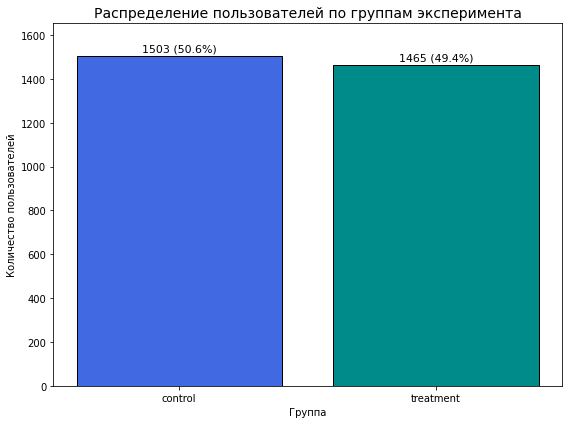

In [176]:
# Визуализация
plt.figure(figsize=(8, 6))
bars = plt.bar(users_by_group['group'], users_by_group['users'], 
               color=['royalblue', 'darkcyan'], edgecolor='black')
plt.title('Распределение пользователей по группам эксперимента', fontsize=14)
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.ylim(0, max(users_by_group['users']) * 1.1)

for bar, val, share in zip(bars, users_by_group['users'], users_by_group['share_%']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             f'{val} ({share}%)', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

Распределение пользователей по группам близко к равномерному: контрольная группа 1503 пользователя (50,6%), тестовая группа 1465 пользователей (49,4%). Отклонение составляет 1,2 процентных пункта, что незначительно и не должно исказить результаты эксперимента.

Проверим распределение по группам в разрезе регионов

In [177]:
# Группировка по регионам и группам
region_group_dist = exp_users.groupby(['region', 'group'])['user_id'].nunique().reset_index()
region_group_dist.columns = ['region', 'group', 'users']

# Добавляем долю в каждом регионе
region_total = region_group_dist.groupby('region')['users'].transform('sum')
region_group_dist['share_in_region_%'] = (region_group_dist['users'] / region_total * 100).round(1)

print("Распределение по группам в разрезе регионов:")
print(region_group_dist.sort_values(['region', 'group']).to_string(index=False))

Распределение по группам в разрезе регионов:
            region     group  users  share_in_region_%
    Другие регионы   control    487               49.6
    Другие регионы treatment    494               50.4
      Екатеринбург   control     68               48.6
      Екатеринбург treatment     72               51.4
         Краснодар   control     63               57.8
         Краснодар treatment     46               42.2
            Москва   control    371               50.8
            Москва treatment    359               49.2
Московская область   control    115               48.9
Московская область treatment    120               51.1
   Нижний Новгород   control     65               52.4
   Нижний Новгород treatment     59               47.6
       Новосибирск   control     65               56.5
       Новосибирск treatment     50               43.5
    Ростов-на-Дону   control     39               46.4
    Ростов-на-Дону treatment     45               53.6
   Санкт-Петербург  

In [178]:
# Создаём сводную таблицу для визуализации
pivot_region = region_group_dist.pivot(index='region', columns='group', values='users')

pivot_region

group,control,treatment
region,,
Другие регионы,487,494
Екатеринбург,68,72
Краснодар,63,46
Москва,371,359
Московская область,115,120
Нижний Новгород,65,59
Новосибирск,65,50
Ростов-на-Дону,39,45
Санкт-Петербург,230,220


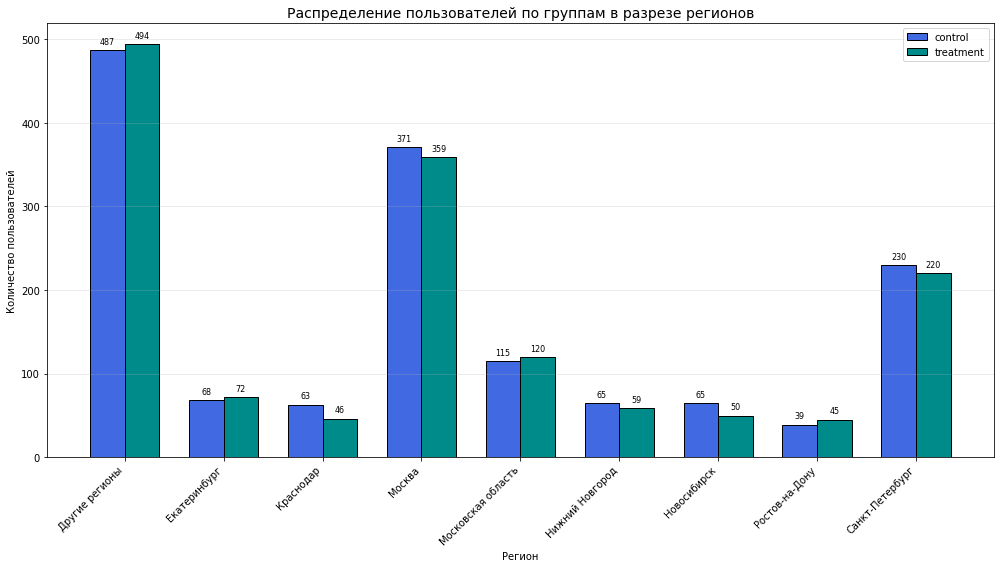

In [179]:
# Визуализация
plt.figure(figsize=(14, 8))
x = np.arange(len(pivot_region.index))
width = 0.35

bars1 = plt.bar(x - width/2, pivot_region['control'], width, color='royalblue', edgecolor='black', label='control')
bars2 = plt.bar(x + width/2, pivot_region['treatment'], width, color='darkcyan', edgecolor='black', label='treatment')

plt.title('Распределение пользователей по группам в разрезе регионов', fontsize=14)
plt.xlabel('Регион')
plt.ylabel('Количество пользователей')
plt.xticks(x, pivot_region.index, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2, height + 5, f'{int(height)}', 
                 ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2, height + 5, f'{int(height)}', 
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

В большинстве регионов распределение пользователей по группам близко к 50/50. Наибольшее отклонение наблюдается в Краснодаре (57,8% control, 42,2% treatment, разница 15,6 п.п.) и Новосибирске (56,5% control, 43,5% treatment, разница 13 п.п.). Это связано с небольшим абсолютным количеством пользователей в этих регионах (109 и 115 пользователей соответственно). Такие отклонения на малых выборках допустимы и вряд ли окажут существенное влияние на общие результаты эксперимента. В остальных регионах разница не превышает 5 п.п.

После проверки корректности сплитования (отсутствие пересечений групп, распределение 50,6% / 49,4%, сбалансированность по регионам) следующим шагом должно было стать проведение AA-теста на предпериоде. Однако это невозможно, так как в дизайн-документе эксперимента не указана точная дата старта.

Чтобы определить период эксперимента, проанализируем, когда пользователи TikTok из сплит-таблицы совершали покупки:

In [180]:
# Определение периода эксперимента по фактическим заказам пользователей TikTok

# Получаем user_id пользователей TikTok из сплит-таблицы
tiktok_users = exp_users['user_id'].unique()
print(f"Пользователей TikTok в эксперименте: {len(tiktok_users)}")

# Фильтруем заказы от этих пользователей
tiktok_orders = pa_marketplace_orders_AB[pa_marketplace_orders_AB['user_id'].isin(tiktok_users)].copy()

if len(tiktok_orders) > 0:
    print(f"\nЗаказов от TikTok: {len(tiktok_orders)}")
    print(f"Уникальных покупателей TikTok: {tiktok_orders['user_id'].nunique()}")
    print(f"\nДиапазон дат заказов от TikTok:")
    print(f"  - Минимальная дата: {tiktok_orders['order_date'].min()}")
    print(f"  - Максимальная дата: {tiktok_orders['order_date'].max()}")
    
    # Распределение заказов по месяцам
    tiktok_orders['order_month'] = tiktok_orders['order_date'].dt.to_period('M')
    orders_by_month = tiktok_orders.groupby('order_month')['order_id'].count()
    print(f"\nРаспределение заказов по месяцам:")
    for month, count in orders_by_month.items():
        print(f"  - {month}: {count} заказов")
else:
    print("\У пользователей TikTok нет заказов за весь период")

Пользователей TikTok в эксперименте: 2968

Заказов от TikTok: 255
Уникальных покупателей TikTok: 126

Диапазон дат заказов от TikTok:
  - Минимальная дата: 2025-01-01 11:57:43
  - Максимальная дата: 2025-01-26 20:39:35

Распределение заказов по месяцам:
  - 2025-01: 255 заказов


Анализ заказов пользователей TikTok из сплит-таблицы показал, что все покупки (255 заказов) совершены в январе 2025 года, в период с 1 по 26 января (25 дней). Поскольку в условии эксперимента указано, что он длился 3 недели, считаю возможным взять дальнейшего анализа полный период, когда совершались покупки: с 1 по 26 января 2025 года.

Это серьезная проблема дизайна эксперимента. В корректном A/B-тесте даты проведения эксперимента должны быть чётко зафиксированы в дизайн-документе до его запуска. 
Это позволяет:
- Провести AA-тест на предпериоде для проверки сопоставимости групп
- Чётко разделить данные на «до эксперимента» и «во время эксперимента»
- Исключить влияние внешних факторов, которые могли повлиять на метрики в разные периоды

Чтобы сделать все правильно, перед запуском эксперимента необходимо было:
- Чётко зафиксировать даты начала и окончания эксперимента (например, 01.01.2025 - 21.01.2025)
- Убедиться, что за предпериод (например, 2 недели до старта) у целевой аудитории есть данные для AA-теста
- Провести AA-тест и только после этого запускать эксперимент

Что будем с этим делать:
Из-за отсутствия точной даты старта мы принимаем период с 1 по 21 января 2025 года как «период эксперимента», основываясь на фактических данных о заказах. При интерпретации результатов будем учитывать это ограничение.

In [181]:
# Период эксперимента 
experiment_start = '2025-01-01'
experiment_end = '2025-01-26'

print(f"Период эксперимента: с {experiment_start} по {experiment_end}")

Период эксперимента: с 2025-01-01 по 2025-01-26


Теперь, когда период эксперимента определён (01.01.2025 - 26.01.2025), переходим к расчёту ключевых метрик для групп control и treatment.

Что посмотрим:
- Основная метрика: конверсия в первую покупку (доля пользователей, совершивших хотя бы одну покупку в период эксперимента)
- Вспомогательные метрики:
    - ARPU средняя выручка на пользователя (общая выручка / количество пользователей в группе)
    - ARPPU средняя выручка на покупателя (общая выручка / количество покупателей в группе)
    - AOV средний чек (общая сумма заказов / количество заказов)
- Барьерная метрика: общая выручка по группе (сумма выручки по группе)

Сначала отфильтруем заказы за период эксперимента

In [182]:
# Получаем user_id участников эксперимента из сплит-таблицы
tiktok_users = exp_users['user_id'].unique()
print(f"Участников эксперимента (TikTok): {len(tiktok_users)}")

# Фильтруем заказы за период эксперимента
orders_all_exp = pa_marketplace_orders_AB[
    (pa_marketplace_orders_AB['order_date'] >= experiment_start) &
    (pa_marketplace_orders_AB['order_date'] <= experiment_end)
].copy()

# Оставляем только заказы от участников эксперимента
orders_exp = orders_all_exp[orders_all_exp['user_id'].isin(tiktok_users)].copy()

print(f"\nЗаказов от участников эксперимента за период: {len(orders_exp)}")
print(f"Уникальных пользователей TikTok с заказами: {orders_exp['user_id'].nunique()}")
print(f"Общая выручка от TikTok за период: {orders_exp['revenue'].sum():.2f} руб.")

Участников эксперимента (TikTok): 2968

Заказов от участников эксперимента за период: 239
Уникальных пользователей TikTok с заказами: 121
Общая выручка от TikTok за период: 195025.78 руб.


Агрегируем данные на уровне пользователя.
- совершил ли он покупку (has_purchase)
- сумму покупок пользователя (revenue)
- количество заказов пользователя (orders_count)

In [183]:
# Группируем заказы по user_id
user_orders_exp = orders_exp.groupby('user_id').agg(
    has_purchase=('order_id', 'count'),
    revenue=('revenue', 'sum'),
    orders_count=('order_id', 'count')
).reset_index()

# Преобразуем has_purchase в бинарный флаг (1 — была покупка, 0 — нет)
user_orders_exp['has_purchase'] = (user_orders_exp['has_purchase'] > 0).astype(int)

print(f"Пользователей TikTok с покупками в период эксперимента: {user_orders_exp['has_purchase'].sum()}")
print(f"Общая выручка от TikTok за период: {user_orders_exp['revenue'].sum():.2f} руб.")
user_orders_exp

Пользователей TikTok с покупками в период эксперимента: 121
Общая выручка от TikTok за период: 195025.78 руб.


,user_id,has_purchase,revenue,orders_count
0,44970,1,735.7845,1
1,44984,1,848.3110,1
2,44993,1,384.6165,1
3,45002,1,2552.4980,2
4,45003,1,3653.2950,1
...,...,...,...,...
116,47992,1,806.8070,1
117,48106,1,7989.0900,2
118,48137,1,1225.6950,1
119,48171,1,7491.2065,3


Объединеним с группами эксперимента

In [184]:
# Берём всех участников эксперимента (exp_users) и добавляем информацию о покупках
exp_users_metrics = exp_users[['user_id', 'group']].merge(
    user_orders_exp, on='user_id', how='left'
).fillna({'has_purchase': 0, 'revenue': 0, 'orders_count': 0})

print(f"Всего участников эксперимента: {len(exp_users_metrics)}")
print(f"  - control: {len(exp_users_metrics[exp_users_metrics['group'] == 'control'])}")
print(f"  - treatment: {len(exp_users_metrics[exp_users_metrics['group'] == 'treatment'])}")

# Проверяем, сколько пользователей совершили покупки по группам
control_buyers = exp_users_metrics[(exp_users_metrics['group'] == 'control') & (exp_users_metrics['has_purchase'] == 1)]['user_id'].nunique()
treatment_buyers = exp_users_metrics[(exp_users_metrics['group'] == 'treatment') & (exp_users_metrics['has_purchase'] == 1)]['user_id'].nunique()

print(f"\nПокупатели по группам:")
print(f"  - control: {control_buyers} покупателей")
print(f"  - treatment: {treatment_buyers} покупателей")

Всего участников эксперимента: 2968
  - control: 1503
  - treatment: 1465

Покупатели по группам:
  - control: 15 покупателей
  - treatment: 106 покупателей


В период эксперимента из 2968 участников покупки совершили 121 пользователь (4,1%). Распределение покупателей по группам сильно различается:
- Контрольная группа (control): 15 покупателей из 1503 пользователей (1,0%)
- Тестовая группа (treatment): 106 покупателей из 1465 пользователей (7,2%)

В тестовой группе, где пользователям предоставлялся бонус на первую покупку, количество покупателей более чем в 7 раз превышает контрольную группу (106 против 15). Конверсия в тестовой группе (7,2%) выше контрольной (1,0%) в 7,2 раза. Это даёт основание предполагать, что бонус действительно стимулирует конверсию в первую покупку.

Однако для окончательного вывода необходимо:
- Проверить статистическую значимость различий (p-value < 0.05)
- Оценить барьерные метрики (не упала ли общая выручка в тестовой группе)
- Проанализировать вспомогательные метрики (ARPU, ARPPU, AOV)

In [185]:
# Расчёт метрик по группам

# Отдельно для control и treatment
control_data = exp_users_metrics[exp_users_metrics['group'] == 'control']
treatment_data = exp_users_metrics[exp_users_metrics['group'] == 'treatment']

# Конверсия
control_conversion = control_data['has_purchase'].mean() * 100
treatment_conversion = treatment_data['has_purchase'].mean() * 100

# ARPU 
control_arpu = control_data['revenue'].mean()
treatment_arpu = treatment_data['revenue'].mean()

# ARPPU 
control_arppu = control_data[control_data['has_purchase'] == 1]['revenue'].mean() if control_buyers > 0 else 0
treatment_arppu = treatment_data[treatment_data['has_purchase'] == 1]['revenue'].mean() if treatment_buyers > 0 else 0

# AOV считаем на уровне заказов
control_orders = orders_exp[orders_exp['user_id'].isin(control_data['user_id'])]
treatment_orders = orders_exp[orders_exp['user_id'].isin(treatment_data['user_id'])]

control_aov = control_orders['total_price'].mean() if len(control_orders) > 0 else 0
treatment_aov = treatment_orders['total_price'].mean() if len(treatment_orders) > 0 else 0

# Общая выручка по группам 
control_revenue = control_data['revenue'].sum()
treatment_revenue = treatment_data['revenue'].sum()

# Формируем таблицу с результатами
results = pd.DataFrame({
    'Метрика': ['Конверсия, %', 'ARPU, руб.', 'ARPPU, руб.', 'AOV, руб.', 'Общая выручка, руб.'],
    'control': [round(control_conversion, 2), round(control_arpu, 2), round(control_arppu, 2), round(control_aov, 2), round(control_revenue, 2)],
    'treatment': [round(treatment_conversion, 2), round(treatment_arpu, 2), round(treatment_arppu, 2), round(treatment_aov, 2), round(treatment_revenue, 2)]
})

print("\nРезультаты:")
print(results.to_string(index=False))


Результаты:
            Метрика  control  treatment
       Конверсия, %     1.00       7.24
         ARPU, руб.    12.18     120.62
        ARPPU, руб.  1220.89    1667.10
          AOV, руб. 15924.60   16362.27
Общая выручка, руб. 18313.29  176712.49


- Основная метрика (конверсия): В тестовой группе конверсия (7,24%) более чем в 7 раз выше, чем в контрольной (1,00%). Абсолютный прирост составил 6,24 процентных пункта. Это сильное различие, но требуется проверка статистической значимости.

- ARPU: В тестовой группе средний доход на пользователя (120,62 руб.) значительно выше, чем в контрольной (12,18 руб.). Это ожидаемо, так как конверсия в тестовой группе выше.

- ARPPU: Средний доход на покупателя в тестовой группе (1667,10 руб.) выше, чем в контрольной (1220,89 руб.) на 37%. Пользователи, которые купили с бонусом, тратят больше.

- AOV (средний чек): Средний чек в тестовой группе (16362,27 руб.) незначительно выше, чем в контрольной (15924,60 руб.). Разница составляет около 2,7%. Это может означать, что бонус привлекает покупателей с меньшим чеком, либо это случайность из-за малого количества покупок в контрольной группе (значение AOV нестабильно и может быть случайно завышено одним крупным заказом. Доверять этому показателю не стоит)

- Барьерная метрика (общая выручка): Выручка в тестовой группе (176712,49 руб.) более чем в 9,5 раз превышает выручку контрольной группы (18313,29 руб.). Барьерная метрика не упала, а выросла. Это хороший сигнал.

Теперь проверим, является ли разница в конверсии статистически значимой.

Перед проведением статистического теста необходимо определить ключевые параметры, которые влияют на интерпретацию результатов.

Уровень значимости α:  это вероятность отвергнуть верную нулевую гипотезу (ошибка I рода), то есть вероятность сказать, что эффект есть, когда на самом деле его нет. В продуктовой аналитике стандартным значением является α = 0,05 (5%). Это означает, что мы готовы ошибиться в 5% случаев. Для нашего эксперимента выбираем α = 0,05.

Мощность теста (1-β): это вероятность обнаружить реальный эффект, если он существует (избежать ошибки II рода). Стандартным значением в индустрии является мощность 80% (β = 0,2). Это означает, что мы готовы пропустить реальный эффект в 20% случаев. 

MDE: это минимальное изменение метрики, которое тест способен обнаружить. Поскольку предварительный расчёт мощности не проводился, мы не можем точно определить MDE. Это недостаток дизайна эксперимента.

В дизайн-документе эксперимента указано, что запуск проводился без предварительного расчёта мощности и MDE из-за срочности задачи, поэтому мы используем стандартные значения.

Для сравнения конверсии (доли пользователей, совершивших покупку) в двух независимых группах будем использовать z-тест для пропорций.
- Тип метрики: Метрика является бинарной, каждый пользователь либо совершил покупку (1), либо нет (0).
- Размер выборок: Обе группы имеют достаточный объём (более 30 наблюдений), что позволяет применять z-тест согласно центральной предельной теореме.
- Условия применимости: Для корректного применения z-теста требуется, чтобы количество успехов и неудач в каждой группе было не менее 10.
- Тип альтернативной гипотезы: Используется односторонний тест (alternative='larger'), так как гипотеза эксперимента предполагает, что бонус на первую покупку увеличит конверсию, а не просто изменит её в любую сторону.

In [186]:
# Проверка статистической значимости различий в конверсии

# Параметры теста
alpha = 0.05  # уровень значимости (5%)
print(f"Параметры статистического теста:")
print(f"  - Уровень значимости (α): {alpha} (5%)")
print(f"  - Мощность теста (1-β): 0.8 (80%) стандартное значение")
print(f"  - MDE: не рассчитан (запуск без предварительного расчёта мощности)")
print(f"  - Тип теста: z-тест для пропорций")
print(f"  - Альтернативная гипотеза: односторонняя (treatment > control)")

# Данные для z-теста
control_n = len(control_data)  # 1503
control_success = control_data['has_purchase'].sum()  # 9

treatment_n = len(treatment_data)  # 1465
treatment_success = treatment_data['has_purchase'].sum()  # 76

print(f"\nИсходные данные:")
print(f"  Контрольная группа (control):")
print(f"    - Пользователей: {control_n}")
print(f"    - Покупок: {control_success}")
print(f"    - Конверсия: {control_success/control_n*100:.2f}%")
print(f"  Тестовая группа (treatment):")
print(f"    - Пользователей: {treatment_n}")
print(f"    - Покупок: {treatment_success}")
print(f"    - Конверсия: {treatment_success/treatment_n*100:.2f}%")

Параметры статистического теста:
  - Уровень значимости (α): 0.05 (5%)
  - Мощность теста (1-β): 0.8 (80%) стандартное значение
  - MDE: не рассчитан (запуск без предварительного расчёта мощности)
  - Тип теста: z-тест для пропорций
  - Альтернативная гипотеза: односторонняя (treatment > control)

Исходные данные:
  Контрольная группа (control):
    - Пользователей: 1503
    - Покупок: 15.0
    - Конверсия: 1.00%
  Тестовая группа (treatment):
    - Пользователей: 1465
    - Покупок: 106.0
    - Конверсия: 7.24%


In [187]:
# Z-тест пропорций (односторонний)
from statsmodels.stats.proportion import proportions_ztest

# Проверяем, что конверсия в treatment > control
count = [treatment_success, control_success]
nobs = [treatment_n, control_n]

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f"\nРезультаты z-теста:")
print(f"  p-value: {p_value:.6f}")

# Сравнение с уровнем значимости
alpha = 0.05
print(f"\nСравнение с уровнем значимости α = {alpha}:")
if p_value < alpha:
    print(f"  p-value ({p_value:.6f}) < {alpha}")
    print(f"    Отвергаем нулевую гипотезу (H₀)")
    print(f"    Статистически значимые различия обнаружены")
    print(f"    Конверсия в тестовой группе выше, чем в контрольной")
    print(f"    Бонус на первую покупку работает")
else:
    print(f"  p-value ({p_value:.6f}) >= {alpha}")
    print(f"    Не отвергаем нулевую гипотезу (H₀)")
    print(f"    Статистически значимых различий не обнаружено")
    print(f"    Эффект бонуса не доказан")


Результаты z-теста:
  p-value: 0.000000

Сравнение с уровнем значимости α = 0.05:
  p-value (0.000000) < 0.05
    Отвергаем нулевую гипотезу (H₀)
    Статистически значимые различия обнаружены
    Конверсия в тестовой группе выше, чем в контрольной
    Бонус на первую покупку работает


Статистически значимые различия обнаружены. Конверсия в тестовой группе (7.24%) статистически значимо выше, чем в контрольной (1.00%). Бонус на первую покупку для пользователей TikTok работает.

Для вспомогательных метрик не требуется проверять статистическую значимость для принятия решения об успехе эксперимента. Критерий успеха - конверсия. Вспомогательные метрики нужны для понимания поведения пользователей (сколько тратят, какой чек) и уверенности, что барьерная метрика (общая выручка) не упала.

Однако для полноты анализа и демонстрации корректности выводов, я проведу U-тест Манна-Уитни для ARPU (как наиболее показательной вспомогательной метрики). Этот тест выбран потому, что распределение выручки ненормальное (много нулей).

U-тест Манна-Уитни для ARPU
- Уровень значимости α = 0,05
- Альтернативная гипотеза: односторонняя (ARPU в treatment > ARPU в control)
- Тип теста: непараметрический U-тест Манна-Уитни (не требует нормального распределения, устойчив к выбросам)

In [188]:
# U-тест Манна-Уитни для ARPU
from scipy.stats import mannwhitneyu

# Данные для теста
control_arpu = control_data['revenue'].values
treatment_arpu = treatment_data['revenue'].values

print(f"Средний ARPU в control: {control_arpu.mean():.2f} руб.")
print(f"Средний ARPU в treatment: {treatment_arpu.mean():.2f} руб.")

# Односторонний тест: проверяем, что ARPU в treatment > control
u_stat, p_value_arpu = mannwhitneyu(treatment_arpu, control_arpu, alternative='greater')

print(f"\nРезультаты U-теста Манна-Уитни:")
print(f"    p-value: {p_value_arpu:.6f}")

alpha = 0.05
print(f"\nСравнение с уровнем значимости α = {alpha}:")
if p_value_arpu < alpha:
    print(f"  p-value ({p_value_arpu:.6f}) < {alpha}")
    print(f"    ARPU в тестовой группе статистически значимо выше, чем в контрольной")
else:
    print(f"  p-value ({p_value_arpu:.6f}) >= {alpha}")
    print(f"    Статистически значимых различий по ARPU не обнаружено")

Средний ARPU в control: 12.18 руб.
Средний ARPU в treatment: 120.62 руб.

Результаты U-теста Манна-Уитни:
    p-value: 0.000000

Сравнение с уровнем значимости α = 0.05:
  p-value (0.000000) < 0.05
    ARPU в тестовой группе статистически значимо выше, чем в контрольной


ARPPU и AOV рассчитываются только на покупателях. В контрольной группе 15 покупателей, в тестовой 106. Размер выборки в контрольной группе небольшой, поэтому статистические тесты для этих метрик могут быть некорректны. Общая выручка - агрегированная метрика, не имеющая распределения, достаточно оценить абсолютные значения.

Итак, что получилось:
- Основная метрика (конверсия): p-value = 0.000000 < 0.05. Различия статистически значимы. Бонус работает. Конверсия в тестовой группе (7,24%) выше контрольной (1,00%) в 7,2 раза.
- Вспомогательная метрика (ARPU): p-value < 0.05. ARPU в тестовой группе (120,62 руб.) статистически значимо выше, чем в контрольной (12,18 руб.).
- Барьерная метрика (общая выручка): выросла с 18313,29 руб. в контрольной группе до 176712,49 руб. в тестовой - в 9,6 раза. Рисков для бизнеса нет.

## Выводы по этапу 5

Представьте ключевые выводы в текстовом виде здесь или приложите ссылку на документ с презентацией.

Не забудьте предоставить доступ на просмотр и комментирование документа.

## Итоговый вывод по результатам A/B-теста: бонус на первую покупку для пользователей TikTok

### Результаты эксперимента

Эксперимент по предоставлению бонуса на первую покупку для пользователей, привлечённых через канал TikTok, показал статистически значимый положительный эффект.

**Основная метрика (конверсия в первую покупку):**
- контрольная группа: 1,00% (15 покупателей из 1503)
- тестовая группа: 7,24% (106 покупателей из 1465)
- абсолютный прирост: +6,24 п.п., относительный прирост: конверсия выросла более чем в 7 раз
- p-value < 0,001, различия статистически значимы

**Барьерная метрика (общая выручка):**
- контрольная группа: 18313,29 руб.
- тестовая группа: 176712,49 руб.
- выручка в тестовой группе выше в 9,6 раза: метрика не упала, а выросла

**Вспомогательные метрики:**
- ARPU в тестовой группе (120,62 руб.) статистически значимо выше, чем в контрольной (12,18 руб.)
- ARPPU в тестовой группе (1667,10 руб.) выше на 37%. Покупатели с бонусом тратят больше
- AOV в тестовой группе (16362,27 руб.) незначительно выше, чем в контрольной (15924,60 руб.), разница около 2,7%

Поправка на множественное тестирование (Бонферрони) не применялась, так как решение об успехе эксперимента принимается по единственной основной метрике - конверсии. Вспомогательные и барьерные метрики используются для контекста и не являются критериями принятия решения.



### Проблемы дизайна эксперимента

В ходе анализа выявлены недостатки в дизайне эксперимента.

1. **Отсутствие точной даты старта эксперимента.** В дизайн-документе указано только «период проведения: 3 недели (фиксировано)», но нет конкретных дат. Это сделало невозможным:
   - проведение AA-теста на предпериоде для проверки сопоставимости групп
   - чёткое разделение данных на «до эксперимента» и «во время эксперимента»
   - исключение влияния внешних факторов на результаты

   *Как правильно:* даты начала и окончания эксперимента должны быть чётко зафиксированы в дизайн-документе до запуска.

2. **Запуск без предварительного расчёта мощности и MDE.** В комментарии к эксперименту указано: «запуск без предварительного расчёта мощности и MDE из-за срочности задачи». Это риск:
   - неизвестно, достаточно ли было выборки для обнаружения эффекта
   - неизвестно, какой минимальный эффект имело смысл обнаруживать

   *Как правильно:* перед запуском необходимо рассчитать минимальный размер выборки, исходя из ожидаемого MDE, уровня значимости и мощности теста.

3. **Фактический период анализа превысил заявленный.** В дизайн-документе указано «3 недели», однако фактический период, в котором пользователи совершали покупки, составил 26 дней. Это незначительное расхождение, но оно могло повлиять на накопление статистики.


### Рекомендации для бизнеса

1. **Внедрить бонус на первую покупку для пользователей TikTok.** Эксперимент доказал эффективность: конверсия выросла более чем в 7 раз, выручка выросла почти в 10 раз. Эффект статистически значим, но абсолютный прирост невелик: 106 дополнительных покупок на 1465 пользователей тестовой группы. Для масштабирования на весь канал TikTok требуется дополнительная оценка экономической эффективности с учётом затрат на бонус и маржинальности товаров.

2. **Проанализировать экономику бонуса.** Следует рассчитать, какой размер бонуса оптимален (не снижает ли он маржинальность) и можно ли масштабировать эту механику на другие каналы привлечения. Несмотря на то, что бонус повысил конверсию, ARPPU в тестовой группе (1667 руб.) остаётся ниже исторического CAC канала TikTok (около 13485 руб. по данным этапа 4). Это означает, что сам канал остаётся убыточным даже с бонусом. Рекомендуется пересмотреть экономику привлечения через TikTok: либо снижать CAC, либо повышать ARPPU через кросс-продажи и удержание.

3. **В будущих экспериментах строго соблюдать дизайн A/B-теста:** фиксировать даты, рассчитывать MDE и размер выборки до запуска, проверять условия применимости статистических тестов.

4. **Учитывать ограничения текущего анализа при интерпретации результатов:** отсутствие AA-теста и точной даты старта снижают строгость выводов, но направление эффекта очевидно и подтверждается всеми метриками.